# Main

In [141]:
import os
os.chdir('D:/urban_hierarchy_congestion')

## Fig.2

In [48]:
import pandas as pd
import geopandas as gpd
from tqdm import tqdm

for city in tqdm(['beijing','shanghai','shenzhen','london','losangeles','newyork']):
    od = pd.read_csv(f"data/od_tables/{city}_od.csv")
    unit = gpd.read_file(f"results/hierarchy_identification_results/{city}_hierarchy.shp")
    od = pd.merge(pd.merge(od,unit[['id','level']],left_on='o_id',right_on='id'),unit[['id','level']],left_on='d_id',right_on='id')
    d = od.groupby('level_y',as_index=False)['flow'].sum()
    d.rename(columns={'level_y':'level','flow':'inflow'},inplace=True)
    d.to_csv(f"results/summary_tables/{city}_level_inflow.csv",index=False)

100%|██████████| 6/6 [00:01<00:00,  3.18it/s]


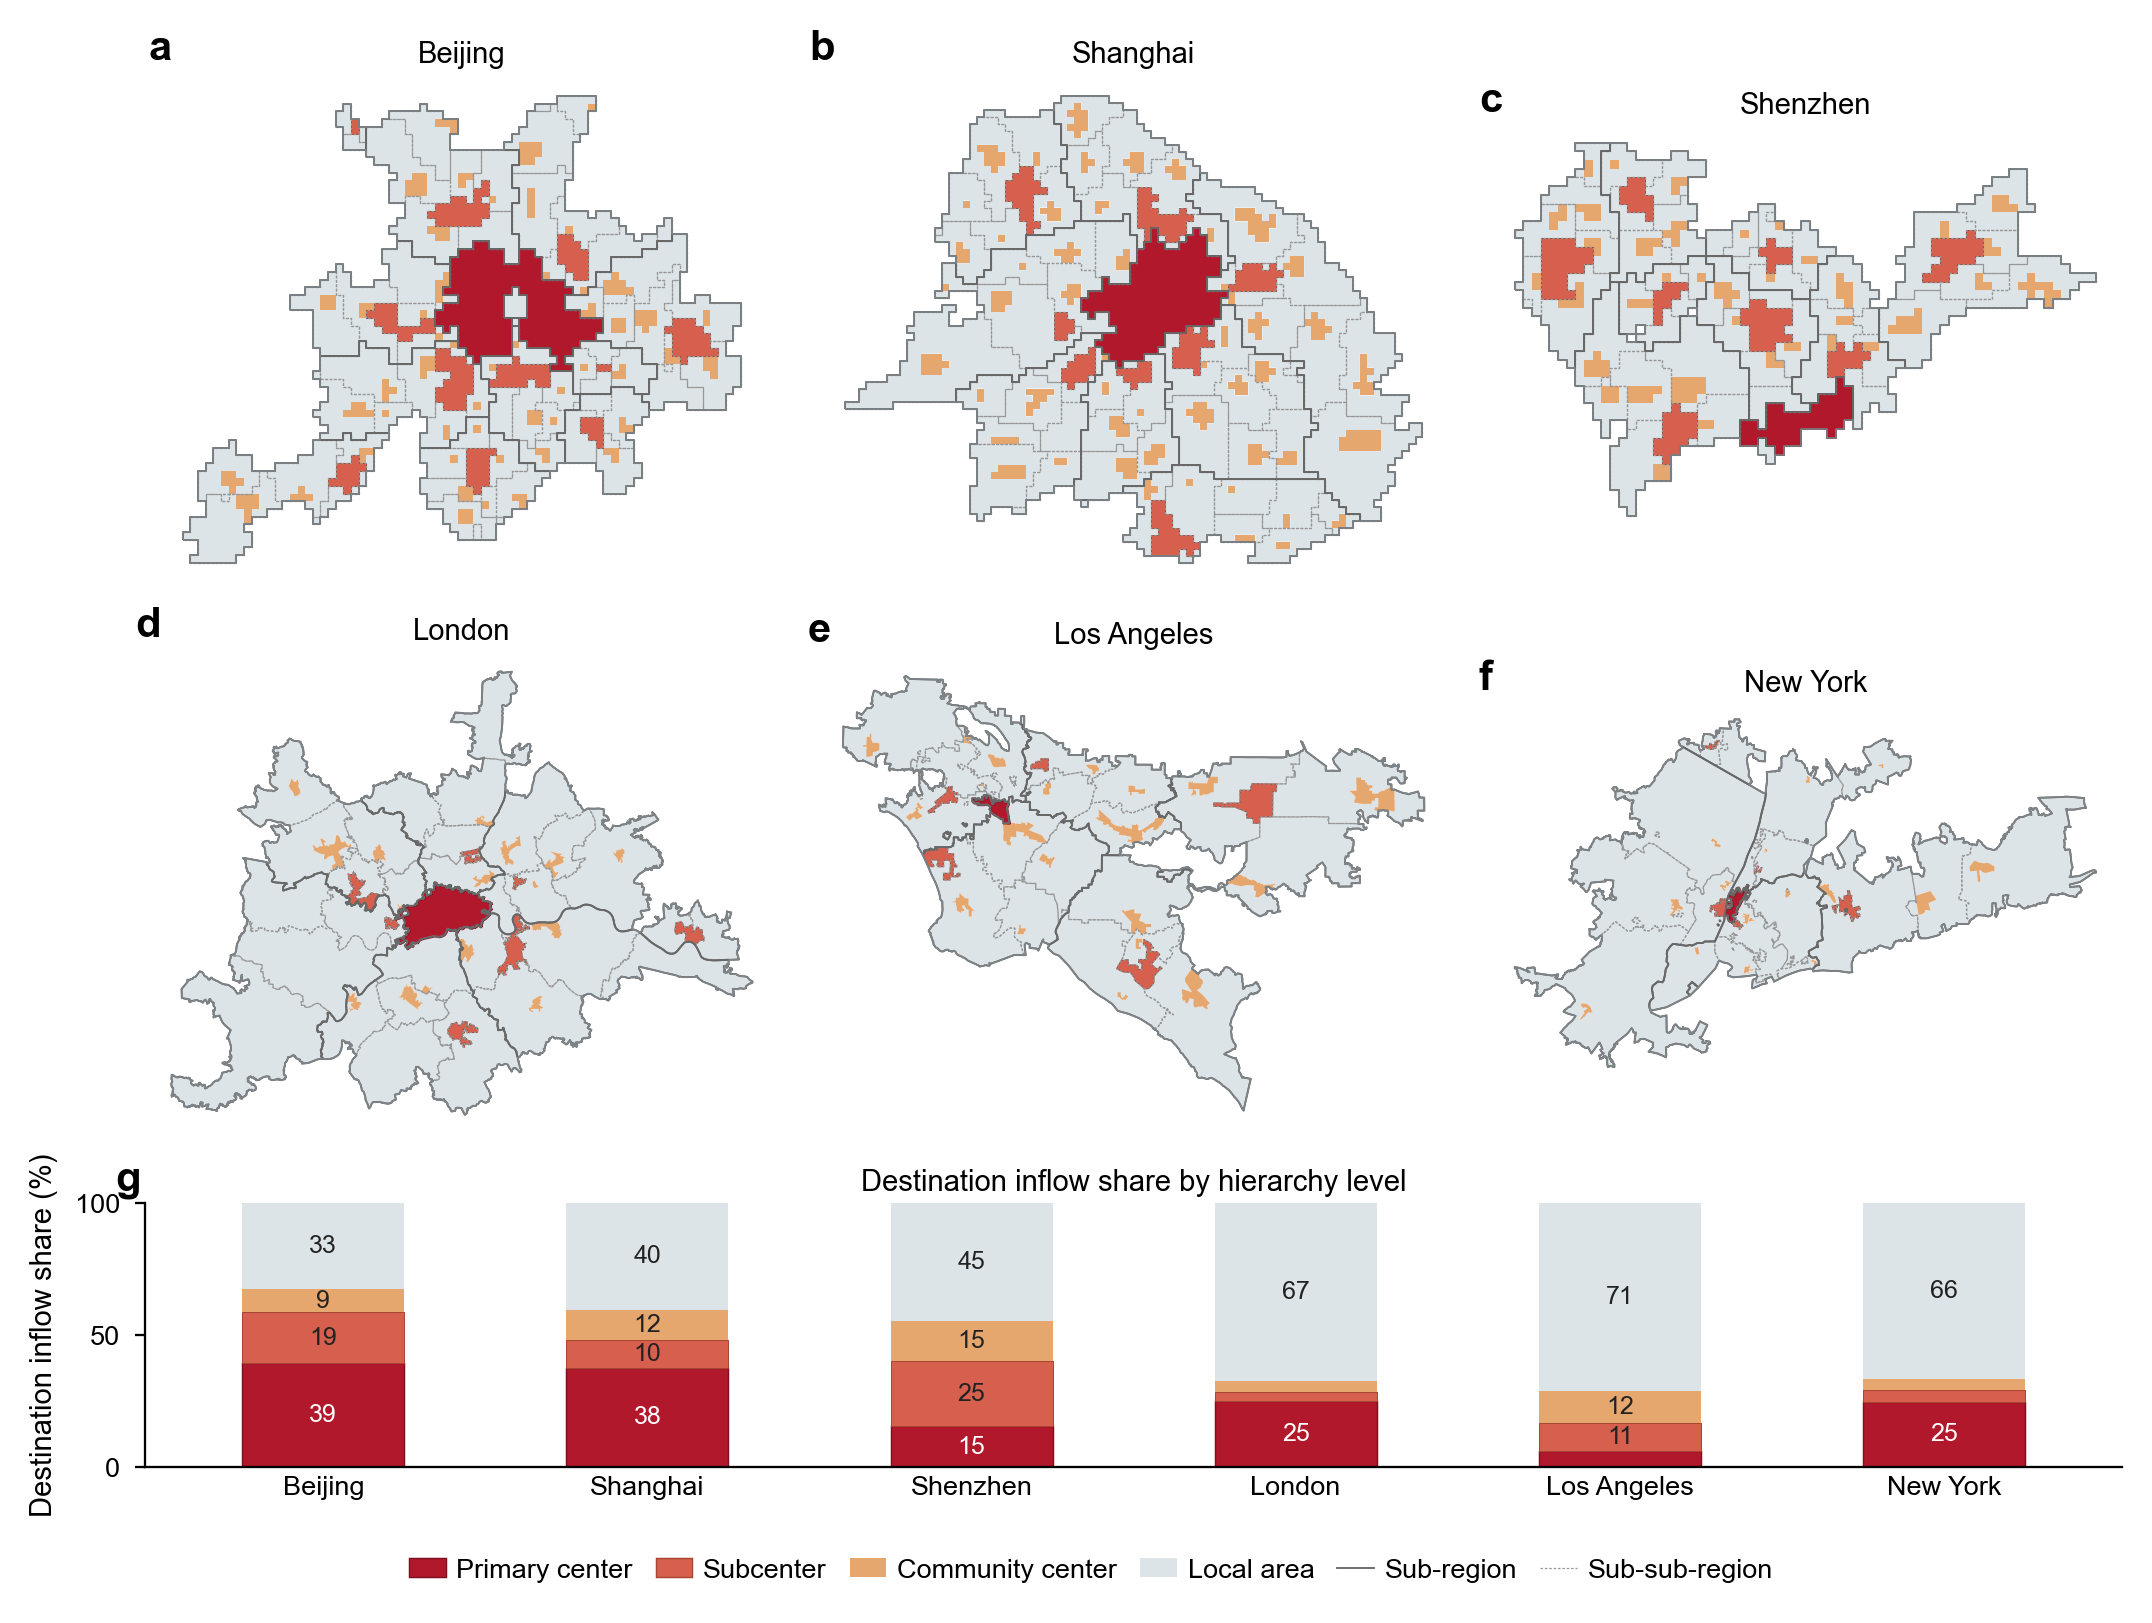

Saved figure: results\figures\Fig2_urban_hierarchy_maps.jpg


In [138]:
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# Input and output directories
HIERARCHY_DIR = Path("results/hierarchy_identification_results")
INFLOW_DIR = Path("results/summary_tables")
OUTPUT_PATH = Path("results/figures/Fig2_urban_hierarchy_maps.jpg")


# City names, panel labels, and filename prefixes
CITY_CONFIGS = [
    {"city_name": "Beijing", "panel": "a", "prefix": "beijing"},
    {"city_name": "Shanghai", "panel": "b", "prefix": "shanghai"},
    {"city_name": "Shenzhen", "panel": "c", "prefix": "shenzhen"},
    {"city_name": "London", "panel": "d", "prefix": "london"},
    {"city_name": "Los Angeles", "panel": "e", "prefix": "losangeles"},
    {"city_name": "New York", "panel": "f", "prefix": "newyork"},
]


# Hierarchy colors used consistently across the figure
LEVEL_COLORS = {
    "level1": "#B2182B",
    "level2": "#D6604D",
    "level3": "#E6A76F",
    "level4": "#DDE4E8",
}

LEVEL_NAMES = {
    "level1": "Primary center",
    "level2": "Subcenter",
    "level3": "Community center",
    "level4": "Local area",
}

LEVEL_OUTLINES = {
    "level1": "#7F1020",
    "level2": "#A94735",
    "level3": "none",
    "level4": "none",
}

SUBREGION_STYLE = {
    "color": "#686868",
    "linewidth": 0.45,
    "linestyle": "-",
}

SUBSUBREGION_STYLE = {
    "color": "#969696",
    "linewidth": 0.30,
    "linestyle": (0, (2.0, 1.5)),
}

CITY_OUTLINE_COLOR = "#7D8387"
CITY_OUTLINE_WIDTH = 0.40


# Final figure dimensions and typography
FIGURE_WIDTH_CM = 18.0
FIGURE_HEIGHT_CM = 14.2
PANEL_LABEL_SIZE = 10
CITY_TITLE_SIZE = 7.0
AXIS_LABEL_SIZE = 7.0
TICK_LABEL_SIZE = 6.5
LEGEND_SIZE = 6.5
MAP_PADDING = 0.045
USE_DISSOLVE = True


mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 7.0,
        "axes.linewidth": 0.55,
        "xtick.major.width": 0.55,
        "ytick.major.width": 0.55,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


def hierarchy_path(prefix: str, suffix: str) -> Path:
    return HIERARCHY_DIR / f"{prefix}_{suffix}.shp"


def inflow_path(prefix: str) -> Path:
    return INFLOW_DIR / f"{prefix}_level_inflow.csv"


def read_required_geodata(path: Path) -> gpd.GeoDataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Required spatial file not found: {path}")

    gdf = gpd.read_file(path)
    if gdf.empty:
        raise ValueError(f"Spatial file contains no features: {path}")
    if gdf.geometry.isna().all():
        raise ValueError(f"Spatial file contains no valid geometry: {path}")
    return gdf


def read_optional_geodata(path: Path):
    if not path.exists():
        print(f"Warning: optional boundary file not found: {path}")
        return None

    gdf = gpd.read_file(path)
    if gdf.empty:
        print(f"Warning: optional boundary file is empty: {path}")
        return None
    return gdf


def normalize_hierarchy_levels(gdf: gpd.GeoDataFrame, path: Path) -> gpd.GeoDataFrame:
    if "level" not in gdf.columns:
        raise ValueError(f"{path} must contain a 'level' column.")

    output = gdf.copy()
    output["level_num"] = pd.to_numeric(
        output["level"]
        .astype(str)
        .str.upper()
        .str.replace("LEVEL", "", regex=False)
        .str.replace("L", "", regex=False)
        .str.extract(r"(\d+)", expand=False),
        errors="coerce",
    )

    invalid = output["level_num"].isna() | ~output["level_num"].isin([1, 2, 3, 4])
    if invalid.any():
        bad_values = sorted(output.loc[invalid, "level"].astype(str).unique())
        raise ValueError(f"Invalid hierarchy values in {path}: {bad_values}")

    output["level_num"] = output["level_num"].astype(int)
    return output


def align_to_crs(gdf, target_crs):
    if gdf is None or gdf.empty or target_crs is None:
        return gdf
    if gdf.crs is None:
        raise ValueError("A boundary layer has no CRS and cannot be aligned.")
    return gdf.to_crs(target_crs) if gdf.crs != target_crs else gdf


def dissolve_layer(gdf):
    if gdf is None or gdf.empty or not USE_DISSOLVE:
        return gdf

    output = gdf[["geometry"]].copy()
    output["_group"] = 1
    return output.dissolve(by="_group").reset_index(drop=True)


def total_bounds(layers):
    available = [layer.total_bounds for layer in layers if layer is not None and not layer.empty]
    if not available:
        return None

    return (
        min(bounds[0] for bounds in available),
        min(bounds[1] for bounds in available),
        max(bounds[2] for bounds in available),
        max(bounds[3] for bounds in available),
    )


def set_map_extent(ax, bounds, padding=MAP_PADDING):
    min_x, min_y, max_x, max_y = bounds
    width = max_x - min_x
    height = max_y - min_y

    x_padding = width * padding if width > 0 else 1.0
    y_padding = height * padding if height > 0 else 1.0

    ax.set_xlim(min_x - x_padding, max_x + x_padding)
    ax.set_ylim(min_y - y_padding, max_y + y_padding)


def plot_boundary(ax, gdf, color, linewidth, linestyle="-", zorder=5):
    if gdf is None or gdf.empty:
        return

    gdf.boundary.plot(
        ax=ax,
        color=color,
        linewidth=linewidth,
        linestyle=linestyle,
        zorder=zorder,
    )


def read_level_inflow(prefix: str, city_name: str) -> dict:
    path = inflow_path(prefix)
    if not path.exists():
        raise FileNotFoundError(f"Required inflow file not found: {path}")

    df = pd.read_csv(path)
    required_columns = {"level", "inflow"}
    missing_columns = required_columns.difference(df.columns)
    if missing_columns:
        raise ValueError(f"{path} is missing columns: {sorted(missing_columns)}")

    level_num = pd.to_numeric(
        df["level"]
        .astype(str)
        .str.upper()
        .str.replace("LEVEL", "", regex=False)
        .str.replace("L", "", regex=False)
        .str.extract(r"(\d+)", expand=False),
        errors="coerce",
    )
    inflow = pd.to_numeric(df["inflow"], errors="coerce")

    if level_num.isna().any() or ~level_num.dropna().isin([1, 2, 3, 4]).all():
        bad_values = sorted(df.loc[level_num.isna() | ~level_num.isin([1, 2, 3, 4]), "level"].astype(str).unique())
        raise ValueError(f"Invalid level values in {path}: {bad_values}")
    if inflow.isna().any():
        raise ValueError(f"The 'inflow' column contains non-numeric or missing values: {path}")
    if (inflow < 0).any():
        raise ValueError(f"The 'inflow' column contains negative values: {path}")

    level_totals = (
        pd.DataFrame({"level": level_num.astype(int), "inflow": inflow})
        .groupby("level", sort=True)["inflow"]
        .sum()
        .reindex([1, 2, 3, 4], fill_value=0.0)
    )

    total = level_totals.sum()
    if total <= 0:
        raise ValueError(f"Total inflow must be greater than zero: {path}")

    shares = level_totals / total * 100.0
    return {
        "city_name": city_name,
        "level1": shares.loc[1],
        "level2": shares.loc[2],
        "level3": shares.loc[3],
        "level4": shares.loc[4],
    }


def plot_city_panel(ax, config):
    prefix = config["prefix"]
    hierarchy_file = hierarchy_path(prefix, "hierarchy")

    hierarchy = read_required_geodata(hierarchy_file)
    hierarchy = normalize_hierarchy_levels(hierarchy, hierarchy_file)

    subregion = read_optional_geodata(hierarchy_path(prefix, "sub_region"))
    subsubregion = read_optional_geodata(hierarchy_path(prefix, "sub_sub_region"))
    subregion = align_to_crs(subregion, hierarchy.crs)
    subsubregion = align_to_crs(subsubregion, hierarchy.crs)

    levels = {
        level: dissolve_layer(hierarchy.loc[hierarchy["level_num"] == level].copy())
        for level in [1, 2, 3, 4]
    }
    city_outline = dissolve_layer(hierarchy)

    for level in [4, 3, 2, 1]:
        key = f"level{level}"
        layer = levels[level]
        if layer is None or layer.empty:
            continue

        layer.plot(
            ax=ax,
            facecolor=LEVEL_COLORS[key],
            edgecolor=LEVEL_OUTLINES[key],
            linewidth=0.45 if level == 1 else 0.25 if level == 2 else 0.0,
            zorder=5 - level,
        )

    plot_boundary(ax, subsubregion, **SUBSUBREGION_STYLE, zorder=5)
    plot_boundary(ax, subregion, **SUBREGION_STYLE, zorder=6)
    plot_boundary(
        ax,
        city_outline,
        color=CITY_OUTLINE_COLOR,
        linewidth=CITY_OUTLINE_WIDTH,
        zorder=7,
    )

    bounds = total_bounds([hierarchy, subregion, subsubregion])
    if bounds is not None:
        set_map_extent(ax, bounds)

    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_facecolor("white")

    ax.text(
        -0.015,
        1.015,
        config["panel"],
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=PANEL_LABEL_SIZE,
        fontweight="bold",
        clip_on=False,
    )
    ax.set_title(config["city_name"], fontsize=CITY_TITLE_SIZE, pad=3.0)


def plot_inflow_panel(ax, city_configs):
    shares = pd.DataFrame(
        [read_level_inflow(config["prefix"], config["city_name"]) for config in city_configs]
    )

    x = np.arange(len(shares))
    bottom = np.zeros(len(shares))

    for key in ["level1", "level2", "level3", "level4"]:
        values = shares[key].to_numpy(dtype=float)
        ax.bar(
            x,
            values,
            bottom=bottom,
            width=0.50,
            color=LEVEL_COLORS[key],
            edgecolor=LEVEL_OUTLINES[key],
            linewidth=0.35 if key == "level1" else 0.25 if key == "level2" else 0.0,
            label=LEVEL_NAMES[key],
            zorder=2,
        )

        for index, value in enumerate(values):
            if value >= 8.0:
                ax.text(
                    x[index],
                    bottom[index] + value / 2.0,
                    f"{value:.0f}",
                    ha="center",
                    va="center",
                    fontsize=6.0,
                    color="white" if key == "level1" else "#222222",
                    zorder=3,
                )

        bottom += values

    ax.set_xlim(-0.55, len(shares) - 0.45)
    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(shares["city_name"], fontsize=TICK_LABEL_SIZE)
    ax.set_yticks([0, 50, 100])
    ax.set_ylabel("Destination inflow share (%)", fontsize=AXIS_LABEL_SIZE)
    ax.set_title("Destination inflow share by hierarchy level", fontsize=7.0, pad=3.0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.55)
    ax.spines["bottom"].set_linewidth(0.55)
    ax.tick_params(axis="x", length=0, pad=2.0)
    ax.tick_params(axis="y", direction="out", labelsize=TICK_LABEL_SIZE)

    ax.text(
        -0.015,
        1.015,
        "g",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=PANEL_LABEL_SIZE,
        fontweight="bold",
        clip_on=False,
    )


def create_figure():
    figure = plt.figure(
        figsize=(FIGURE_WIDTH_CM / 2.54, FIGURE_HEIGHT_CM / 2.54),
        facecolor="white",
    )

    grid = GridSpec(
        3,
        3,
        figure=figure,
        height_ratios=[1.0, 1.0, 0.52],
        hspace=0.13,
        wspace=0.06,
    )

    map_axes = [figure.add_subplot(grid[row, column]) for row in range(2) for column in range(3)]
    inflow_axis = figure.add_subplot(grid[2, :])

    for axis, config in zip(map_axes, CITY_CONFIGS):
        plot_city_panel(axis, config)

    plot_inflow_panel(inflow_axis, CITY_CONFIGS)

    legend_handles = [
        Patch(
            facecolor=LEVEL_COLORS[key],
            edgecolor=LEVEL_OUTLINES[key],
            linewidth=0.35,
            label=LEVEL_NAMES[key],
        )
        for key in ["level1", "level2", "level3", "level4"]
    ]
    legend_handles.extend(
        [
            Line2D([0], [0], label="Sub-region", **SUBREGION_STYLE),
            Line2D([0], [0], label="Sub-sub-region", **SUBSUBREGION_STYLE),
        ]
    )

    figure.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.05),
        ncol=6,
        frameon=False,
        fontsize=LEGEND_SIZE,
        handlelength=1.35,
        handletextpad=0.40,
        columnspacing=0.85,
        borderaxespad=0.0,
    )

    figure.subplots_adjust(
        left=0.055,
        right=0.985,
        top=0.955,
        bottom=0.125,
    )
    return figure


def main():
    figure = create_figure()
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        OUTPUT_PATH,
        dpi=600,
        format="jpg",
        facecolor="white",
        pil_kwargs={"quality": 100, "subsampling": 0},
    )
    plt.show()
    plt.close(figure)
    print(f"Saved figure: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

## Fig.3

In [56]:
for city in tqdm(['beijing','shanghai','shenzhen','london','losangeles','newyork']):
    od = pd.read_csv(f'results/traffic_assignment_results/{city}/observed_commuting_flows_congested_time.csv')
    od = od.loc[(od['o_id']!=od['d_id'])&(od['rdist'].notna())].copy()
    od.index = range(len(od))
    unit = gpd.read_file(f'results/hierarchy_identification_results/{city}_hierarchy.shp')
    od = pd.merge(pd.merge(od,unit[['id','level']],left_on='o_id',right_on='id'),unit[['id','level']],left_on='d_id',right_on='id')
    od.rename(columns={'level_x':'o_level','level_y':'d_level'},inplace=True)
    od.drop(columns={'id_x','id_y'},inplace=True)
    od['flow'] = od['flow']*od['P_car']
    od['drive_time'] = od['flow']*od['drive_time']
    od['con_drive_time'] = od['flow']*od['con_drive_time']
    TD = np.sum(od['con_drive_time']-od['drive_time'])

    level_od = od.groupby(['o_level','d_level'],as_index=False)[['flow','drive_time','con_drive_time']].sum()
    level_od['TTI'] = level_od['con_drive_time']/level_od['drive_time']
    level_od['TD'] = (level_od['con_drive_time']-level_od['drive_time'])/TD*100
    level_od['ATD'] = (level_od['con_drive_time']-level_od['drive_time'])/level_od['flow']
    level_od.to_csv(f'results/summary_tables/{city}_level_od.csv',index=False)

100%|██████████| 6/6 [01:52<00:00, 18.82s/it]


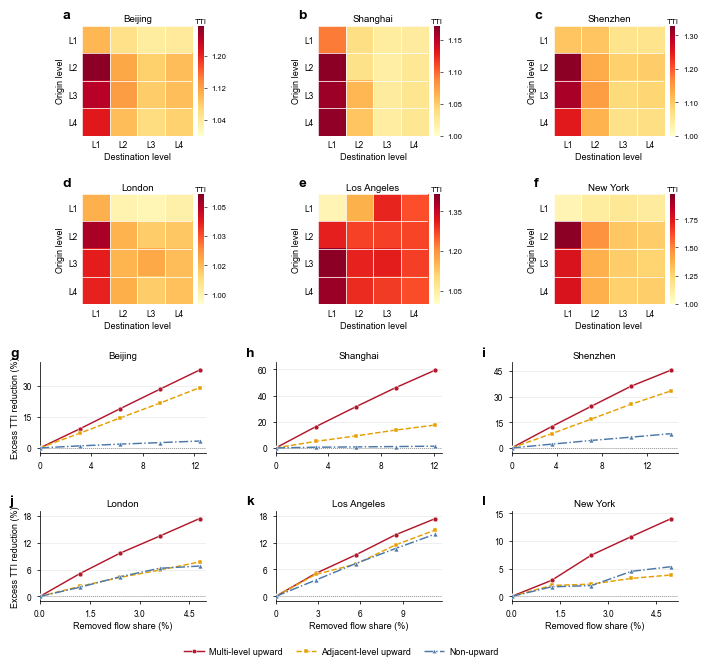

Saved figure: results\figures\Fig3_hierarchical_congestion.jpg


In [74]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter, MaxNLocator


# Input and output directories
SUMMARY_DIR = Path("results/summary_tables")
EXPERIMENT_DIR = Path("results/traffic_assignment_results")
OUTPUT_PATH = Path("results/figures/Fig3_hierarchical_congestion.jpg")


# City names, filename prefixes, and panel order
CITY_CONFIGS = [
    {"city_name": "Beijing", "prefix": "beijing"},
    {"city_name": "Shanghai", "prefix": "shanghai"},
    {"city_name": "Shenzhen", "prefix": "shenzhen"},
    {"city_name": "London", "prefix": "london"},
    {"city_name": "Los Angeles", "prefix": "losangeles"},
    {"city_name": "New York", "prefix": "newyork"},
]

LEVEL_ORDER = [1, 2, 3, 4]
LEVEL_LABELS = ["L1", "L2", "L3", "L4"]


# Styles for the equal-flow reduction experiment
GROUP_ORDER = [
    "multi_level_upward",
    "adjacent_level_upward",
    "non_upward",
]

GROUP_STYLES = {
    "multi_level_upward": {
        "label": "Multi-level upward",
        "color": "#B2182B",
        "linestyle": "-",
        "marker": "o",
    },
    "adjacent_level_upward": {
        "label": "Adjacent-level upward",
        "color": "#E69F00",
        "linestyle": "--",
        "marker": "s",
    },
    "non_upward": {
        "label": "Non-upward",
        "color": "#4C78A8",
        "linestyle": "-.",
        "marker": "^",
    },
}


# Final figure dimensions and typography
FIGURE_WIDTH_CM = 18.0
FIGURE_HEIGHT_CM = 17.0
PANEL_LABEL_SIZE = 10
TITLE_SIZE = 7.0
AXIS_LABEL_SIZE = 6.5
TICK_LABEL_SIZE = 6.0
LEGEND_SIZE = 6.5


mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 6.5,
        "axes.linewidth": 0.55,
        "xtick.major.width": 0.55,
        "ytick.major.width": 0.55,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


def level_od_path(prefix: str) -> Path:
    return SUMMARY_DIR / f"{prefix}_level_od.csv"


def experiment_path(prefix: str) -> Path:
    return EXPERIMENT_DIR / prefix / "equal_flow_upward_commuting_results.csv"


def normalize_level(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series
        .astype(str)
        .str.upper()
        .str.replace("LEVEL", "", regex=False)
        .str.replace("L", "", regex=False)
        .str.extract(r"(\d+)", expand=False),
        errors="coerce",
    )


def normalize_group(series: pd.Series) -> pd.Series:
    return (
        series
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[\s-]+", "_", regex=True)
    )


def read_level_od(prefix: str) -> pd.DataFrame:
    path = level_od_path(prefix)
    if not path.exists():
        raise FileNotFoundError(f"Required level OD file not found: {path}")

    df = pd.read_csv(path)
    required = {"o_level", "d_level", "TTI"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    df = df.loc[:, ["o_level", "d_level", "TTI"]].copy()
    df["o_level"] = normalize_level(df["o_level"])
    df["d_level"] = normalize_level(df["d_level"])
    df["TTI"] = pd.to_numeric(df["TTI"], errors="coerce")

    if df.isna().any().any():
        raise ValueError(f"{path} contains missing or non-numeric plotting values.")
    if not df["o_level"].isin(LEVEL_ORDER).all() or not df["d_level"].isin(LEVEL_ORDER).all():
        raise ValueError(f"{path} contains hierarchy levels outside L1-L4.")
    if (df["TTI"] <= 0).any():
        raise ValueError(f"TTI values must be greater than zero: {path}")
    if df.duplicated(["o_level", "d_level"]).any():
        raise ValueError(f"{path} contains duplicate origin-destination level pairs.")

    matrix = df.pivot(index="o_level", columns="d_level", values="TTI")
    matrix = matrix.reindex(index=LEVEL_ORDER, columns=LEVEL_ORDER)
    if matrix.isna().any().any():
        missing_pairs = [
            f"L{o}-L{d}"
            for o in LEVEL_ORDER
            for d in LEVEL_ORDER
            if pd.isna(matrix.loc[o, d])
        ]
        raise ValueError(f"Missing level OD pairs in {path}: {missing_pairs}")

    return matrix


def read_experiment(prefix: str) -> dict:
    path = experiment_path(prefix)
    if not path.exists():
        raise FileNotFoundError(f"Required experiment file not found: {path}")

    df = pd.read_csv(path)
    required = {
        "commuting_group",
        "removed_share_total",
        "TTI_excess_reduction_pct",
    }
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    df = df.loc[:, list(required)].copy()
    df["commuting_group"] = normalize_group(df["commuting_group"])
    df["removed_share_total"] = pd.to_numeric(df["removed_share_total"], errors="coerce")
    df["TTI_excess_reduction_pct"] = pd.to_numeric(
        df["TTI_excess_reduction_pct"], errors="coerce"
    )

    if df[["removed_share_total", "TTI_excess_reduction_pct"]].isna().any().any():
        raise ValueError(f"{path} contains missing or non-numeric plotting values.")
    if not df["removed_share_total"].between(0, 1).all():
        raise ValueError(f"removed_share_total must be expressed as a fraction from 0 to 1: {path}")

    allowed_groups = {"baseline", *GROUP_ORDER}
    unexpected = sorted(set(df["commuting_group"]) - allowed_groups)
    if unexpected:
        raise ValueError(f"Unexpected commuting_group values in {path}: {unexpected}")

    baseline = df.loc[df["commuting_group"] == "baseline"].copy()
    if baseline.empty:
        raise ValueError(f"A baseline row is required in {path}.")

    baseline_values = baseline[["removed_share_total", "TTI_excess_reduction_pct"]].drop_duplicates()
    if len(baseline_values) != 1:
        raise ValueError(f"Baseline rows contain inconsistent values in {path}.")

    baseline_point = baseline_values.iloc[[0]].copy()
    output = {}

    for group in GROUP_ORDER:
        group_data = df.loc[
            df["commuting_group"] == group,
            ["removed_share_total", "TTI_excess_reduction_pct"],
        ].copy()

        if group_data.empty:
            raise ValueError(f"Missing commuting group '{group}' in {path}.")

        if not np.isclose(
            group_data["removed_share_total"].to_numpy(),
            baseline_point["removed_share_total"].iloc[0],
        ).any():
            group_data = pd.concat([baseline_point, group_data], ignore_index=True)

        group_data = group_data.sort_values("removed_share_total").reset_index(drop=True)
        if group_data["removed_share_total"].duplicated().any():
            raise ValueError(f"Duplicate removed-flow shares for '{group}' in {path}.")
        if len(group_data) != 5:
            raise ValueError(
                f"Expected five points including baseline for '{group}' in {path}; "
                f"found {len(group_data)}."
            )

        group_data["removed_share_pct"] = group_data["removed_share_total"] * 100.0
        output[group] = group_data

    return output


def heatmap_norm(matrix: pd.DataFrame) -> Normalize:
    values = matrix.to_numpy(dtype=float)
    data_min = float(np.nanmin(values))
    data_max = float(np.nanmax(values))

    vmin = min(1.0, data_min)
    if np.isclose(vmin, data_max):
        return Normalize(vmin=vmin - 0.01, vmax=data_max + 0.01)

    padding = max((data_max - vmin) * 0.03, 0.005)
    return Normalize(vmin=vmin, vmax=data_max + padding)


def add_panel_label(ax, label: str):
    ax.text(
        -0.18,
        1.04,
        label,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=PANEL_LABEL_SIZE,
        fontweight="bold",
        clip_on=False,
    )


def style_line_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.55)
    ax.spines["bottom"].set_linewidth(0.55)
    ax.tick_params(axis="both", direction="out", labelsize=TICK_LABEL_SIZE)
    ax.grid(axis="y", color="#E6E6E6", linewidth=0.45, zorder=0)
    ax.set_axisbelow(True)


def create_figure():
    heatmaps = {
        config["prefix"]: read_level_od(config["prefix"])
        for config in CITY_CONFIGS
    }
    experiments = {
        config["prefix"]: read_experiment(config["prefix"])
        for config in CITY_CONFIGS
    }

    figure = plt.figure(
        figsize=(FIGURE_WIDTH_CM / 2.54, FIGURE_HEIGHT_CM / 2.54),
        facecolor="white",
    )
    grid = GridSpec(
        4,
        3,
        figure=figure,
        height_ratios=[1.0, 1.0, 0.82, 0.82],
        hspace=0.58,
        wspace=0.42,
    )

    for index, config in enumerate(CITY_CONFIGS):
        row, column = divmod(index, 3)
        ax = figure.add_subplot(grid[row, column])
        matrix = heatmaps[config["prefix"]]
        norm = heatmap_norm(matrix)

        image = ax.imshow(
            matrix.to_numpy(dtype=float),
            cmap="YlOrRd",
            norm=norm,
            aspect="equal",
            interpolation="nearest",
        )

        ax.set_xticks(np.arange(4))
        ax.set_yticks(np.arange(4))
        ax.set_xticklabels(LEVEL_LABELS, fontsize=TICK_LABEL_SIZE)
        ax.set_yticklabels(LEVEL_LABELS, fontsize=TICK_LABEL_SIZE)
        ax.set_xticks(np.arange(-0.5, 4, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 4, 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=0.55)
        ax.tick_params(which="both", length=0)
        ax.set_title(config["city_name"], fontsize=TITLE_SIZE, pad=3.0)
        ax.set_xlabel("Destination level", fontsize=AXIS_LABEL_SIZE, labelpad=2.0)
        ax.set_ylabel("Origin level", fontsize=AXIS_LABEL_SIZE, labelpad=2.0)

        for spine in ax.spines.values():
            spine.set_visible(False)

        colorbar = figure.colorbar(image, ax=ax, fraction=0.047, pad=0.035)
        colorbar.outline.set_visible(False)
        colorbar.ax.tick_params(labelsize=5.5, length=2.0, width=0.45)
        colorbar.ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
        colorbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
        colorbar.ax.set_title("TTI", fontsize=5.8, pad=2.0)

        add_panel_label(ax, chr(ord("a") + index))

    for index, config in enumerate(CITY_CONFIGS):
        row, column = divmod(index, 3)
        ax = figure.add_subplot(grid[row + 2, column])
        city_data = experiments[config["prefix"]]

        city_x = np.concatenate(
            [city_data[group]["removed_share_pct"].to_numpy() for group in GROUP_ORDER]
        )
        city_y = np.concatenate(
            [city_data[group]["TTI_excess_reduction_pct"].to_numpy() for group in GROUP_ORDER]
        )
        x_max = float(np.nanmax(city_x))
        y_min = min(0.0, float(np.nanmin(city_y)))
        y_max = max(0.0, float(np.nanmax(city_y)))
        y_span = y_max - y_min
        if np.isclose(y_span, 0.0):
            y_span = 1.0

        for group in GROUP_ORDER:
            style = GROUP_STYLES[group]
            data = city_data[group]
            ax.plot(
                data["removed_share_pct"],
                data["TTI_excess_reduction_pct"],
                color=style["color"],
                linestyle=style["linestyle"],
                marker=style["marker"],
                linewidth=1.05,
                markersize=3.5,
                markerfacecolor=style["color"],
                markeredgecolor="white",
                markeredgewidth=0.35,
                zorder=3,
            )

        ax.axhline(0, color="#707070", linestyle=":", linewidth=0.55, zorder=1)
        ax.set_xlim(0, x_max * 1.04 if x_max > 0 else 1.0)
        ax.set_ylim(y_min - y_span * 0.06, y_max + y_span * 0.10)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4, min_n_ticks=3))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4, min_n_ticks=3))
        ax.set_title(config["city_name"], fontsize=TITLE_SIZE, pad=3.0)

        if row == 1:
            ax.set_xlabel("Removed flow share (%)", fontsize=AXIS_LABEL_SIZE, labelpad=2.0)
        if column == 0:
            ax.set_ylabel("Excess TTI reduction (%)", fontsize=AXIS_LABEL_SIZE, labelpad=2.0)

        style_line_axis(ax)
        add_panel_label(ax, chr(ord("g") + index))

    legend_handles = [
        Line2D(
            [0],
            [0],
            color=GROUP_STYLES[group]["color"],
            linestyle=GROUP_STYLES[group]["linestyle"],
            marker=GROUP_STYLES[group]["marker"],
            linewidth=1.05,
            markersize=3.2,
            markerfacecolor=GROUP_STYLES[group]["color"],
            markeredgecolor="white",
            markeredgewidth=0.35,
            label=GROUP_STYLES[group]["label"],
        )
        for group in GROUP_ORDER
    ]

    figure.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.017),
        ncol=3,
        frameon=False,
        fontsize=LEGEND_SIZE,
        handlelength=2.2,
        handletextpad=0.55,
        columnspacing=1.5,
        borderaxespad=0.0,
    )

    figure.subplots_adjust(
        left=0.075,
        right=0.975,
        top=0.965,
        bottom=0.105,
    )
    return figure


def main():
    figure = create_figure()
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        OUTPUT_PATH,
        dpi=600,
        format="jpg",
        facecolor="white",
        pil_kwargs={"quality": 100, "subsampling": 0},
    )
    plt.show()
    plt.close(figure)
    print(f"Saved figure: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

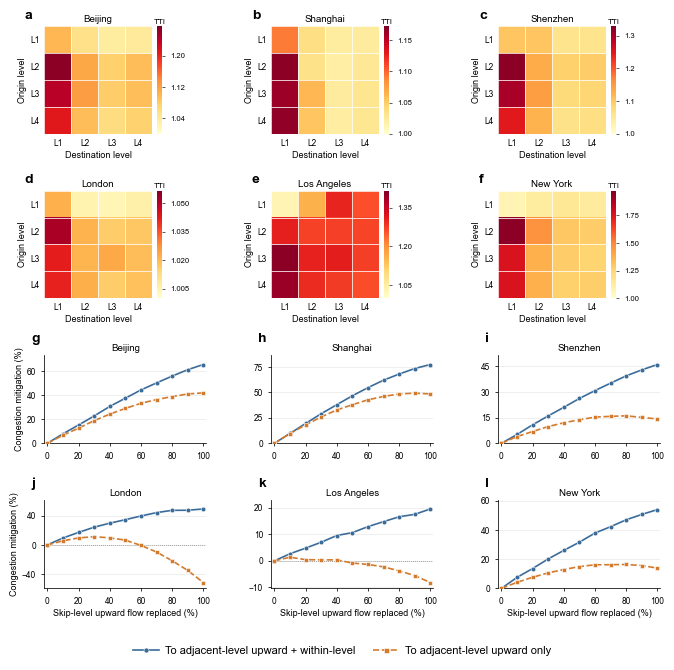

Saved figure: results\figures\Fig3_hierarchical_congestion.jpg


In [117]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


SUMMARY_DIR = Path("results/summary_tables")
EXPERIMENT_DIR = Path("results/traffic_assignment_results")
OUTPUT_PATH = Path("results/figures/Fig3_hierarchical_congestion.jpg")

CITY_CONFIGS = [
    ("Beijing", "beijing"),
    ("Shanghai", "shanghai"),
    ("Shenzhen", "shenzhen"),
    ("London", "london"),
    ("Los Angeles", "losangeles"),
    ("New York", "newyork"),
]

LEVELS = [1, 2, 3, 4]
LEVEL_LABELS = ["L1", "L2", "L3", "L4"]

RESTRUCTURING_SERIES = {
    "adjacent_and_within": {
        "filename": "multi_to_adjacent_and_within_commuting_restructuring_results.csv",
        "label": "To adjacent-level upward + within-level",
        "color": "#3B6C99",
        "linestyle": "-",
        "marker": "o",
    },
    "adjacent_only": {
        "filename": "multi_to_adjacent_commuting_restructuring_results.csv",
        "label": "To adjacent-level upward only",
        "color": "#D47A2C",
        "linestyle": "--",
        "marker": "s",
    },
}

FIGURE_WIDTH_CM = 18.0
FIGURE_HEIGHT_CM = 17.0
LINE_PANEL_WIDTH_RATIO = 0.90
PANEL_LABEL_SIZE = 10.0
TITLE_SIZE = 7.0
AXIS_LABEL_SIZE = 6.5
TICK_LABEL_SIZE = 6.0


mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 6.5,
        "axes.linewidth": 0.55,
        "xtick.major.width": 0.55,
        "ytick.major.width": 0.55,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


def normalize_level(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series
        .astype(str)
        .str.upper()
        .str.replace("LEVEL", "", regex=False)
        .str.replace("L", "", regex=False)
        .str.extract(r"(\d+)", expand=False),
        errors="coerce",
    )


def read_level_od(prefix: str) -> pd.DataFrame:
    path = SUMMARY_DIR / f"{prefix}_level_od.csv"
    df = pd.read_csv(path)

    required = {"o_level", "d_level", "TTI"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    df = df.loc[:, ["o_level", "d_level", "TTI"]].copy()
    df["o_level"] = normalize_level(df["o_level"])
    df["d_level"] = normalize_level(df["d_level"])
    df["TTI"] = pd.to_numeric(df["TTI"], errors="coerce")
    df = df.dropna()

    if df.duplicated(["o_level", "d_level"]).any():
        raise ValueError(f"{path} contains duplicate level OD pairs.")

    matrix = (
        df.pivot(index="o_level", columns="d_level", values="TTI")
        .reindex(index=LEVELS, columns=LEVELS)
    )
    if matrix.isna().any().any():
        raise ValueError(f"{path} does not contain all 16 level OD pairs.")

    return matrix


def read_restructuring_results(prefix: str, filename: str) -> pd.DataFrame:
    path = EXPERIMENT_DIR / prefix / filename
    df = pd.read_csv(path)

    required = {"redistribution_share", "TTI_excess_reduction_pct"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    df = df.loc[:, ["redistribution_share", "TTI_excess_reduction_pct"]].copy()
    df["redistribution_share"] = pd.to_numeric(
        df["redistribution_share"], errors="coerce"
    )
    df["TTI_excess_reduction_pct"] = pd.to_numeric(
        df["TTI_excess_reduction_pct"], errors="coerce"
    )
    df = df.dropna().sort_values("redistribution_share").reset_index(drop=True)

    expected_shares = np.linspace(0, 1, 11)
    if len(df) != 11 or not np.allclose(
        df["redistribution_share"].to_numpy(), expected_shares, atol=1e-8
    ):
        raise ValueError(
            f"{path} must contain one row for each redistribution share from 0 to 1 "
            "at intervals of 0.1."
        )

    df["replacement_share_pct"] = df["redistribution_share"] * 100
    return df


def heatmap_norm(matrix: pd.DataFrame) -> Normalize:
    values = matrix.to_numpy(dtype=float)
    data_min = float(np.nanmin(values))
    data_max = float(np.nanmax(values))
    vmin = min(1.0, data_min)

    if np.isclose(vmin, data_max):
        return Normalize(vmin=vmin - 0.01, vmax=data_max + 0.01)

    padding = max((data_max - vmin) * 0.03, 0.005)
    return Normalize(vmin=vmin, vmax=data_max + padding)


def add_panel_label(ax, label: str, x: float = -0.18, y: float = 1.04):
    ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=PANEL_LABEL_SIZE,
        fontweight="bold",
        clip_on=False,
    )


def style_line_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.55)
    ax.spines["bottom"].set_linewidth(0.55)
    ax.tick_params(axis="both", direction="out", labelsize=TICK_LABEL_SIZE)
    ax.grid(axis="y", color="#E6E6E6", linewidth=0.45, zorder=0)
    ax.set_axisbelow(True)


def set_city_specific_y_limits(ax, values: pd.Series):
    y_min = min(0.0, float(values.min()))
    y_max = max(0.0, float(values.max()))
    y_span = max(y_max - y_min, 1.0)

    lower = y_min - 0.08 * y_span if y_min < 0 else 0.0
    upper = y_max + 0.12 * y_span
    if np.isclose(lower, upper):
        upper = lower + 1.0

    ax.set_ylim(lower, upper)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, min_n_ticks=3))


def create_figure():
    heatmaps = {
        prefix: read_level_od(prefix)
        for _, prefix in CITY_CONFIGS
    }
    experiments = {
        prefix: {
            series_name: read_restructuring_results(prefix, style["filename"])
            for series_name, style in RESTRUCTURING_SERIES.items()
        }
        for _, prefix in CITY_CONFIGS
    }

    figure = plt.figure(
        figsize=(FIGURE_WIDTH_CM / 2.54, FIGURE_HEIGHT_CM / 2.54),
        facecolor="white",
    )
    grid = GridSpec(
        4,
        3,
        figure=figure,
        height_ratios=[1.0, 1.0, 0.82, 0.82],
        hspace=0.58,
        wspace=0.26,
    )

    # Panels a-f: raw TTI between hierarchy levels.
    for index, (city_name, prefix) in enumerate(CITY_CONFIGS):
        row, column = divmod(index, 3)
        ax = figure.add_subplot(grid[row, column])
        matrix = heatmaps[prefix]

        image = ax.imshow(
            matrix.to_numpy(dtype=float),
            cmap="YlOrRd",
            norm=heatmap_norm(matrix),
            aspect="equal",
            interpolation="nearest",
        )
        ax.set_anchor("W")

        ax.set_xticks(np.arange(4), labels=LEVEL_LABELS)
        ax.set_yticks(np.arange(4), labels=LEVEL_LABELS)
        ax.tick_params(which="major", length=0, labelsize=TICK_LABEL_SIZE)
        ax.set_xticks(np.arange(-0.5, 4, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 4, 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=0.55)
        ax.tick_params(which="minor", length=0)

        ax.set_title(city_name, fontsize=TITLE_SIZE, pad=3.0)
        ax.set_xlabel("Destination level", fontsize=AXIS_LABEL_SIZE, labelpad=2.0)
        ax.set_ylabel("Origin level", fontsize=AXIS_LABEL_SIZE, labelpad=2.0)

        for spine in ax.spines.values():
            spine.set_visible(False)

        colorbar_ax = inset_axes(
            ax,
            width="4.5%",
            height="100%",
            loc="lower left",
            bbox_to_anchor=(1.05, 0, 1, 1),
            bbox_transform=ax.transAxes,
            borderpad=0,
        )
        colorbar = figure.colorbar(image, cax=colorbar_ax)
        colorbar.outline.set_visible(False)
        colorbar.ax.tick_params(labelsize=5.5, length=2.0, width=0.45)
        colorbar.ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
        colorbar.ax.set_title("TTI", fontsize=5.8, pad=2.0)

        add_panel_label(ax, chr(ord("a") + index))

    # Panels g-l: replacement of skip-level upward commuting flows.
    for index, (city_name, prefix) in enumerate(CITY_CONFIGS):
        row, column = divmod(index, 3)
        line_grid = grid[row + 2, column].subgridspec(
            1,
            2,
            width_ratios=[LINE_PANEL_WIDTH_RATIO, 1 - LINE_PANEL_WIDTH_RATIO],
            wspace=0,
        )
        ax = figure.add_subplot(line_grid[0, 0])
        city_data = experiments[prefix]

        for series_name, style in RESTRUCTURING_SERIES.items():
            data = city_data[series_name]
            ax.plot(
                data["replacement_share_pct"],
                data["TTI_excess_reduction_pct"],
                color=style["color"],
                linestyle=style["linestyle"],
                linewidth=1.2,
                marker=style["marker"],
                markersize=3.4,
                markerfacecolor=style["color"],
                markeredgecolor="white",
                markeredgewidth=0.4,
                zorder=3,
            )
        ax.axhline(0, color="#777777", linestyle=":", linewidth=0.55, zorder=1)

        ax.set_xlim(-2, 102)
        ax.xaxis.set_major_locator(FixedLocator([0, 20, 40, 60, 80, 100]))
        y_values = pd.concat(
            [
                data["TTI_excess_reduction_pct"]
                for data in city_data.values()
            ],
            ignore_index=True,
        )
        set_city_specific_y_limits(ax, y_values)
        ax.set_title(city_name, fontsize=TITLE_SIZE, pad=3.0)

        if row == 1:
            ax.set_xlabel(
                "Skip-level upward flow replaced (%)",
                fontsize=AXIS_LABEL_SIZE,
                labelpad=2.0,
            )
        if column == 0:
            ax.set_ylabel(
                "Congestion mitigation (%)",
                fontsize=AXIS_LABEL_SIZE,
                labelpad=2.0,
            )

        style_line_axis(ax)
        add_panel_label(ax, chr(ord("g") + index), x=-0.08, y=1.12)

    legend_handles = [
        Line2D(
            [0],
            [0],
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=1.2,
            marker=style["marker"],
            markersize=3.6,
            markerfacecolor=style["color"],
            markeredgecolor="white",
            markeredgewidth=0.4,
            label=style["label"],
        )
        for style in RESTRUCTURING_SERIES.values()
    ]
    figure.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.018),
        ncol=2,
        frameon=False,
        fontsize=8.0,
        handlelength=2.3,
        handletextpad=0.55,
        columnspacing=1.6,
        borderaxespad=0,
    )

    figure.subplots_adjust(
        left=0.08,
        right=0.975,
        top=0.965,
        bottom=0.125,
    )
    return figure


def main():
    figure = create_figure()
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        OUTPUT_PATH,
        dpi=600,
        format="jpg",
        facecolor="white",
        bbox_inches="tight",
        pil_kwargs={"quality": 100, "subsampling": 0},
    )
    plt.show()
    plt.close(figure)
    print(f"Saved figure: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

Saved figure: results\figures\Fig3_relative_TTI.jpg


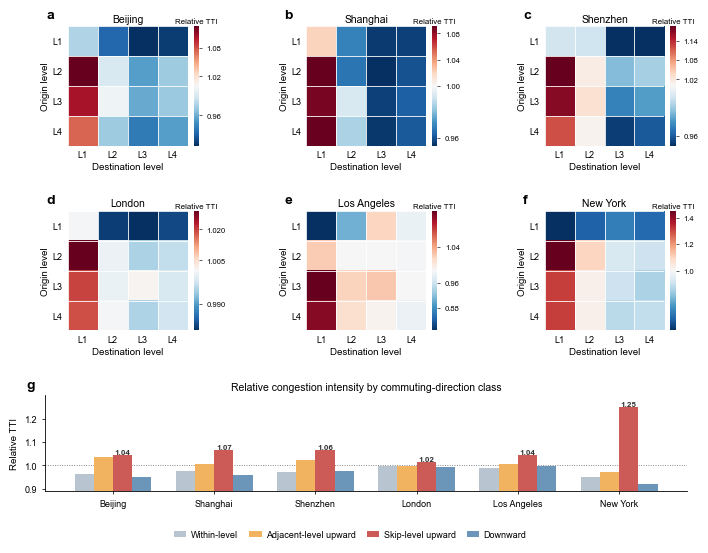

In [119]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


SUMMARY_DIR = Path("results/summary_tables")
OUTPUT_PATH = Path("results/figures/Fig3_relative_TTI.jpg")

CITY_CONFIGS = [
    ("Beijing", "beijing"),
    ("Shanghai", "shanghai"),
    ("Shenzhen", "shenzhen"),
    ("London", "london"),
    ("Los Angeles", "losangeles"),
    ("New York", "newyork"),
]

LEVELS = [1, 2, 3, 4]
LEVEL_LABELS = ["L1", "L2", "L3", "L4"]

CLASS_ORDER = ["within", "adjacent_upward", "skip_upward", "downward"]
CLASS_STYLES = {
    "within": {"label": "Within-level", "color": "#B8C4CF"},
    "adjacent_upward": {"label": "Adjacent-level upward", "color": "#F1B35F"},
    "skip_upward": {"label": "Skip-level upward", "color": "#CC5A57"},
    "downward": {"label": "Downward", "color": "#6B95B9"},
}

FIGURE_WIDTH_CM = 18.0
FIGURE_HEIGHT_CM = 13.9
PANEL_LABEL_SIZE = 10.0
TITLE_SIZE = 7.5
AXIS_LABEL_SIZE = 7.0
TICK_LABEL_SIZE = 6.5
LEGEND_SIZE = 6.5


mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 7.0,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.55,
        "ytick.major.width": 0.55,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


def normalize_level(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series
        .astype(str)
        .str.upper()
        .str.replace("LEVEL", "", regex=False)
        .str.replace("L", "", regex=False)
        .str.extract(r"(\d+)", expand=False),
        errors="coerce",
    )


def classify_direction(origin: int, destination: int) -> str:
    difference = origin - destination
    if difference == 0:
        return "within"
    if difference == 1:
        return "adjacent_upward"
    if difference >= 2:
        return "skip_upward"
    return "downward"


def read_city_data(prefix: str) -> tuple[pd.DataFrame, pd.Series]:
    path = SUMMARY_DIR / f"{prefix}_level_od.csv"
    if not path.exists():
        raise FileNotFoundError(f"Required input file not found: {path}")

    df = pd.read_csv(path)
    required = {"o_level", "d_level", "TTI", "flow"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    df = df.loc[:, ["o_level", "d_level", "TTI", "flow"]].copy()
    df["o_level"] = normalize_level(df["o_level"])
    df["d_level"] = normalize_level(df["d_level"])
    df["TTI"] = pd.to_numeric(df["TTI"], errors="coerce")
    df["flow"] = pd.to_numeric(df["flow"], errors="coerce")

    if df.isna().any().any():
        raise ValueError(f"{path} contains missing or non-numeric values.")
    if not df["o_level"].isin(LEVELS).all() or not df["d_level"].isin(LEVELS).all():
        raise ValueError(f"{path} contains hierarchy levels outside L1-L4.")
    if (df["TTI"] <= 0).any() or (df["flow"] < 0).any():
        raise ValueError(f"TTI must be positive and flow must be non-negative: {path}")

    df["weighted_tti"] = df["TTI"] * df["flow"]
    df = (
        df.groupby(["o_level", "d_level"], as_index=False)
        .agg(flow=("flow", "sum"), weighted_tti=("weighted_tti", "sum"))
    )
    if (df["flow"] <= 0).any():
        raise ValueError(f"Every level OD pair must have positive flow: {path}")

    df["TTI"] = df["weighted_tti"] / df["flow"]
    complete_pairs = pd.MultiIndex.from_product(
        [LEVELS, LEVELS], names=["o_level", "d_level"]
    )
    observed_pairs = pd.MultiIndex.from_frame(df[["o_level", "d_level"]])
    missing_pairs = complete_pairs.difference(observed_pairs)
    if len(missing_pairs):
        labels = [f"L{o}->L{d}" for o, d in missing_pairs]
        raise ValueError(f"Missing level OD pairs in {path}: {labels}")

    city_tti = df["weighted_tti"].sum() / df["flow"].sum()
    df["relative_tti"] = df["TTI"] / city_tti
    df["direction_class"] = [
        classify_direction(int(o), int(d))
        for o, d in zip(df["o_level"], df["d_level"])
    ]

    class_summary = (
        df.assign(class_weighted_tti=df["TTI"] * df["flow"])
        .groupby("direction_class")
        .agg(flow=("flow", "sum"), weighted_tti=("class_weighted_tti", "sum"))
    )
    class_summary["relative_tti"] = (
        class_summary["weighted_tti"] / class_summary["flow"] / city_tti
    )
    class_relative_tti = class_summary["relative_tti"].reindex(CLASS_ORDER)

    matrix = (
        df.pivot(index="o_level", columns="d_level", values="relative_tti")
        .reindex(index=LEVELS, columns=LEVELS)
    )
    return matrix, class_relative_tti


def heatmap_norm(matrix: pd.DataFrame) -> TwoSlopeNorm:
    values = matrix.to_numpy(dtype=float)
    vmin = float(np.nanmin(values))
    vmax = float(np.nanmax(values))
    span = max(vmax - vmin, 0.02)
    if np.isclose(vmin, 1.0):
        vmin = 1.0 - 0.05 * span
    if np.isclose(vmax, 1.0):
        vmax = 1.0 + 0.05 * span
    return TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)


def add_panel_label(ax, label: str, x: float = -0.18, y: float = 1.04):
    ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=PANEL_LABEL_SIZE,
        fontweight="bold",
        clip_on=False,
    )


def create_figure():
    city_data = {
        prefix: read_city_data(prefix)
        for _, prefix in CITY_CONFIGS
    }

    figure = plt.figure(
        figsize=(FIGURE_WIDTH_CM / 2.54, FIGURE_HEIGHT_CM / 2.54),
        facecolor="white",
    )
    grid = GridSpec(
        3,
        3,
        figure=figure,
        height_ratios=[1.0, 1.0, 0.80],
        hspace=0.58,
        wspace=0.45,
    )

    for index, (city_name, prefix) in enumerate(CITY_CONFIGS):
        row, column = divmod(index, 3)
        ax = figure.add_subplot(grid[row, column])
        matrix = city_data[prefix][0]

        image = ax.imshow(
            matrix.to_numpy(dtype=float),
            cmap="RdBu_r",
            norm=heatmap_norm(matrix),
            aspect="equal",
            interpolation="nearest",
        )
        ax.set_xticks(np.arange(4), labels=LEVEL_LABELS)
        ax.set_yticks(np.arange(4), labels=LEVEL_LABELS)
        ax.tick_params(which="major", length=0, labelsize=TICK_LABEL_SIZE)
        ax.set_xticks(np.arange(-0.5, 4, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 4, 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=0.6)
        ax.tick_params(which="minor", length=0)
        ax.set_title(city_name, fontsize=TITLE_SIZE, pad=3.0)
        ax.set_xlabel("Destination level", fontsize=AXIS_LABEL_SIZE, labelpad=2.0)
        ax.set_ylabel("Origin level", fontsize=AXIS_LABEL_SIZE, labelpad=2.0)
        for spine in ax.spines.values():
            spine.set_visible(False)

        colorbar_ax = inset_axes(
            ax,
            width="4.5%",
            height="100%",
            loc="lower left",
            bbox_to_anchor=(1.05, 0, 1, 1),
            bbox_transform=ax.transAxes,
            borderpad=0,
        )
        colorbar = figure.colorbar(image, cax=colorbar_ax)
        colorbar.outline.set_visible(False)
        colorbar.ax.tick_params(labelsize=5.5, length=2.0, width=0.45)
        colorbar.ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
        colorbar.ax.set_title("Relative TTI", fontsize=5.7, pad=2.0)
        add_panel_label(ax, chr(ord("a") + index))

    ax = figure.add_subplot(grid[2, :])
    x = np.arange(len(CITY_CONFIGS))
    width = 0.19
    all_values = []

    for class_index, direction_class in enumerate(CLASS_ORDER):
        values = np.array(
            [city_data[prefix][1].loc[direction_class] for _, prefix in CITY_CONFIGS]
        )
        all_values.extend(values)
        positions = x + (class_index - 1.5) * width
        bars = ax.bar(
            positions,
            values,
            width=width,
            color=CLASS_STYLES[direction_class]["color"],
            edgecolor="none",
            zorder=3,
        )
        if direction_class == "skip_upward":
            for bar, value in zip(bars, values):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    value,
                    f"{value:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=5.8,
                    fontweight="bold",
                    color="#333333",
                    clip_on=False,
                )

    y_min = min(min(all_values), 1.0)
    y_max = max(max(all_values), 1.0)
    y_span = max(y_max - y_min, 0.05)
    ax.set_ylim(y_min - 0.10 * y_span, y_max + 0.16 * y_span)
    ax.axhline(1.0, color="#777777", linestyle=":", linewidth=0.65, zorder=1)
    ax.set_xticks(x, labels=[city for city, _ in CITY_CONFIGS])
    ax.set_ylabel("Relative TTI", fontsize=AXIS_LABEL_SIZE)
    ax.set_title(
        "Relative congestion intensity by commuting-direction class",
        fontsize=TITLE_SIZE,
        pad=4.0,
    )
    ax.tick_params(axis="both", direction="out", labelsize=TICK_LABEL_SIZE)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    add_panel_label(ax, "g", x=-0.03, y=1.04)

    legend_handles = [
        Patch(
            facecolor=CLASS_STYLES[key]["color"],
            edgecolor="none",
            label=CLASS_STYLES[key]["label"],
        )
        for key in CLASS_ORDER
    ]
    figure.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.012),
        ncol=4,
        frameon=False,
        fontsize=LEGEND_SIZE,
        handlelength=1.4,
        handletextpad=0.45,
        columnspacing=1.25,
    )

    figure.subplots_adjust(left=0.07, right=0.975, top=0.965, bottom=0.115)
    return figure


def main():
    figure = create_figure()
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        OUTPUT_PATH,
        dpi=600,
        format="jpg",
        facecolor="white",
        pil_kwargs={"quality": 100, "subsampling": 0},
    )
    #plt.close(figure)
    print(f"Saved figure: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

Saved figure: results\figures\Fig3_relative_TTI_5_levels.jpg


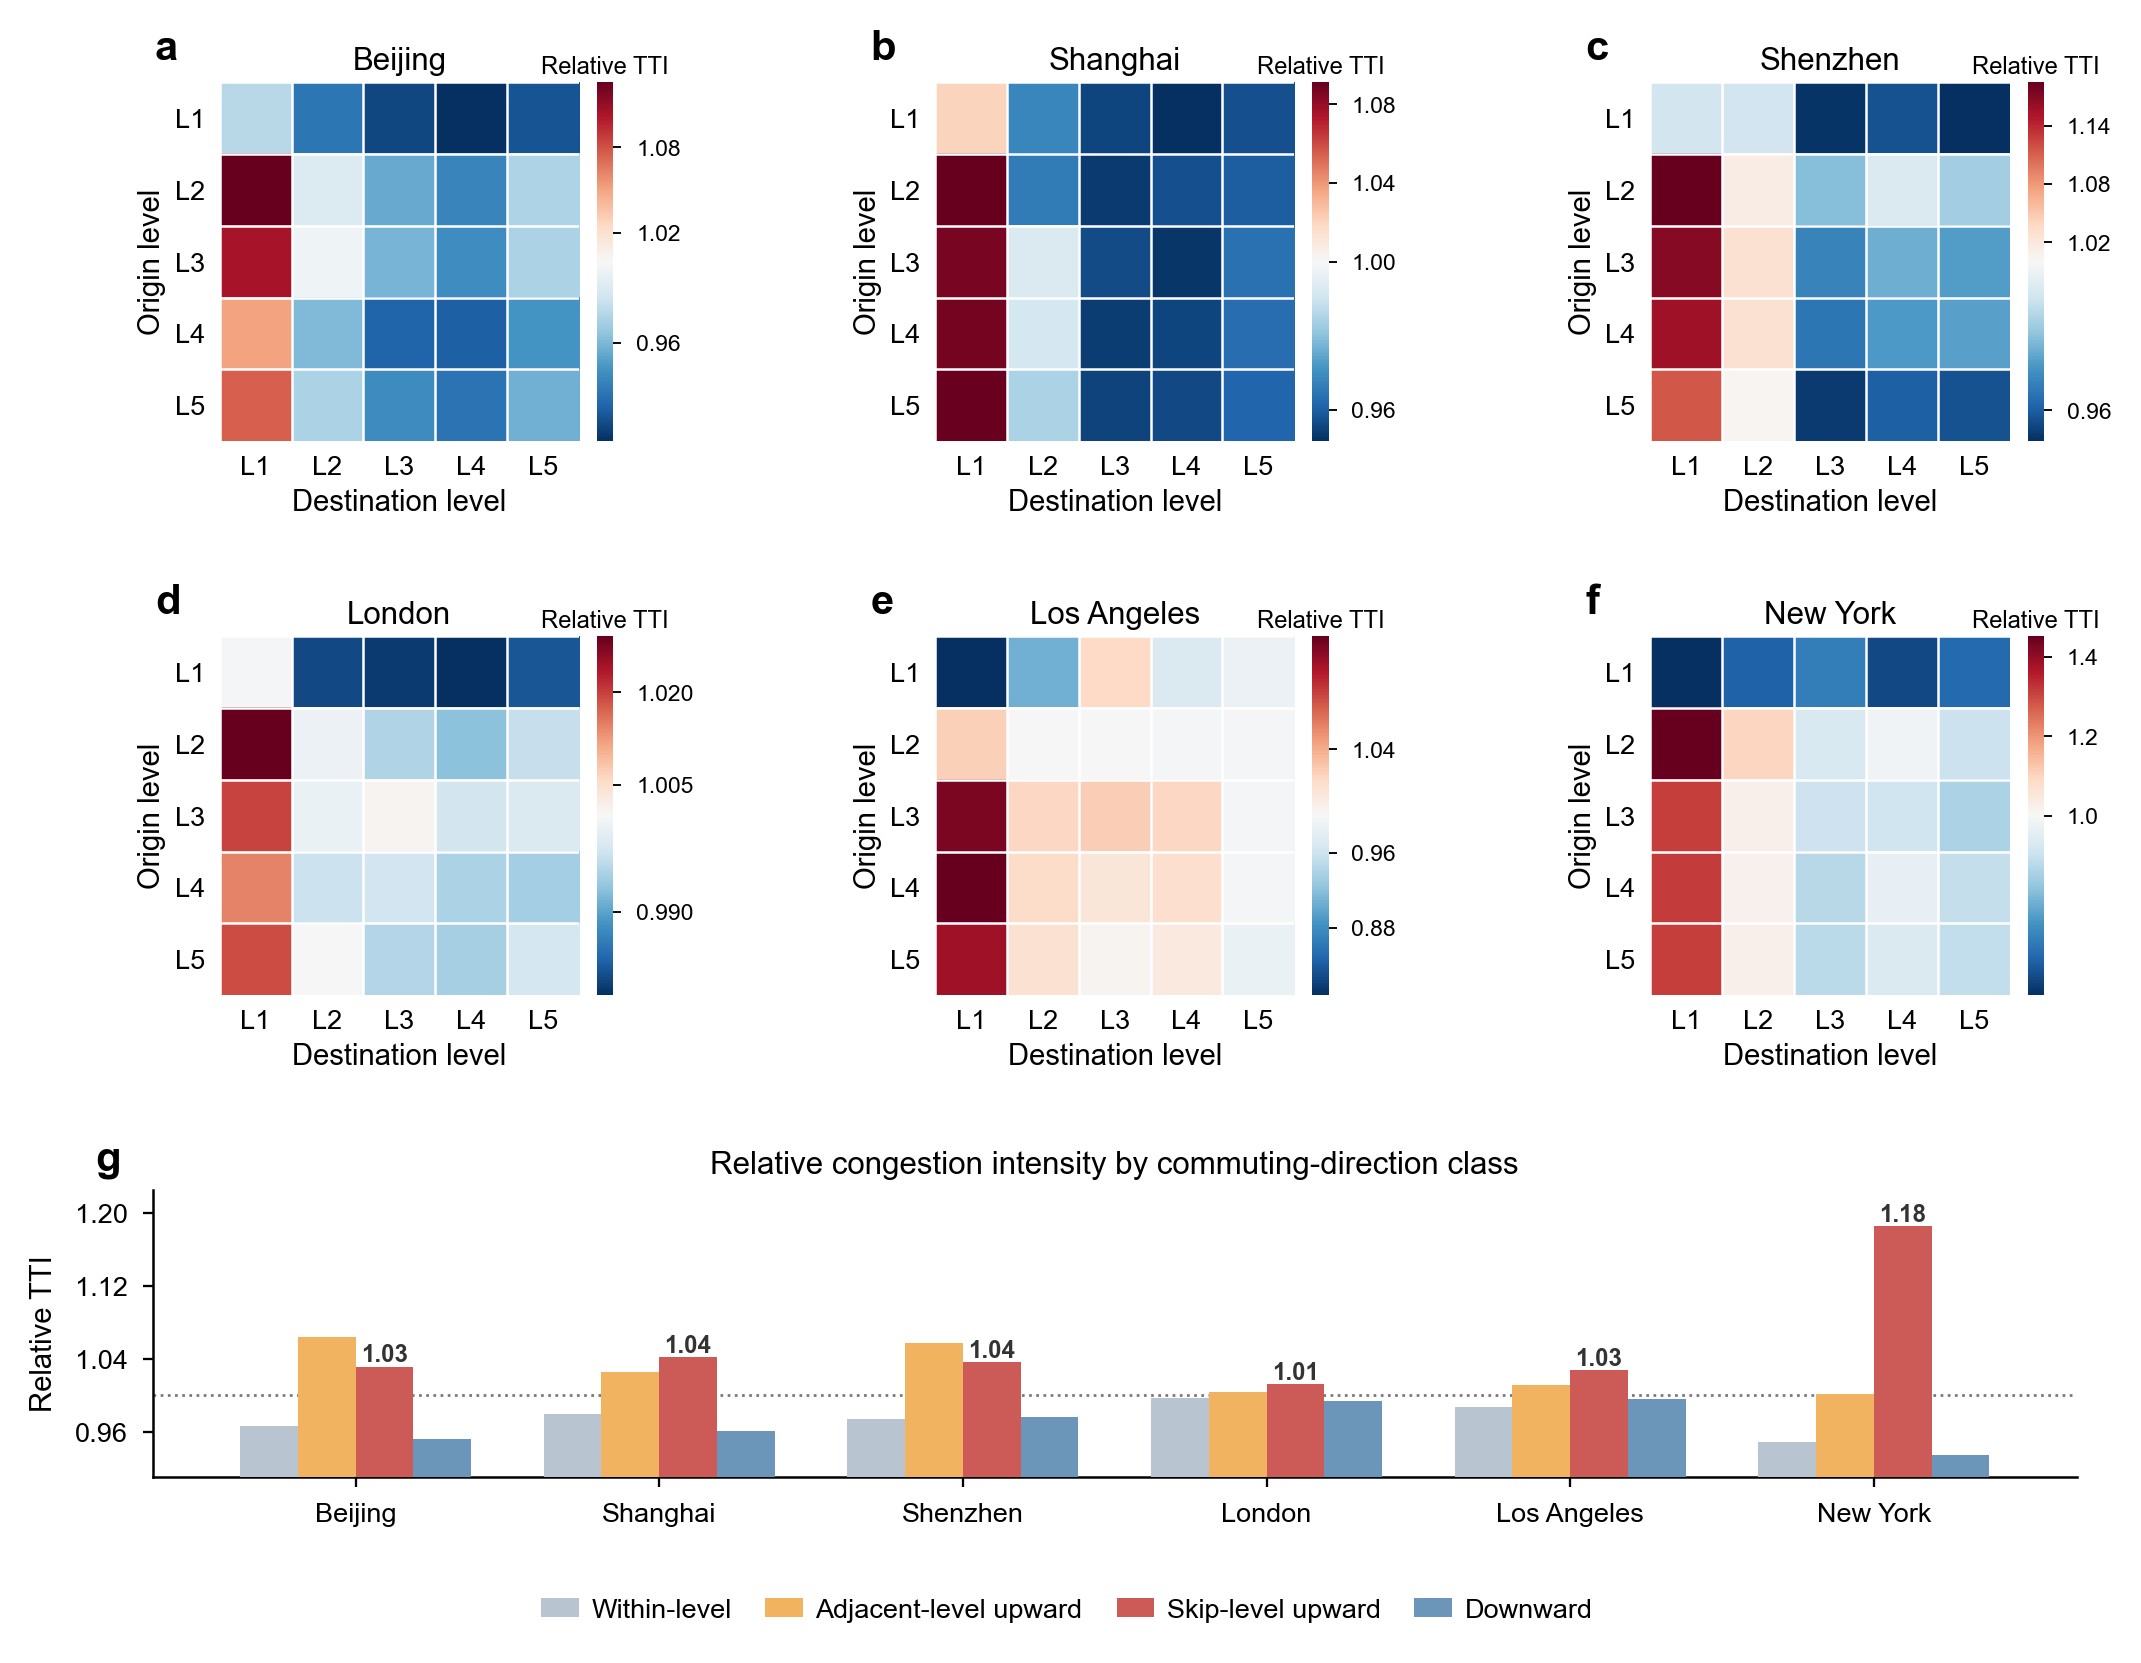

In [169]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


SUMMARY_DIR = Path("results/summary_tables")
OUTPUT_PATH = Path("results/figures/Fig3_relative_TTI_5_levels.jpg")

CITY_CONFIGS = [
    ("Beijing", "beijing"),
    ("Shanghai", "shanghai"),
    ("Shenzhen", "shenzhen"),
    ("London", "london"),
    ("Los Angeles", "losangeles"),
    ("New York", "newyork"),
]

LEVELS = [1, 2, 3, 4, 5]
LEVEL_LABELS = ["L1", "L2", "L3", "L4", "L5"]

CLASS_ORDER = ["within", "adjacent_upward", "skip_upward", "downward"]
CLASS_STYLES = {
    "within": {"label": "Within-level", "color": "#B8C4CF"},
    "adjacent_upward": {"label": "Adjacent-level upward", "color": "#F1B35F"},
    "skip_upward": {"label": "Skip-level upward", "color": "#CC5A57"},
    "downward": {"label": "Downward", "color": "#6B95B9"},
}

FIGURE_WIDTH_CM = 18.0
FIGURE_HEIGHT_CM = 13.9
PANEL_LABEL_SIZE = 10.0
TITLE_SIZE = 7.5
AXIS_LABEL_SIZE = 7.0
TICK_LABEL_SIZE = 6.5
LEGEND_SIZE = 6.5


mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 7.0,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.55,
        "ytick.major.width": 0.55,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


def normalize_level(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series
        .astype(str)
        .str.upper()
        .str.replace("LEVEL", "", regex=False)
        .str.replace("L", "", regex=False)
        .str.extract(r"(\d+)", expand=False),
        errors="coerce",
    )


def classify_direction(origin: int, destination: int) -> str:
    difference = origin - destination
    if difference == 0:
        return "within"
    if difference == 1:
        return "adjacent_upward"
    if difference >= 2:
        return "skip_upward"
    return "downward"


def read_city_data(prefix: str) -> tuple[pd.DataFrame, pd.Series]:
    path = SUMMARY_DIR / f"{prefix}_level_od_5_levels.csv"
    if not path.exists():
        raise FileNotFoundError(f"Required input file not found: {path}")

    df = pd.read_csv(path)
    required = {"o_level", "d_level", "TTI", "flow"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    df = df.loc[:, ["o_level", "d_level", "TTI", "flow"]].copy()
    df["o_level"] = normalize_level(df["o_level"])
    df["d_level"] = normalize_level(df["d_level"])
    df["TTI"] = pd.to_numeric(df["TTI"], errors="coerce")
    df["flow"] = pd.to_numeric(df["flow"], errors="coerce")

    if df.isna().any().any():
        raise ValueError(f"{path} contains missing or non-numeric values.")
    if not df["o_level"].isin(LEVELS).all() or not df["d_level"].isin(LEVELS).all():
        raise ValueError(f"{path} contains hierarchy levels outside L1-L4.")
    if (df["TTI"] <= 0).any() or (df["flow"] < 0).any():
        raise ValueError(f"TTI must be positive and flow must be non-negative: {path}")

    df["weighted_tti"] = df["TTI"] * df["flow"]
    df = (
        df.groupby(["o_level", "d_level"], as_index=False)
        .agg(flow=("flow", "sum"), weighted_tti=("weighted_tti", "sum"))
    )
    if (df["flow"] <= 0).any():
        raise ValueError(f"Every level OD pair must have positive flow: {path}")

    df["TTI"] = df["weighted_tti"] / df["flow"]
    complete_pairs = pd.MultiIndex.from_product(
        [LEVELS, LEVELS], names=["o_level", "d_level"]
    )
    observed_pairs = pd.MultiIndex.from_frame(df[["o_level", "d_level"]])
    missing_pairs = complete_pairs.difference(observed_pairs)
    if len(missing_pairs):
        labels = [f"L{o}->L{d}" for o, d in missing_pairs]
        raise ValueError(f"Missing level OD pairs in {path}: {labels}")

    city_tti = df["weighted_tti"].sum() / df["flow"].sum()
    df["relative_tti"] = df["TTI"] / city_tti
    df["direction_class"] = [
        classify_direction(int(o), int(d))
        for o, d in zip(df["o_level"], df["d_level"])
    ]

    class_summary = (
        df.assign(class_weighted_tti=df["TTI"] * df["flow"])
        .groupby("direction_class")
        .agg(flow=("flow", "sum"), weighted_tti=("class_weighted_tti", "sum"))
    )
    class_summary["relative_tti"] = (
        class_summary["weighted_tti"] / class_summary["flow"] / city_tti
    )
    class_relative_tti = class_summary["relative_tti"].reindex(CLASS_ORDER)

    matrix = (
        df.pivot(index="o_level", columns="d_level", values="relative_tti")
        .reindex(index=LEVELS, columns=LEVELS)
    )
    return matrix, class_relative_tti


def heatmap_norm(matrix: pd.DataFrame) -> TwoSlopeNorm:
    values = matrix.to_numpy(dtype=float)
    vmin = float(np.nanmin(values))
    vmax = float(np.nanmax(values))
    span = max(vmax - vmin, 0.02)
    if np.isclose(vmin, 1.0):
        vmin = 1.0 - 0.05 * span
    if np.isclose(vmax, 1.0):
        vmax = 1.0 + 0.05 * span
    return TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)


def add_panel_label(ax, label: str, x: float = -0.18, y: float = 1.04):
    ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=PANEL_LABEL_SIZE,
        fontweight="bold",
        clip_on=False,
    )


def create_figure():
    city_data = {
        prefix: read_city_data(prefix)
        for _, prefix in CITY_CONFIGS
    }

    figure = plt.figure(
        figsize=(FIGURE_WIDTH_CM / 2.54, FIGURE_HEIGHT_CM / 2.54),
        facecolor="white",
    )
    grid = GridSpec(
        3,
        3,
        figure=figure,
        height_ratios=[1.0, 1.0, 0.80],
        hspace=0.58,
        wspace=0.45,
    )

    for index, (city_name, prefix) in enumerate(CITY_CONFIGS):
        row, column = divmod(index, 3)
        ax = figure.add_subplot(grid[row, column])
        matrix = city_data[prefix][0]

        image = ax.imshow(
            matrix.to_numpy(dtype=float),
            cmap="RdBu_r",
            norm=heatmap_norm(matrix),
            aspect="equal",
            interpolation="nearest",
        )
        ax.set_xticks(np.arange(5), labels=LEVEL_LABELS)
        ax.set_yticks(np.arange(5), labels=LEVEL_LABELS)
        ax.tick_params(which="major", length=0, labelsize=TICK_LABEL_SIZE)
        ax.set_xticks(np.arange(-0.5, 4, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 4, 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=0.6)
        ax.tick_params(which="minor", length=0)
        ax.set_title(city_name, fontsize=TITLE_SIZE, pad=3.0)
        ax.set_xlabel("Destination level", fontsize=AXIS_LABEL_SIZE, labelpad=2.0)
        ax.set_ylabel("Origin level", fontsize=AXIS_LABEL_SIZE, labelpad=2.0)
        for spine in ax.spines.values():
            spine.set_visible(False)

        colorbar_ax = inset_axes(
            ax,
            width="4.5%",
            height="100%",
            loc="lower left",
            bbox_to_anchor=(1.05, 0, 1, 1),
            bbox_transform=ax.transAxes,
            borderpad=0,
        )
        colorbar = figure.colorbar(image, cax=colorbar_ax)
        colorbar.outline.set_visible(False)
        colorbar.ax.tick_params(labelsize=5.5, length=2.0, width=0.45)
        colorbar.ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
        colorbar.ax.set_title("Relative TTI", fontsize=5.7, pad=2.0)
        add_panel_label(ax, chr(ord("a") + index))

    ax = figure.add_subplot(grid[2, :])
    x = np.arange(len(CITY_CONFIGS))
    width = 0.19
    all_values = []

    for class_index, direction_class in enumerate(CLASS_ORDER):
        values = np.array(
            [city_data[prefix][1].loc[direction_class] for _, prefix in CITY_CONFIGS]
        )
        all_values.extend(values)
        positions = x + (class_index - 1.5) * width
        bars = ax.bar(
            positions,
            values,
            width=width,
            color=CLASS_STYLES[direction_class]["color"],
            edgecolor="none",
            zorder=3,
        )
        if direction_class == "skip_upward":
            for bar, value in zip(bars, values):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    value,
                    f"{value:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=5.8,
                    fontweight="bold",
                    color="#333333",
                    clip_on=False,
                )

    y_min = min(min(all_values), 1.0)
    y_max = max(max(all_values), 1.0)
    y_span = max(y_max - y_min, 0.05)
    ax.set_ylim(y_min - 0.10 * y_span, y_max + 0.16 * y_span)
    ax.axhline(1.0, color="#777777", linestyle=":", linewidth=0.65, zorder=1)
    ax.set_xticks(x, labels=[city for city, _ in CITY_CONFIGS])
    ax.set_ylabel("Relative TTI", fontsize=AXIS_LABEL_SIZE)
    ax.set_title(
        "Relative congestion intensity by commuting-direction class",
        fontsize=TITLE_SIZE,
        pad=4.0,
    )
    ax.tick_params(axis="both", direction="out", labelsize=TICK_LABEL_SIZE)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    add_panel_label(ax, "g", x=-0.03, y=1.04)

    legend_handles = [
        Patch(
            facecolor=CLASS_STYLES[key]["color"],
            edgecolor="none",
            label=CLASS_STYLES[key]["label"],
        )
        for key in CLASS_ORDER
    ]
    figure.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.012),
        ncol=4,
        frameon=False,
        fontsize=LEGEND_SIZE,
        handlelength=1.4,
        handletextpad=0.45,
        columnspacing=1.25,
    )

    figure.subplots_adjust(left=0.07, right=0.975, top=0.965, bottom=0.115)
    return figure


def main():
    figure = create_figure()
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        OUTPUT_PATH,
        dpi=600,
        format="jpg",
        facecolor="white",
        pil_kwargs={"quality": 100, "subsampling": 0},
    )
    #plt.close(figure)
    print(f"Saved figure: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

In [181]:
od = pd.read_csv("results/summary_tables/beijing_level_od.csv")
od['gap'] = od['o_level']-od['d_level']

In [177]:
od.loc[(od['gap']==1),'con_drive_time'].sum()/od.loc[(od['gap']==1),'drive_time'].sum()

1.2072035966342467

In [183]:
od.loc[(od['gap']==1),'flow'].sum()/od['flow'].sum()

0.14556864962487967

In [175]:
od['con_drive_time'].sum()/od['drive_time'].sum()

1.137021295157984

In [176]:
1.1709147751553683/1.137021295157984

1.0298090107386029

## Fig.4

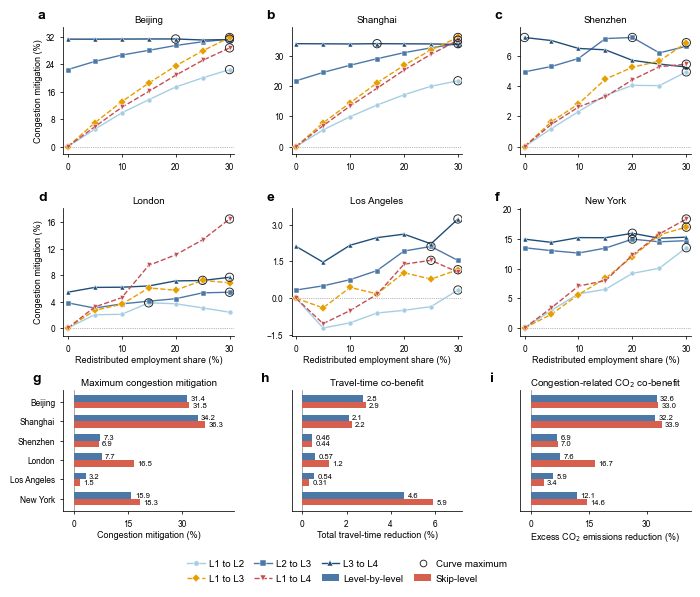

Saved figure: results\figures\Fig4_redistribution_outcomes.jpg


In [80]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator


RESULTS_DIR = Path("results/traffic_assignment_results")
OUTPUT_PATH = Path("results/figures/Fig4_redistribution_outcomes.jpg")


CITY_CONFIGS = [
    {"city_name": "Beijing", "prefix": "beijing"},
    {"city_name": "Shanghai", "prefix": "shanghai"},
    {"city_name": "Shenzhen", "prefix": "shenzhen"},
    {"city_name": "London", "prefix": "london"},
    {"city_name": "Los Angeles", "prefix": "losangeles"},
    {"city_name": "New York", "prefix": "newyork"},
]


SCENARIO_ORDER = [
    "L1_to_L2",
    "L2_to_L3",
    "L3_to_L4",
    "L1_to_L3",
    "L1_to_L4",
]

SCENARIO_STYLES = {
    "L1_to_L2": {
        "label": "L1 to L2",
        "color": "#A6CEE3",
        "linestyle": "-",
        "marker": "o",
    },
    "L2_to_L3": {
        "label": "L2 to L3",
        "color": "#4C78A8",
        "linestyle": "-",
        "marker": "s",
    },
    "L3_to_L4": {
        "label": "L3 to L4",
        "color": "#1F4E79",
        "linestyle": "-",
        "marker": "^",
    },
    "L1_to_L3": {
        "label": "L1 to L3",
        "color": "#E69F00",
        "linestyle": "--",
        "marker": "D",
    },
    "L1_to_L4": {
        "label": "L1 to L4",
        "color": "#C44E52",
        "linestyle": "--",
        "marker": "v",
    },
}


PATHWAY_SCENARIOS = {
    "level_by_level": ["L1_to_L2", "L2_to_L3", "L3_to_L4"],
    "skip_level": ["L1_to_L3", "L1_to_L4"],
}

PATHWAY_STYLES = {
    "level_by_level": {
        "label": "Level-by-level",
        "color": "#4C78A8",
    },
    "skip_level": {
        "label": "Skip-level",
        "color": "#D6604D",
    },
}


FIGURE_WIDTH_CM = 18.0
FIGURE_HEIGHT_CM = 15.0
PANEL_LABEL_SIZE = 10
TITLE_SIZE = 7.0
AXIS_LABEL_SIZE = 6.5
TICK_LABEL_SIZE = 6.0
LEGEND_SIZE = 7


mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 6.5,
        "axes.linewidth": 0.55,
        "xtick.major.width": 0.55,
        "ytick.major.width": 0.55,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


def result_path(prefix: str) -> Path:
    return RESULTS_DIR / prefix / "scenario_simulation_results_final.csv"


def read_city_results(prefix: str) -> pd.DataFrame:
    path = result_path(prefix)
    if not path.exists():
        raise FileNotFoundError(f"Required scenario file not found: {path}")

    df = pd.read_csv(path)
    required = {
        "scenario",
        "prop",
        "congestion_mitigation_pct",
        "CO2_excess_reduction_pct",
        "TTT",
    }
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    df = df.loc[:, list(required)].copy()
    df["scenario"] = df["scenario"].astype(str).str.strip()

    for column in ["prop", "congestion_mitigation_pct", "CO2_excess_reduction_pct", "TTT"]:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    if df[["prop", "congestion_mitigation_pct", "CO2_excess_reduction_pct", "TTT"]].isna().any().any():
        raise ValueError(f"{path} contains missing or non-numeric plotting values.")
    if not df["prop"].between(0, 0.3 + 1e-9).all():
        raise ValueError(f"prop must range from 0 to 0.3: {path}")
    if (df["TTT"] <= 0).any():
        raise ValueError(f"TTT must be greater than zero: {path}")

    expected = {"baseline", *SCENARIO_ORDER}
    missing_scenarios = sorted(expected.difference(df["scenario"]))
    if missing_scenarios:
        raise ValueError(f"Missing scenarios in {path}: {missing_scenarios}")

    baseline = df.loc[df["scenario"] == "baseline", ["TTT"]].drop_duplicates()
    if len(baseline) != 1:
        raise ValueError(f"Baseline rows contain inconsistent TTT values: {path}")

    for scenario in SCENARIO_ORDER:
        curve = df.loc[df["scenario"] == scenario]
        if curve.empty:
            raise ValueError(f"No rows found for scenario '{scenario}' in {path}.")
        if curve["prop"].duplicated().any():
            raise ValueError(f"Duplicate prop values for scenario '{scenario}' in {path}.")

    return df


def select_pathway_optimum(df: pd.DataFrame, pathway: str) -> pd.Series:
    candidates = df.loc[df["scenario"].isin(PATHWAY_SCENARIOS[pathway])].copy()
    candidates["scenario_order"] = candidates["scenario"].map(
        {scenario: index for index, scenario in enumerate(SCENARIO_ORDER)}
    )

    return candidates.sort_values(
        ["congestion_mitigation_pct", "prop", "scenario_order"],
        ascending=[False, True, True],
    ).iloc[0]


def summarize_city(df: pd.DataFrame, city_name: str) -> dict:
    baseline = df.loc[df["scenario"] == "baseline"].iloc[0]
    summary = {"city_name": city_name}

    for pathway in PATHWAY_SCENARIOS:
        optimum = select_pathway_optimum(df, pathway)
        summary[f"{pathway}_congestion"] = optimum["congestion_mitigation_pct"]
        summary[f"{pathway}_travel_time"] = (
            (baseline["TTT"] - optimum["TTT"]) / baseline["TTT"] * 100.0
        )
        summary[f"{pathway}_co2"] = optimum["CO2_excess_reduction_pct"]

    return summary


def add_panel_label(ax, label: str, x=-0.15):
    ax.text(
        x,
        1.04,
        label,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=PANEL_LABEL_SIZE,
        fontweight="bold",
        clip_on=False,
    )


def style_open_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.55)
    ax.spines["bottom"].set_linewidth(0.55)
    ax.tick_params(axis="both", direction="out", labelsize=TICK_LABEL_SIZE)


def set_city_y_limits(ax, values):
    values = np.asarray(values, dtype=float)
    y_min = min(0.0, float(np.nanmin(values)))
    y_max = max(0.0, float(np.nanmax(values)))
    span = y_max - y_min
    if np.isclose(span, 0.0):
        span = 1.0

    ax.set_ylim(y_min - span * 0.07, y_max + span * 0.10)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, min_n_ticks=3))


def value_label(value: float) -> str:
    return f"{value:.2f}" if abs(value) < 1 else f"{value:.1f}"


def plot_summary_panel(ax, summary, metric: str, title: str, xlabel: str, panel: str):
    plot_data = summary.iloc[::-1].reset_index(drop=True)
    y = np.arange(len(plot_data))
    bar_height = 0.34

    values = []
    for offset, pathway in [(bar_height / 2, "level_by_level"), (-bar_height / 2, "skip_level")]:
        column = f"{pathway}_{metric}"
        bar_values = plot_data[column].to_numpy(dtype=float)
        values.extend(bar_values)

        ax.barh(
            y + offset,
            bar_values,
            height=bar_height,
            color=PATHWAY_STYLES[pathway]["color"],
            edgecolor="none",
            zorder=2,
        )

    values = np.asarray(values, dtype=float)
    value_min = min(0.0, float(np.nanmin(values)))
    value_max = max(0.0, float(np.nanmax(values)))
    span = value_max - value_min
    if np.isclose(span, 0.0):
        span = 1.0

    label_offset = span * 0.025
    for index in range(len(plot_data)):
        for offset, pathway in [(bar_height / 2, "level_by_level"), (-bar_height / 2, "skip_level")]:
            value = float(plot_data.loc[index, f"{pathway}_{metric}"])
            ax.text(
                value + label_offset if value >= 0 else value - label_offset,
                index + offset,
                value_label(value),
                ha="left" if value >= 0 else "right",
                va="center",
                fontsize=5.5,
            )

    ax.set_xlim(value_min - span * 0.08, value_max + span * 0.22)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_data["city_name"], fontsize=TICK_LABEL_SIZE)
    ax.axvline(0, color="#777777", linewidth=0.45, zorder=1)
    ax.set_title(title, fontsize=TITLE_SIZE, pad=3.0)
    ax.set_xlabel(xlabel, fontsize=AXIS_LABEL_SIZE, labelpad=2.0)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4, min_n_ticks=3))
    style_open_axis(ax)
    add_panel_label(ax, panel, x=-0.18)


def create_figure():
    city_results = {
        config["prefix"]: read_city_results(config["prefix"])
        for config in CITY_CONFIGS
    }
    summary = pd.DataFrame(
        [
            summarize_city(city_results[config["prefix"]], config["city_name"])
            for config in CITY_CONFIGS
        ]
    )

    figure = plt.figure(
        figsize=(FIGURE_WIDTH_CM / 2.54, FIGURE_HEIGHT_CM / 2.54),
        facecolor="white",
    )
    grid = figure.add_gridspec(
        3,
        3,
        height_ratios=[1.0, 1.0, 0.95],
        hspace=0.43,
        wspace=0.34,
    )

    for index, config in enumerate(CITY_CONFIGS):
        row, column = divmod(index, 3)
        ax = figure.add_subplot(grid[row, column])
        df = city_results[config["prefix"]]
        y_values = []

        for scenario in SCENARIO_ORDER:
            curve = df.loc[df["scenario"] == scenario].sort_values("prop")
            style = SCENARIO_STYLES[scenario]
            x = curve["prop"].to_numpy(dtype=float) * 100.0
            y = curve["congestion_mitigation_pct"].to_numpy(dtype=float)
            y_values.extend(y)

            ax.plot(
                x,
                y,
                color=style["color"],
                linestyle=style["linestyle"],
                marker=style["marker"],
                linewidth=1.0,
                markersize=3.6,
                markerfacecolor=style["color"],
                markeredgecolor="white",
                markeredgewidth=0.35,
                zorder=3,
            )

            optimum = curve.loc[curve["congestion_mitigation_pct"].idxmax()]
            ax.scatter(
                optimum["prop"] * 100.0,
                optimum["congestion_mitigation_pct"],
                s=36,
                facecolor="none",
                edgecolor="#222222",
                linewidth=0.65,
                zorder=5,
            )

        ax.axhline(0, color="#777777", linestyle=":", linewidth=0.5, zorder=1)
        ax.set_xlim(-0.8, 30.8)
        ax.set_xticks([0, 10, 20, 30])
        set_city_y_limits(ax, y_values)
        ax.set_title(config["city_name"], fontsize=TITLE_SIZE, pad=3.0)

        if row == 1:
            ax.set_xlabel("Redistributed employment share (%)", fontsize=AXIS_LABEL_SIZE, labelpad=2.0)
        if column == 0:
            ax.set_ylabel("Congestion mitigation (%)", fontsize=AXIS_LABEL_SIZE, labelpad=2.0)

        style_open_axis(ax)
        add_panel_label(ax, chr(ord("a") + index))

    summary_specs = [
        ("congestion", "Maximum congestion mitigation", "Congestion mitigation (%)", "g"),
        ("travel_time", "Travel-time co-benefit", "Total travel-time reduction (%)", "h"),
        (
            "co2",
            r"Congestion-related CO$_2$ co-benefit",
            r"Excess CO$_2$ emissions reduction (%)",
            "i",
        ),
    ]

    for column, (metric, title, xlabel, panel) in enumerate(summary_specs):
        ax = figure.add_subplot(grid[2, column])
        plot_summary_panel(ax, summary, metric, title, xlabel, panel)
        if column > 0:
            ax.set_yticklabels([])
            ax.tick_params(axis="y", length=0)

    scenario_handles = {
        scenario: Line2D(
            [0],
            [0],
            color=SCENARIO_STYLES[scenario]["color"],
            linestyle=SCENARIO_STYLES[scenario]["linestyle"],
            marker=SCENARIO_STYLES[scenario]["marker"],
            linewidth=1.0,
            markersize=3.9,
            markerfacecolor=SCENARIO_STYLES[scenario]["color"],
            markeredgecolor="white",
            markeredgewidth=0.35,
            label=SCENARIO_STYLES[scenario]["label"],
        )
        for scenario in SCENARIO_ORDER
    }
    optimum_handle = Line2D(
        [0],
        [0],
        color="none",
        marker="o",
        markerfacecolor="none",
        markeredgecolor="#222222",
        markeredgewidth=0.65,
        markersize=4.8,
        label="Curve maximum",
    )
    pathway_handles = {
        pathway: Patch(
            facecolor=PATHWAY_STYLES[pathway]["color"],
            edgecolor="none",
            label=PATHWAY_STYLES[pathway]["label"],
        )
        for pathway in ["level_by_level", "skip_level"]
    }

    legend_handles = [
        scenario_handles["L1_to_L2"],
        scenario_handles["L1_to_L3"],
        scenario_handles["L2_to_L3"],
        scenario_handles["L1_to_L4"],
        scenario_handles["L3_to_L4"],
        pathway_handles["level_by_level"],
        optimum_handle,
        pathway_handles["skip_level"],
    ]

    figure.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.016),
        ncol=4,
        frameon=False,
        fontsize=LEGEND_SIZE,
        handlelength=1.8,
        handletextpad=0.45,
        columnspacing=1.05,
        labelspacing=0.55,
        borderaxespad=0.0,
    )

    figure.subplots_adjust(
        left=0.10,
        right=0.985,
        top=0.965,
        bottom=0.145,
    )
    return figure


def main():
    figure = create_figure()
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        OUTPUT_PATH,
        dpi=600,
        format="jpg",
        facecolor="white",
        pil_kwargs={"quality": 100, "subsampling": 0},
    )
    plt.show()
    plt.close(figure)
    print(f"Saved figure: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

## Fig.5

Saved: results\figures\Fig5_agglomeration_cost.jpg


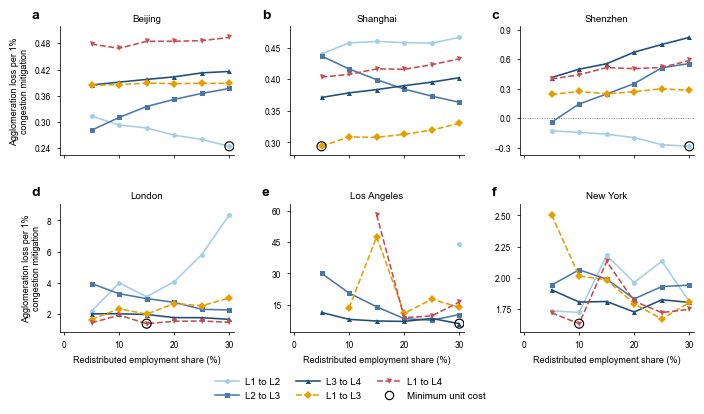

In [85]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator


RESULTS_DIR = Path("results/traffic_assignment_results")
OUTPUT_PATH = Path("results/figures/Fig5_agglomeration_cost.jpg")

CITY_CONFIGS = [
    ("Beijing", "beijing"),
    ("Shanghai", "shanghai"),
    ("Shenzhen", "shenzhen"),
    ("London", "london"),
    ("Los Angeles", "losangeles"),
    ("New York", "newyork"),
]

SCENARIO_ORDER = [
    "L1_to_L2",
    "L2_to_L3",
    "L3_to_L4",
    "L1_to_L3",
    "L1_to_L4",
]

SCENARIO_STYLES = {
    "L1_to_L2": ("L1 to L2", "#A6CEE3", "-", "o"),
    "L2_to_L3": ("L2 to L3", "#4C78A8", "-", "s"),
    "L3_to_L4": ("L3 to L4", "#1F4E79", "-", "^"),
    "L1_to_L3": ("L1 to L3", "#E69F00", "--", "D"),
    "L1_to_L4": ("L1 to L4", "#C44E52", "--", "v"),
}

mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 6.5,
        "axes.linewidth": 0.55,
        "xtick.major.width": 0.55,
        "ytick.major.width": 0.55,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


def read_city_results(prefix):
    path = RESULTS_DIR / prefix / "scenario_simulation_results_final.csv"
    if not path.exists():
        raise FileNotFoundError(f"Required result file not found: {path}")

    required = {"scenario", "prop", "congestion_mitigation_pct", "AGG_loss_pct"}
    data = pd.read_csv(path, encoding="utf-8-sig")
    missing = required.difference(data.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    data = data.loc[:, list(required)].copy()
    data["scenario"] = data["scenario"].astype(str).str.strip()
    numeric_columns = ["prop", "congestion_mitigation_pct", "AGG_loss_pct"]
    data[numeric_columns] = data[numeric_columns].apply(
        pd.to_numeric, errors="coerce"
    )

    curves = data.loc[data["scenario"].isin(SCENARIO_ORDER)].copy()
    if curves[numeric_columns].isna().any().any():
        raise ValueError(f"{path} contains missing or non-numeric plotting values.")
    if set(curves["scenario"]) != set(SCENARIO_ORDER):
        missing_scenarios = sorted(set(SCENARIO_ORDER).difference(curves["scenario"]))
        raise ValueError(f"Missing scenarios in {path}: {missing_scenarios}")
    if not curves["prop"].between(0, 0.3 + 1e-9).all():
        raise ValueError(f"prop must range from 0 to 0.3: {path}")
    if curves.duplicated(["scenario", "prop"]).any():
        raise ValueError(f"Duplicate scenario-prop combinations found in {path}")

    valid = (curves["prop"] > 0) & (curves["congestion_mitigation_pct"] > 0)
    curves["unit_agglomeration_cost"] = np.nan
    curves.loc[valid, "unit_agglomeration_cost"] = (
        curves.loc[valid, "AGG_loss_pct"]
        / curves.loc[valid, "congestion_mitigation_pct"]
    )
    return curves


def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", direction="out", labelsize=6.0)


def set_city_y_limits(ax, values):
    values = np.asarray(values, dtype=float)
    lower = float(values.min())
    upper = float(values.max())
    span = upper - lower
    if np.isclose(span, 0.0):
        span = max(abs(lower), abs(upper), 0.1) * 0.2
    ax.set_ylim(lower - 0.08 * span, upper + 0.10 * span)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, min_n_ticks=3))


def create_figure():
    city_data = [
        (city_name, read_city_results(prefix))
        for city_name, prefix in CITY_CONFIGS
    ]

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(18.0 / 2.54, 10.5 / 2.54),
        sharex=True,
    )

    for panel_index, (ax, (city_name, data)) in enumerate(
        zip(axes.flat, city_data)
    ):
        for scenario in SCENARIO_ORDER:
            label, color, linestyle, marker = SCENARIO_STYLES[scenario]
            curve = data.loc[data["scenario"] == scenario].sort_values("prop")
            ax.plot(
                curve["prop"] * 100,
                curve["unit_agglomeration_cost"],
                color=color,
                linestyle=linestyle,
                marker=marker,
                markersize=3.6,
                markeredgewidth=0,
                linewidth=1.15,
                label=label,
                zorder=2,
            )

        valid_points = data.dropna(subset=["unit_agglomeration_cost"])
        if valid_points.empty:
            ax.text(
                0.5,
                0.5,
                "No positive congestion mitigation",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=6.2,
                color="#555555",
            )
            ax.set_ylim(-0.05, 1.0)
        else:
            optimum = valid_points.sort_values(
                ["unit_agglomeration_cost", "prop"],
                ascending=[True, True],
            ).iloc[0]
            ax.scatter(
                optimum["prop"] * 100,
                optimum["unit_agglomeration_cost"],
                s=42,
                facecolors="none",
                edgecolors="black",
                linewidths=0.85,
                zorder=4,
            )
            set_city_y_limits(ax, valid_points["unit_agglomeration_cost"])

        ax.axhline(0, color="#777777", linewidth=0.65, linestyle=":", zorder=1)
        ax.set_xlim(-0.8, 30.8)
        ax.set_xticks([0, 10, 20, 30])
        style_axis(ax)

        ax.set_title(city_name, fontsize=7.0, pad=4)
        ax.text(
            -0.16,
            1.04,
            chr(97 + panel_index),
            transform=ax.transAxes,
            fontsize=10,
            fontweight="bold",
            ha="left",
            va="bottom",
            clip_on=False,
        )

        if panel_index >= 3:
            ax.set_xlabel("Redistributed employment share (%)", fontsize=6.5)
        if panel_index % 3 == 0:
            ax.set_ylabel(
                "Agglomeration loss per 1%\ncongestion mitigation",
                fontsize=6.5,
            )

    legend_handles = [
        Line2D(
            [0],
            [0],
            color=SCENARIO_STYLES[scenario][1],
            linestyle=SCENARIO_STYLES[scenario][2],
            marker=SCENARIO_STYLES[scenario][3],
            markersize=3.6,
            markeredgewidth=0,
            linewidth=1.15,
            label=SCENARIO_STYLES[scenario][0],
        )
        for scenario in SCENARIO_ORDER
    ]
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color="none",
            marker="o",
            markerfacecolor="none",
            markeredgecolor="black",
            markeredgewidth=0.85,
            markersize=6.0,
            label="Minimum unit cost",
        )
    )

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.015),
        ncol=3,
        frameon=False,
        fontsize=7,
        handlelength=2.5,
        columnspacing=1.6,
        handletextpad=0.6,
    )
    fig.subplots_adjust(
        left=0.09,
        right=0.985,
        bottom=0.20,
        top=0.94,
        wspace=0.32,
        hspace=0.38,
    )
    return fig


def main():
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    figure = create_figure()
    figure.savefig(
        OUTPUT_PATH,
        dpi=600,
        format="jpg",
        pil_kwargs={"quality": 100, "subsampling": 0},
    )
    #plt.close(figure)
    print(f"Saved: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

In [99]:
data = pd.read_csv("results/traffic_assignment_results/beijing/scenario_simulation_results_final.csv", encoding="utf-8-sig")
data["AGG_loss_pct"] = (data.loc[0,"AGG_exp_3km_w0.01"]-data["AGG_exp_3km_w0.01"])/data.loc[0,"AGG_exp_3km_w0.01"]*100

In [100]:
data.loc[0,"AGG_exp_3km_w0.01"]

123981917706.874

Saved: results\figures\agglomeration_cost_exp_10km_w0.01.jpg


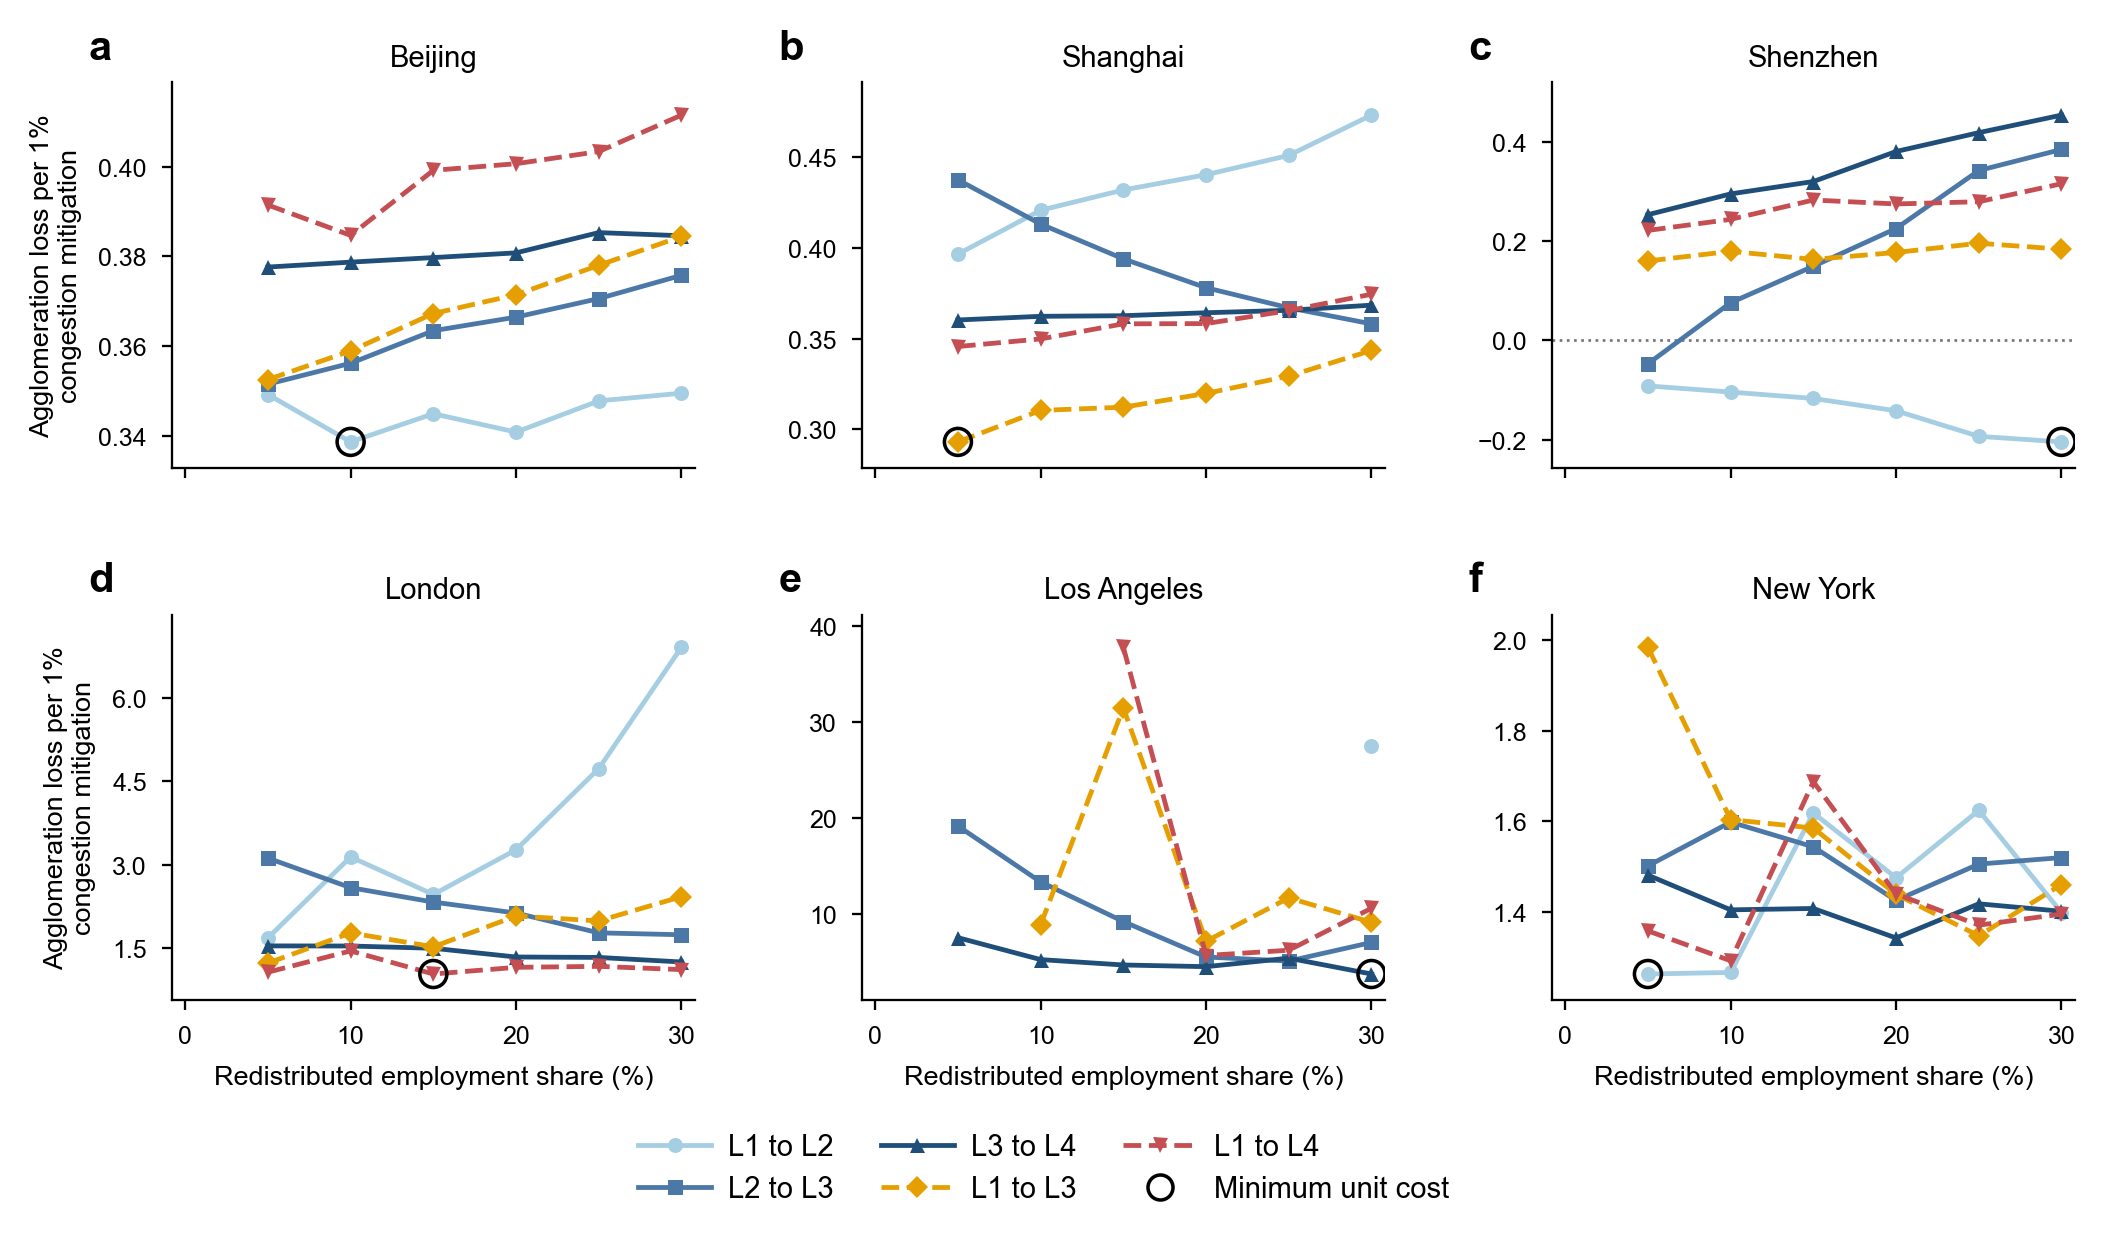

In [103]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator


RESULTS_DIR = Path("results/traffic_assignment_results")
OUTPUT_PATH = Path("results/figures/agglomeration_cost_exp_10km_w0.01.jpg")

CITY_CONFIGS = [
    ("Beijing", "beijing"),
    ("Shanghai", "shanghai"),
    ("Shenzhen", "shenzhen"),
    ("London", "london"),
    ("Los Angeles", "losangeles"),
    ("New York", "newyork"),
]

SCENARIO_ORDER = [
    "L1_to_L2",
    "L2_to_L3",
    "L3_to_L4",
    "L1_to_L3",
    "L1_to_L4",
]

SCENARIO_STYLES = {
    "L1_to_L2": ("L1 to L2", "#A6CEE3", "-", "o"),
    "L2_to_L3": ("L2 to L3", "#4C78A8", "-", "s"),
    "L3_to_L4": ("L3 to L4", "#1F4E79", "-", "^"),
    "L1_to_L3": ("L1 to L3", "#E69F00", "--", "D"),
    "L1_to_L4": ("L1 to L4", "#C44E52", "--", "v"),
}

mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 6.5,
        "axes.linewidth": 0.55,
        "xtick.major.width": 0.55,
        "ytick.major.width": 0.55,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


def read_city_results(prefix):
    path = RESULTS_DIR / prefix / "scenario_simulation_results_final.csv"
    if not path.exists():
        raise FileNotFoundError(f"Required result file not found: {path}")

    required = {"scenario", "prop", "congestion_mitigation_pct", "AGG_loss_pct"}
    data = pd.read_csv(path, encoding="utf-8-sig")
    data["AGG_loss_pct"] = (data.loc[0,"AGG_exp_10km_w0.01"]-data["AGG_exp_10km_w0.01"])/data.loc[0,"AGG_exp_10km_w0.01"]*100
    missing = required.difference(data.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    data = data.loc[:, list(required)].copy()
    data["scenario"] = data["scenario"].astype(str).str.strip()
    numeric_columns = ["prop", "congestion_mitigation_pct", "AGG_loss_pct"]
    data[numeric_columns] = data[numeric_columns].apply(
        pd.to_numeric, errors="coerce"
    )

    curves = data.loc[data["scenario"].isin(SCENARIO_ORDER)].copy()
    if curves[numeric_columns].isna().any().any():
        raise ValueError(f"{path} contains missing or non-numeric plotting values.")
    if set(curves["scenario"]) != set(SCENARIO_ORDER):
        missing_scenarios = sorted(set(SCENARIO_ORDER).difference(curves["scenario"]))
        raise ValueError(f"Missing scenarios in {path}: {missing_scenarios}")
    if not curves["prop"].between(0, 0.3 + 1e-9).all():
        raise ValueError(f"prop must range from 0 to 0.3: {path}")
    if curves.duplicated(["scenario", "prop"]).any():
        raise ValueError(f"Duplicate scenario-prop combinations found in {path}")

    valid = (curves["prop"] > 0) & (curves["congestion_mitigation_pct"] > 0)
    curves["unit_agglomeration_cost"] = np.nan
    curves.loc[valid, "unit_agglomeration_cost"] = (
        curves.loc[valid, "AGG_loss_pct"]
        / curves.loc[valid, "congestion_mitigation_pct"]
    )
    return curves


def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", direction="out", labelsize=6.0)


def set_city_y_limits(ax, values):
    values = np.asarray(values, dtype=float)
    lower = float(values.min())
    upper = float(values.max())
    span = upper - lower
    if np.isclose(span, 0.0):
        span = max(abs(lower), abs(upper), 0.1) * 0.2
    ax.set_ylim(lower - 0.08 * span, upper + 0.10 * span)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, min_n_ticks=3))


def create_figure():
    city_data = [
        (city_name, read_city_results(prefix))
        for city_name, prefix in CITY_CONFIGS
    ]

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(18.0 / 2.54, 10.5 / 2.54),
        sharex=True,
    )

    for panel_index, (ax, (city_name, data)) in enumerate(
        zip(axes.flat, city_data)
    ):
        for scenario in SCENARIO_ORDER:
            label, color, linestyle, marker = SCENARIO_STYLES[scenario]
            curve = data.loc[data["scenario"] == scenario].sort_values("prop")
            ax.plot(
                curve["prop"] * 100,
                curve["unit_agglomeration_cost"],
                color=color,
                linestyle=linestyle,
                marker=marker,
                markersize=3.6,
                markeredgewidth=0,
                linewidth=1.15,
                label=label,
                zorder=2,
            )

        valid_points = data.dropna(subset=["unit_agglomeration_cost"])
        if valid_points.empty:
            ax.text(
                0.5,
                0.5,
                "No positive congestion mitigation",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=6.2,
                color="#555555",
            )
            ax.set_ylim(-0.05, 1.0)
        else:
            optimum = valid_points.sort_values(
                ["unit_agglomeration_cost", "prop"],
                ascending=[True, True],
            ).iloc[0]
            ax.scatter(
                optimum["prop"] * 100,
                optimum["unit_agglomeration_cost"],
                s=42,
                facecolors="none",
                edgecolors="black",
                linewidths=0.85,
                zorder=4,
            )
            set_city_y_limits(ax, valid_points["unit_agglomeration_cost"])

        ax.axhline(0, color="#777777", linewidth=0.65, linestyle=":", zorder=1)
        ax.set_xlim(-0.8, 30.8)
        ax.set_xticks([0, 10, 20, 30])
        style_axis(ax)

        ax.set_title(city_name, fontsize=7.0, pad=4)
        ax.text(
            -0.16,
            1.04,
            chr(97 + panel_index),
            transform=ax.transAxes,
            fontsize=10,
            fontweight="bold",
            ha="left",
            va="bottom",
            clip_on=False,
        )

        if panel_index >= 3:
            ax.set_xlabel("Redistributed employment share (%)", fontsize=6.5)
        if panel_index % 3 == 0:
            ax.set_ylabel(
                "Agglomeration loss per 1%\ncongestion mitigation",
                fontsize=6.5,
            )

    legend_handles = [
        Line2D(
            [0],
            [0],
            color=SCENARIO_STYLES[scenario][1],
            linestyle=SCENARIO_STYLES[scenario][2],
            marker=SCENARIO_STYLES[scenario][3],
            markersize=3.6,
            markeredgewidth=0,
            linewidth=1.15,
            label=SCENARIO_STYLES[scenario][0],
        )
        for scenario in SCENARIO_ORDER
    ]
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color="none",
            marker="o",
            markerfacecolor="none",
            markeredgecolor="black",
            markeredgewidth=0.85,
            markersize=6.0,
            label="Minimum unit cost",
        )
    )

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.015),
        ncol=3,
        frameon=False,
        fontsize=7,
        handlelength=2.5,
        columnspacing=1.6,
        handletextpad=0.6,
    )
    fig.subplots_adjust(
        left=0.09,
        right=0.985,
        bottom=0.20,
        top=0.94,
        wspace=0.32,
        hspace=0.38,
    )
    return fig


def main():
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    figure = create_figure()
    figure.savefig(
        OUTPUT_PATH,
        dpi=600,
        format="jpg",
        pil_kwargs={"quality": 100, "subsampling": 0},
    )
    #plt.close(figure)
    print(f"Saved: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

## Extended data fig.1

Saved: results\figures\Extended_Data_Fig1_functional_specialization.jpg


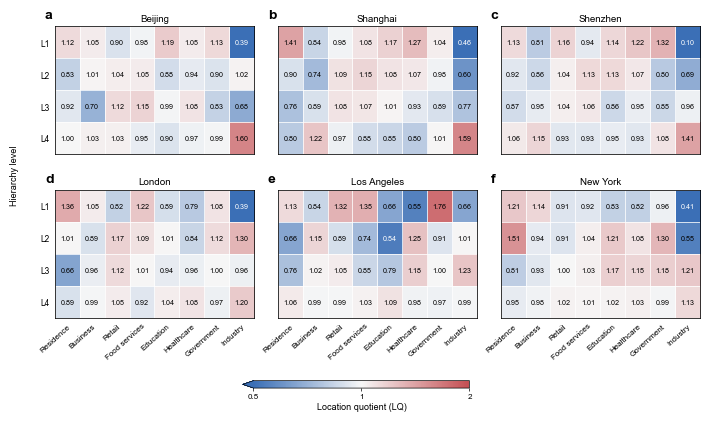

In [131]:
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm


BASE_DIR = Path("results/hierarchy_identification_results")
OUTPUT_PATH = Path(
    "results/figures/Extended_Data_Fig1_functional_specialization.jpg"
)

CITY_CONFIGS = [
    ("Beijing", "beijing"),
    ("Shanghai", "shanghai"),
    ("Shenzhen", "shenzhen"),
    ("London", "london"),
    ("Los Angeles", "losangeles"),
    ("New York", "newyork"),
]

POI_COLUMNS = ["res", "com", "ret", "foo", "edu", "hea", "gov", "ind"]
POI_LABELS = [
    "Residence",
    "Business",
    "Retail",
    "Food services",
    "Education",
    "Healthcare",
    "Government",
    "Industry",
]
LEVELS = [1, 2, 3, 4]

ROBUST_QUANTILE = 0.95
MIN_LOG2_LIMIT = 1.0

mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 6.5,
        "axes.linewidth": 0.55,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


def read_city_lq(prefix):
    path = BASE_DIR / f"{prefix}_hierarchy_poi.shp"
    if not path.exists():
        raise FileNotFoundError(f"Required shapefile not found: {path}")

    data = gpd.read_file(path, ignore_geometry=True)
    required = {"level", *POI_COLUMNS}
    missing = required.difference(data.columns)
    if missing:
        raise ValueError(f"{path} is missing fields: {sorted(missing)}")

    data = data.loc[:, ["level", *POI_COLUMNS]].copy()
    data["level"] = pd.to_numeric(data["level"], errors="coerce")
    data[POI_COLUMNS] = data[POI_COLUMNS].apply(pd.to_numeric, errors="coerce")

    if data[["level", *POI_COLUMNS]].isna().any().any():
        raise ValueError(f"{path} contains missing or non-numeric values.")
    if not data["level"].isin(LEVELS).all():
        raise ValueError(f"Hierarchy levels must be 1, 2, 3, or 4: {path}")
    if (data[POI_COLUMNS] < 0).any().any():
        raise ValueError(f"POI counts cannot be negative: {path}")

    data["level"] = data["level"].astype(int)
    counts = data.groupby("level")[POI_COLUMNS].sum().reindex(LEVELS)
    if counts.isna().any().any():
        missing_levels = counts.index[counts.isna().all(axis=1)].tolist()
        raise ValueError(f"Missing hierarchy levels in {path}: {missing_levels}")

    level_totals = counts.sum(axis=1)
    city_category_totals = counts.sum(axis=0)
    if (level_totals <= 0).any():
        invalid_levels = level_totals.index[level_totals <= 0].tolist()
        raise ValueError(f"Levels without POIs in {path}: {invalid_levels}")
    if (city_category_totals <= 0).any():
        invalid_categories = city_category_totals.index[
            city_category_totals <= 0
        ].tolist()
        raise ValueError(f"POI categories absent citywide in {path}: {invalid_categories}")

    level_composition = counts.div(level_totals, axis=0)
    city_composition = city_category_totals / city_category_totals.sum()
    return level_composition.div(city_composition, axis=1)


def get_shared_colour_scale(lq_matrices):
    raw_values = np.concatenate(
        [matrix.to_numpy(dtype=float).ravel() for matrix in lq_matrices.values()]
    )
    positive_values = raw_values[np.isfinite(raw_values) & (raw_values > 0)]
    if positive_values.size == 0:
        raise ValueError("No positive LQ values are available for plotting.")

    log2_values = np.log2(positive_values)
    limit = max(
        MIN_LOG2_LIMIT,
        float(np.quantile(np.abs(log2_values), ROBUST_QUANTILE)),
    )
    lower_clipped = np.any(raw_values == 0) or np.any(log2_values < -limit)
    upper_clipped = np.any(log2_values > limit)
    if lower_clipped and upper_clipped:
        extend = "both"
    elif lower_clipped:
        extend = "min"
    elif upper_clipped:
        extend = "max"
    else:
        extend = "neither"

    return limit, extend


def format_lq(value):
    if np.isclose(value, round(value)):
        return str(int(round(value)))
    if value < 1:
        return f"{value:.2f}".rstrip("0").rstrip(".")
    return f"{value:.1f}".rstrip("0").rstrip(".")


def create_figure(lq_matrices):
    limit, extend = get_shared_colour_scale(lq_matrices)
    norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)
    cmap = LinearSegmentedColormap.from_list(
        "lq_diverging",
        ["#3B6FB6", "#F7F7F7", "#C44E52"],
    )
    cmap.set_bad("#D9D9D9")

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(18.0 / 2.54, 10.5 / 2.54),
        sharex=True,
        sharey=True,
    )

    image = None
    for panel_index, (ax, (city_name, prefix)) in enumerate(
        zip(axes.flat, CITY_CONFIGS)
    ):
        raw_values = lq_matrices[prefix].loc[LEVELS, POI_COLUMNS].to_numpy(float)
        plot_values = np.full_like(raw_values, np.nan, dtype=float)
        positive = np.isfinite(raw_values) & (raw_values > 0)
        plot_values[positive] = np.log2(raw_values[positive])
        plot_values[raw_values == 0] = -limit
        plot_values = np.clip(plot_values, -limit, limit)

        image = ax.imshow(
            np.ma.masked_invalid(plot_values),
            cmap=cmap,
            norm=norm,
            aspect="auto",
            interpolation="nearest",
        )

        ax.set_title(city_name, fontsize=7.0, pad=4)
        ax.text(
            -0.05,
            1.04,
            chr(97 + panel_index),
            transform=ax.transAxes,
            fontsize=10,
            fontweight="bold",
            ha="left",
            va="bottom",
            clip_on=False,
        )

        ax.set_xticks(np.arange(len(POI_COLUMNS)))
        ax.set_yticks(np.arange(len(LEVELS)))
        ax.set_yticklabels([f"L{level}" for level in LEVELS], fontsize=6.0)
        ax.tick_params(axis="both", which="major", length=0)

        if panel_index >= 3:
            ax.set_xticklabels(
                POI_LABELS,
                rotation=42,
                ha="right",
                rotation_mode="anchor",
                fontsize=5.8,
            )
        else:
            ax.tick_params(axis="x", labelbottom=False)
        if panel_index % 3 != 0:
            ax.tick_params(axis="y", labelleft=False)

        ax.set_xticks(np.arange(-0.5, len(POI_COLUMNS), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(LEVELS), 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=0.55)
        ax.tick_params(which="minor", bottom=False, left=False)

        for row in range(raw_values.shape[0]):
            for column in range(raw_values.shape[1]):
                value = raw_values[row, column]
                if not np.isfinite(value):
                    label = "NA"
                    text_color = "#555555"
                else:
                    label = "0" if value == 0 else f"{value:.2f}"
                    red, green, blue, _ = cmap(norm(plot_values[row, column]))
                    luminance = 0.2126 * red + 0.7152 * green + 0.0722 * blue
                    text_color = "white" if luminance < 0.48 else "black"

                ax.text(
                    column,
                    row,
                    label,
                    ha="center",
                    va="center",
                    fontsize=5.2,
                    color=text_color,
                )

    exponent_ticks = np.arange(np.ceil(-limit), np.floor(limit) + 1)
    tick_labels = [format_lq(2**tick) for tick in exponent_ticks]
    colorbar_axis = fig.add_axes([0.34, 0.065, 0.32, 0.018])
    colorbar = fig.colorbar(
        image,
        cax=colorbar_axis,
        orientation="horizontal",
        extend=extend,
    )
    colorbar.set_ticks(exponent_ticks)
    colorbar.set_ticklabels(tick_labels)
    colorbar.set_label("Location quotient (LQ)", fontsize=6.5, labelpad=2)
    colorbar.ax.tick_params(labelsize=5.8, length=2.2, width=0.5, pad=1.5)
    colorbar.outline.set_linewidth(0.5)

    fig.text(
        0.018,
        0.58,
        "Hierarchy level",
        rotation=90,
        ha="center",
        va="center",
        fontsize=6.5,
    )
    fig.subplots_adjust(
        left=0.075,
        right=0.985,
        bottom=0.235,
        top=0.94,
        wspace=0.12,
        hspace=0.28,
    )
    return fig


def main():
    lq_matrices = {
        prefix: read_city_lq(prefix)
        for _, prefix in CITY_CONFIGS
    }
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    figure = create_figure(lq_matrices)
    figure.savefig(
        OUTPUT_PATH,
        dpi=600,
        format="jpg",
        pil_kwargs={"quality": 100, "subsampling": 0},
    )
    #plt.close(figure)
    print(f"Saved: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

In [ ]:
city = 'newyork'
od = pd.read_csv(f'D:/urban_hierarchy_congestion/data/od_tables/{city}_full_od_time.csv')
unit = gpd.read_file(f'D:/urban_hierarchy_congestion/results/hierarchy_identification_results/{city}_hierarchy.shp')
od = pd.merge(pd.merge(od,unit[['id','level']],left_on='o_id',right_on='id'),unit[['id','level']],left_on='d_id',right_on='id')
od.rename(columns={'level_x':'o_level','level_y':'d_level'},inplace=True)
od.drop(columns={'id_x','id_y'},inplace=True)
od.loc[((od['o_level']-od['d_level'])>1),'type'] = 'skip-level upward'
od.loc[((od['o_level']-od['d_level'])==1),'type'] = 'adjacent-level upward'
od.loc[((od['o_level']-od['d_level'])<=0),'type'] = 'non-upward'
od['flow_rdist'] = od['flow']*od['rdist']
g = od.groupby('type',as_index=False)[['flow','flow_rdist']].sum()
g['flow_share'] = g['flow']/g['flow'].sum()
g['rdist'] = g['flow_rdist']/g['flow']

Saved figure: results\figures\Extended_Data_Fig_1_local_POI_AUC.jpg


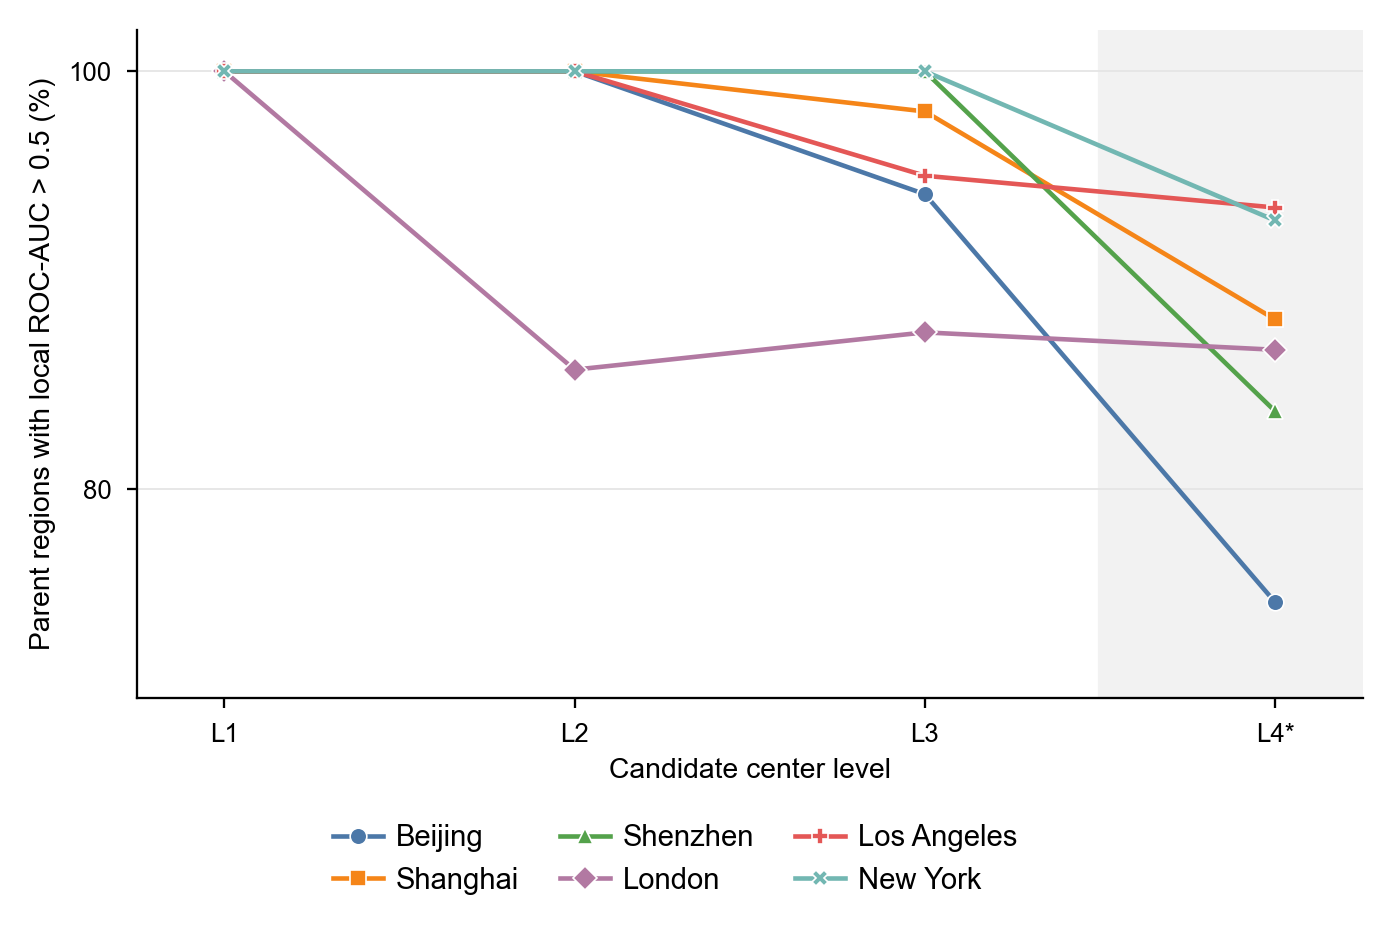

In [166]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MultipleLocator


SUMMARY_DIR = Path("results/summary_tables")
OUTPUT_PATH = Path("results/figures/Extended_Data_Fig_1_local_POI_AUC.jpg")

CITY_CONFIGS = [
    ("Beijing", "beijing", "#4C78A8", "o"),
    ("Shanghai", "shanghai", "#F58518", "s"),
    ("Shenzhen", "shenzhen", "#54A24B", "^"),
    ("London", "london", "#B279A2", "D"),
    ("Los Angeles", "losangeles", "#E45756", "P"),
    ("New York", "newyork", "#72B7B2", "X"),
]

CENTER_LEVELS = [1, 2, 3, 4]
CENTER_LABELS = ["L1", "L2", "L3", "L4*"]

FIGURE_WIDTH_CM = 12.0
FIGURE_HEIGHT_CM = 8.2
AXIS_LABEL_SIZE = 6.8
TICK_LABEL_SIZE = 6.2
LEGEND_SIZE = 7.0


mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 6.5,
        "axes.linewidth": 0.55,
        "xtick.major.width": 0.55,
        "ytick.major.width": 0.55,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


def find_column(df: pd.DataFrame, candidates: list[str], path: Path) -> str:
    for column in candidates:
        if column in df.columns:
            return column
    raise ValueError(f"{path} is missing one of the required columns: {candidates}")


def normalize_level(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.upper().str.extract(r"(\d+)", expand=False),
        errors="coerce",
    )


def read_city_summary(prefix: str) -> pd.DataFrame:
    path = SUMMARY_DIR / f"{prefix}_local_poi_auc_by_parent_region.csv"
    if not path.exists():
        raise FileNotFoundError(f"Required local-AUC file not found: {path}")

    df = pd.read_csv(path)
    level_column = find_column(df, ["center_level", "level"], path)
    auc_column = find_column(df, ["local_auc", "poi_auc", "auc"], path)

    data = df.loc[:, [level_column, auc_column]].copy()
    data.columns = ["center_level", "local_auc"]
    data["center_level"] = normalize_level(data["center_level"])
    data["local_auc"] = pd.to_numeric(data["local_auc"], errors="coerce")
    data = data.dropna()
    data = data.loc[data["center_level"].isin(CENTER_LEVELS)]

    if data.empty:
        raise ValueError(f"No valid local-AUC values were found in {path}.")
    if not data["local_auc"].between(0, 1).all():
        raise ValueError(f"Local AUC must range from 0 to 1: {path}")

    summary = (
        data.groupby("center_level", as_index=False)
        .agg(
            share_auc_above_05=("local_auc", lambda values: 100 * (values > 0.5).mean()),
        )
        .set_index("center_level")
        .reindex(CENTER_LEVELS)
        .reset_index()
    )
    return summary


def style_axis(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", direction="out", labelsize=TICK_LABEL_SIZE)
    ax.grid(axis="y", color="#E6E6E6", linewidth=0.45, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlim(0.75, 4.25)
    ax.set_xticks(CENTER_LEVELS, CENTER_LABELS)
    ax.axvspan(3.5, 4.25, color="#F2F2F2", zorder=-1)


def create_figure() -> plt.Figure:
    summaries = {
        prefix: read_city_summary(prefix)
        for _, prefix, _, _ in CITY_CONFIGS
    }

    figure, ax = plt.subplots(
        figsize=(FIGURE_WIDTH_CM / 2.54, FIGURE_HEIGHT_CM / 2.54),
    )

    for city_name, prefix, color, marker in CITY_CONFIGS:
        data = summaries[prefix]
        ax.plot(
            data["center_level"],
            data["share_auc_above_05"],
            color=color,
            marker=marker,
            linewidth=1.1,
            markersize=4.0,
            markeredgecolor="white",
            markeredgewidth=0.4,
            label=city_name,
            zorder=3,
        )

    style_axis(ax)
    #ax.axhline(50, color="#777777", linestyle=":", linewidth=0.65, zorder=1)
    ax.set_ylim(70, 102)
    ax.yaxis.set_major_locator(MultipleLocator(20))
    ax.set_xlabel("Candidate center level", fontsize=AXIS_LABEL_SIZE, labelpad=2.5)
    ax.set_ylabel(
        "Parent regions with local ROC-AUC > 0.5 (%)",
        fontsize=AXIS_LABEL_SIZE,
        labelpad=3.0,
    )

    handles, labels = ax.get_legend_handles_labels()
    figure.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.05),
        ncol=3,
        frameon=False,
        fontsize=LEGEND_SIZE,
        handlelength=1.7,
        handletextpad=0.45,
        columnspacing=1.4,
    )
    figure.subplots_adjust(left=0.12, right=0.985, top=0.97, bottom=0.28)
    return figure


def main() -> None:
    figure = create_figure()
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        OUTPUT_PATH,
        dpi=600,
        format="jpg",
        bbox_inches="tight",
        pil_kwargs={"quality": 100, "subsampling": 0},
    )
    #plt.close(figure)
    print(f"Saved figure: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

## Extended data fig.2

In [21]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
from scipy.stats import spearmanr, pearsonr
import statsmodels.api as sm

In [19]:
for city in ['beijing','shanghai','shenzhen','london','losangeles','newyork']:
    unit = gpd.read_file(f'D:/urban_hierarchy_congestion/data/taz/{city}_grid_1k.shp')
    drive_edges = gpd.read_file(f"D:/urban_hierarchy_congestion/data/transport_network/spatial_data/{city}/drive_edges.shp")
    drive_edges.to_crs(crs=unit.crs,inplace=True)
    drive_edges["from_to"] = drive_edges["u"]+'-'+drive_edges["v"]
    ta = pd.read_csv(f"D:/urban_hierarchy_congestion/results/traffic_assignment_results/{city}/observed_commuting_traffic_assignment.csv",low_memory=False)
    ta["from_to"] = ta["from"]+'-'+ta["to"]
    drive_edges = pd.merge(drive_edges,ta[["from_to","cost","flow"]],on="from_to")
    drive_edges["TTI"] = drive_edges["cost"]/drive_edges["fft"]
    drive_edges = drive_edges.loc[(drive_edges["highway"]=='motorway')|
                                (drive_edges["highway"]=='motorway_link')|
                                (drive_edges["highway"]=='trunk')|
                                (drive_edges["highway"]=='trunk_link')|
                                (drive_edges["highway"]=='primary')|
                                (drive_edges["highway"]=='primary_link')|
                                (drive_edges["highway"]=='secondary')|
                                (drive_edges["highway"]=='secondary_link')].copy()
    drive_edges = drive_edges.loc[(drive_edges['TTI']>=1)].copy()
    drive_edges.index = range(len(drive_edges))
    drive_edges.loc[(drive_edges['TTI']>=1)&(drive_edges['TTI']<1.5),'status_cd'] = 1
    drive_edges.loc[(drive_edges['TTI']>=1.5)&(drive_edges['TTI']<2),'status_cd'] = 2
    drive_edges.loc[(drive_edges['TTI']>=2)&(drive_edges['TTI']<4),'status_cd'] = 3
    drive_edges.loc[(drive_edges['TTI']>=4),'status_cd'] = 4

    unit_intersect_drive_edges = gpd.overlay(drive_edges,unit[['id','geometry']],keep_geom_type=True)
    unit_intersect_drive_edges['length'] = unit_intersect_drive_edges.geometry.length/1000
    unit_intersect_drive_edges['TTI'] = unit_intersect_drive_edges['TTI']*unit_intersect_drive_edges['length']
    unit_intersect_drive_edges['status_cd'] = unit_intersect_drive_edges['status_cd']*unit_intersect_drive_edges['length']
    unit_congestion = unit_intersect_drive_edges.groupby('id',as_index=False)[['TTI','status_cd','length']].sum()
    unit_congestion['TTI'] = unit_congestion['TTI']/unit_congestion['length']
    unit_congestion['status_cd'] = unit_congestion['status_cd']/unit_congestion['length']
    unit = pd.merge(unit,unit_congestion[['id','TTI','status_cd','length']],on='id',how='inner')
    unit.rename(columns={'TTI':'TTI_sim','status_cd':'status_sim','length':'length_sim'},inplace=True)

    folder = Path(f'E:/commuting_flow_models/otherdata/traffic_status/{city}')
    shp_files = [p.name for p in folder.glob("*.shp")]
    r_best = 0
    shp_file_best = ''
    for shp_file in shp_files:
        observed_ta = gpd.read_file(f'E:/commuting_flow_models/otherdata/traffic_status/{city}/{shp_file}')
        if 'speed_cls' in observed_ta.columns:
            observed_ta['status_cd'] = observed_ta['speed_cls']
        observed_ta.to_crs(crs=unit.crs,inplace=True)
        observed_ta = observed_ta.loc[(observed_ta['status_cd']>0)].copy()
        observed_ta.index = range(len(observed_ta))
        unit_intersect_observed_ta = gpd.overlay(observed_ta,unit[['id','geometry']],keep_geom_type=True)
        unit_intersect_observed_ta['length'] = unit_intersect_observed_ta.geometry.length/1000
        unit_intersect_observed_ta['status_cd'] = unit_intersect_observed_ta['status_cd']*unit_intersect_observed_ta['length']
        unit_congestion = unit_intersect_observed_ta.groupby('id',as_index=False)[['status_cd','length']].sum()
        unit_congestion['status_cd'] = unit_congestion['status_cd']/unit_congestion['length']
        unit2 = pd.merge(unit,unit_congestion[['id','status_cd','length']],on='id',how='inner')
        unit2.rename(columns={'status_cd':'status_obs','length':'length_obs'},inplace=True)
        r = spearmanr(unit2['status_obs'],unit2['TTI_sim'])[0]
        if r_best < r:
            shp_file_best = shp_file
            r_best = r

    print(city,shp_file_best,r_best)

    observed_ta = gpd.read_file(f'E:/commuting_flow_models/otherdata/traffic_status/{city}/{shp_file_best}')
    if 'speed_cls' in observed_ta.columns:
        observed_ta['status_cd'] = observed_ta['speed_cls']
    observed_ta.to_crs(crs=unit.crs,inplace=True)
    observed_ta = observed_ta.loc[(observed_ta['status_cd']>0)].copy()
    observed_ta.index = range(len(observed_ta))

    unit_intersect_observed_ta = gpd.overlay(observed_ta,unit[['id','geometry']],keep_geom_type=True)
    unit_intersect_observed_ta['length'] = unit_intersect_observed_ta.geometry.length/1000
    unit_intersect_observed_ta['status_cd'] = unit_intersect_observed_ta['status_cd']*unit_intersect_observed_ta['length']
    unit_intersect_observed_ta['tti'] = unit_intersect_observed_ta['tti']*unit_intersect_observed_ta['length']
    unit_congestion = unit_intersect_observed_ta.groupby('id',as_index=False)[['status_cd','length']].sum()
    unit_congestion['status_cd'] = unit_congestion['status_cd']/unit_congestion['length']
    unit = pd.merge(unit,unit_congestion[['id','status_cd','length']],on='id',how='inner')
    unit.rename(columns={'status_cd':'status_obs','length':'length_obs'},inplace=True)
    unit.to_file(f'D:/urban_hierarchy_congestion/results/traffic_assignment_results/congestion_map/{city}_grid_1k_congestion.shp')

    boundary = gpd.read_file(f'D:/urban_hierarchy_congestion/data/taz/{city}_boundary.shp')
    drive_edges = drive_edges.clip(boundary)
    observed_ta = observed_ta.clip(boundary)
    drive_edges.to_file(f"D:/urban_hierarchy_congestion/results/traffic_assignment_results/congestion_map/{city}_simulated_road_congestion.shp")
    observed_ta.to_file(f"D:/urban_hierarchy_congestion/data/traffic_status/{city}_observed_road_congestion.shp")

beijing 0520_0850.shp 0.5706018998216963
shanghai 0522_0850.shp 0.46616420941278036
shenzhen 0522_0850.shp 0.45902940351951876
london 0520_0720.shp 0.41714527101764026
losangeles 0519_0710.shp 0.3730354785890695
newyork 0519_0700.shp 0.4396825113587232


In [29]:
for city in ['beijing','shanghai','shenzhen','london','losangeles','newyork']:
    unit = gpd.read_file(f'D:/urban_hierarchy_congestion/data/taz/{city}_grid_1k.shp')
    drive_edges = gpd.read_file(f"D:/urban_hierarchy_congestion/data/transport_network/spatial_data/{city}/drive_edges.shp")
    drive_edges.to_crs(crs=unit.crs,inplace=True)
    drive_edges["from_to"] = drive_edges["u"]+'-'+drive_edges["v"]
    ta = pd.read_csv(f"D:/urban_hierarchy_congestion/results/traffic_assignment_results/{city}/observed_commuting_traffic_assignment.csv",low_memory=False)
    ta["from_to"] = ta["from"]+'-'+ta["to"]
    drive_edges = pd.merge(drive_edges,ta[["from_to","cost","flow"]],on="from_to")
    drive_edges["TTI"] = drive_edges["cost"]/drive_edges["fft"]
    drive_edges = drive_edges.loc[(drive_edges["highway"]=='motorway')|
                                (drive_edges["highway"]=='motorway_link')|
                                (drive_edges["highway"]=='trunk')|
                                (drive_edges["highway"]=='trunk_link')|
                                (drive_edges["highway"]=='primary')|
                                (drive_edges["highway"]=='primary_link')|
                                (drive_edges["highway"]=='secondary')|
                                (drive_edges["highway"]=='secondary_link')].copy()
    drive_edges = drive_edges.loc[(drive_edges['TTI']>=1)].copy()
    drive_edges.index = range(len(drive_edges))
    drive_edges.loc[(drive_edges['TTI']>=1)&(drive_edges['TTI']<1.5),'status_cd'] = 1
    drive_edges.loc[(drive_edges['TTI']>=1.5)&(drive_edges['TTI']<2),'status_cd'] = 2
    drive_edges.loc[(drive_edges['TTI']>=2)&(drive_edges['TTI']<4),'status_cd'] = 3
    drive_edges.loc[(drive_edges['TTI']>=4),'status_cd'] = 4

    unit_intersect_drive_edges = gpd.overlay(drive_edges,unit[['id','geometry']],keep_geom_type=True)
    unit_intersect_drive_edges['length'] = unit_intersect_drive_edges.geometry.length/1000
    unit_intersect_drive_edges['TTI'] = unit_intersect_drive_edges['TTI']*unit_intersect_drive_edges['length']
    unit_intersect_drive_edges['status_cd'] = unit_intersect_drive_edges['status_cd']*unit_intersect_drive_edges['length']
    unit_congestion = unit_intersect_drive_edges.groupby('id',as_index=False)[['TTI','status_cd','length']].sum()
    unit_congestion['TTI'] = unit_congestion['TTI']/unit_congestion['length']
    unit_congestion['status_cd'] = unit_congestion['status_cd']/unit_congestion['length']
    unit = pd.merge(unit,unit_congestion[['id','TTI','status_cd','length']],on='id',how='inner')
    unit.rename(columns={'TTI':'TTI_sim','status_cd':'status_sim','length':'length_sim'},inplace=True)

    folder = Path(f'E:/commuting_flow_models/otherdata/traffic_status/{city}')
    shp_files = [p.name for p in folder.glob("*.shp")]
    r2_best = 0
    shp_file_best = ''
    for shp_file in shp_files:
        observed_ta = gpd.read_file(f'E:/commuting_flow_models/otherdata/traffic_status/{city}/{shp_file}')
        if 'speed_cls' in observed_ta.columns:
            observed_ta['status_cd'] = observed_ta['speed_cls']
        observed_ta.to_crs(crs=unit.crs,inplace=True)
        observed_ta = observed_ta.loc[(observed_ta['status_cd']>0)].copy()
        observed_ta.index = range(len(observed_ta))
        unit_intersect_observed_ta = gpd.overlay(observed_ta,unit[['id','geometry']],keep_geom_type=True)
        unit_intersect_observed_ta['length'] = unit_intersect_observed_ta.geometry.length/1000
        unit_intersect_observed_ta['status_cd'] = unit_intersect_observed_ta['status_cd']*unit_intersect_observed_ta['length']
        unit_congestion = unit_intersect_observed_ta.groupby('id',as_index=False)[['status_cd','length']].sum()
        unit_congestion['status_cd'] = unit_congestion['status_cd']/unit_congestion['length']
        unit2 = pd.merge(unit,unit_congestion[['id','status_cd','length']],on='id',how='inner')
        unit2.rename(columns={'status_cd':'status_obs','length':'length_obs'},inplace=True)
        X = unit2.loc[:,['TTI_sim']]
        X = sm.add_constant(X)
        y = unit2.loc[:,'status_obs']
        results = sm.OLS(y,X).fit()
        r2 = results.rsquared
        if r2_best < r2:
            shp_file_best = shp_file
            r2_best = r2

    print(city,shp_file_best,r2_best)

beijing 0520_0730.shp 0.1632586307641054
shanghai 0522_0850.shp 0.11112296830386503
shenzhen 0522_0850.shp 0.2067980340685397
london 0520_0720.shp 0.03429177162281838
losangeles 0519_0710.shp 0.058806426069547446
newyork 0519_0700.shp 0.06388259722179401


In [36]:
city = 'newyork'
unit = gpd.read_file(f'D:/urban_hierarchy_congestion/results/traffic_assignment_results/congestion_map/{city}_grid_1k_congestion.shp')
spearmanr(unit['status_obs'],unit['TTI_sim'])

SignificanceResult(statistic=0.43968362701897146, pvalue=8.666178095470227e-198)

In [27]:
city = 'shenzhen'
unit = gpd.read_file(f'D:/urban_hierarchy_congestion/results/traffic_assignment_results/congestion_map/{city}_grid_1k_congestion.shp')
X = unit.loc[:,['TTI_sim']]
X = sm.add_constant(X)
y = unit.loc[:,'status_obs']
results = sm.OLS(y,X).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:             status_obs   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.206
Method:                 Least Squares   F-statistic:                     269.6
Date:                Tue, 11 Aug 2026   Prob (F-statistic):           5.21e-54
Time:                        18:51:11   Log-Likelihood:                 268.36
No. Observations:                1036   AIC:                            -532.7
Df Residuals:                    1034   BIC:                            -522.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4442      0.093     -4.769      0.0

In [28]:
results.rsquared

0.2067980340685397

## Extended data fig.3

Saved figure: results\figures\Extended_Data_Fig3_flow_experiments.jpg


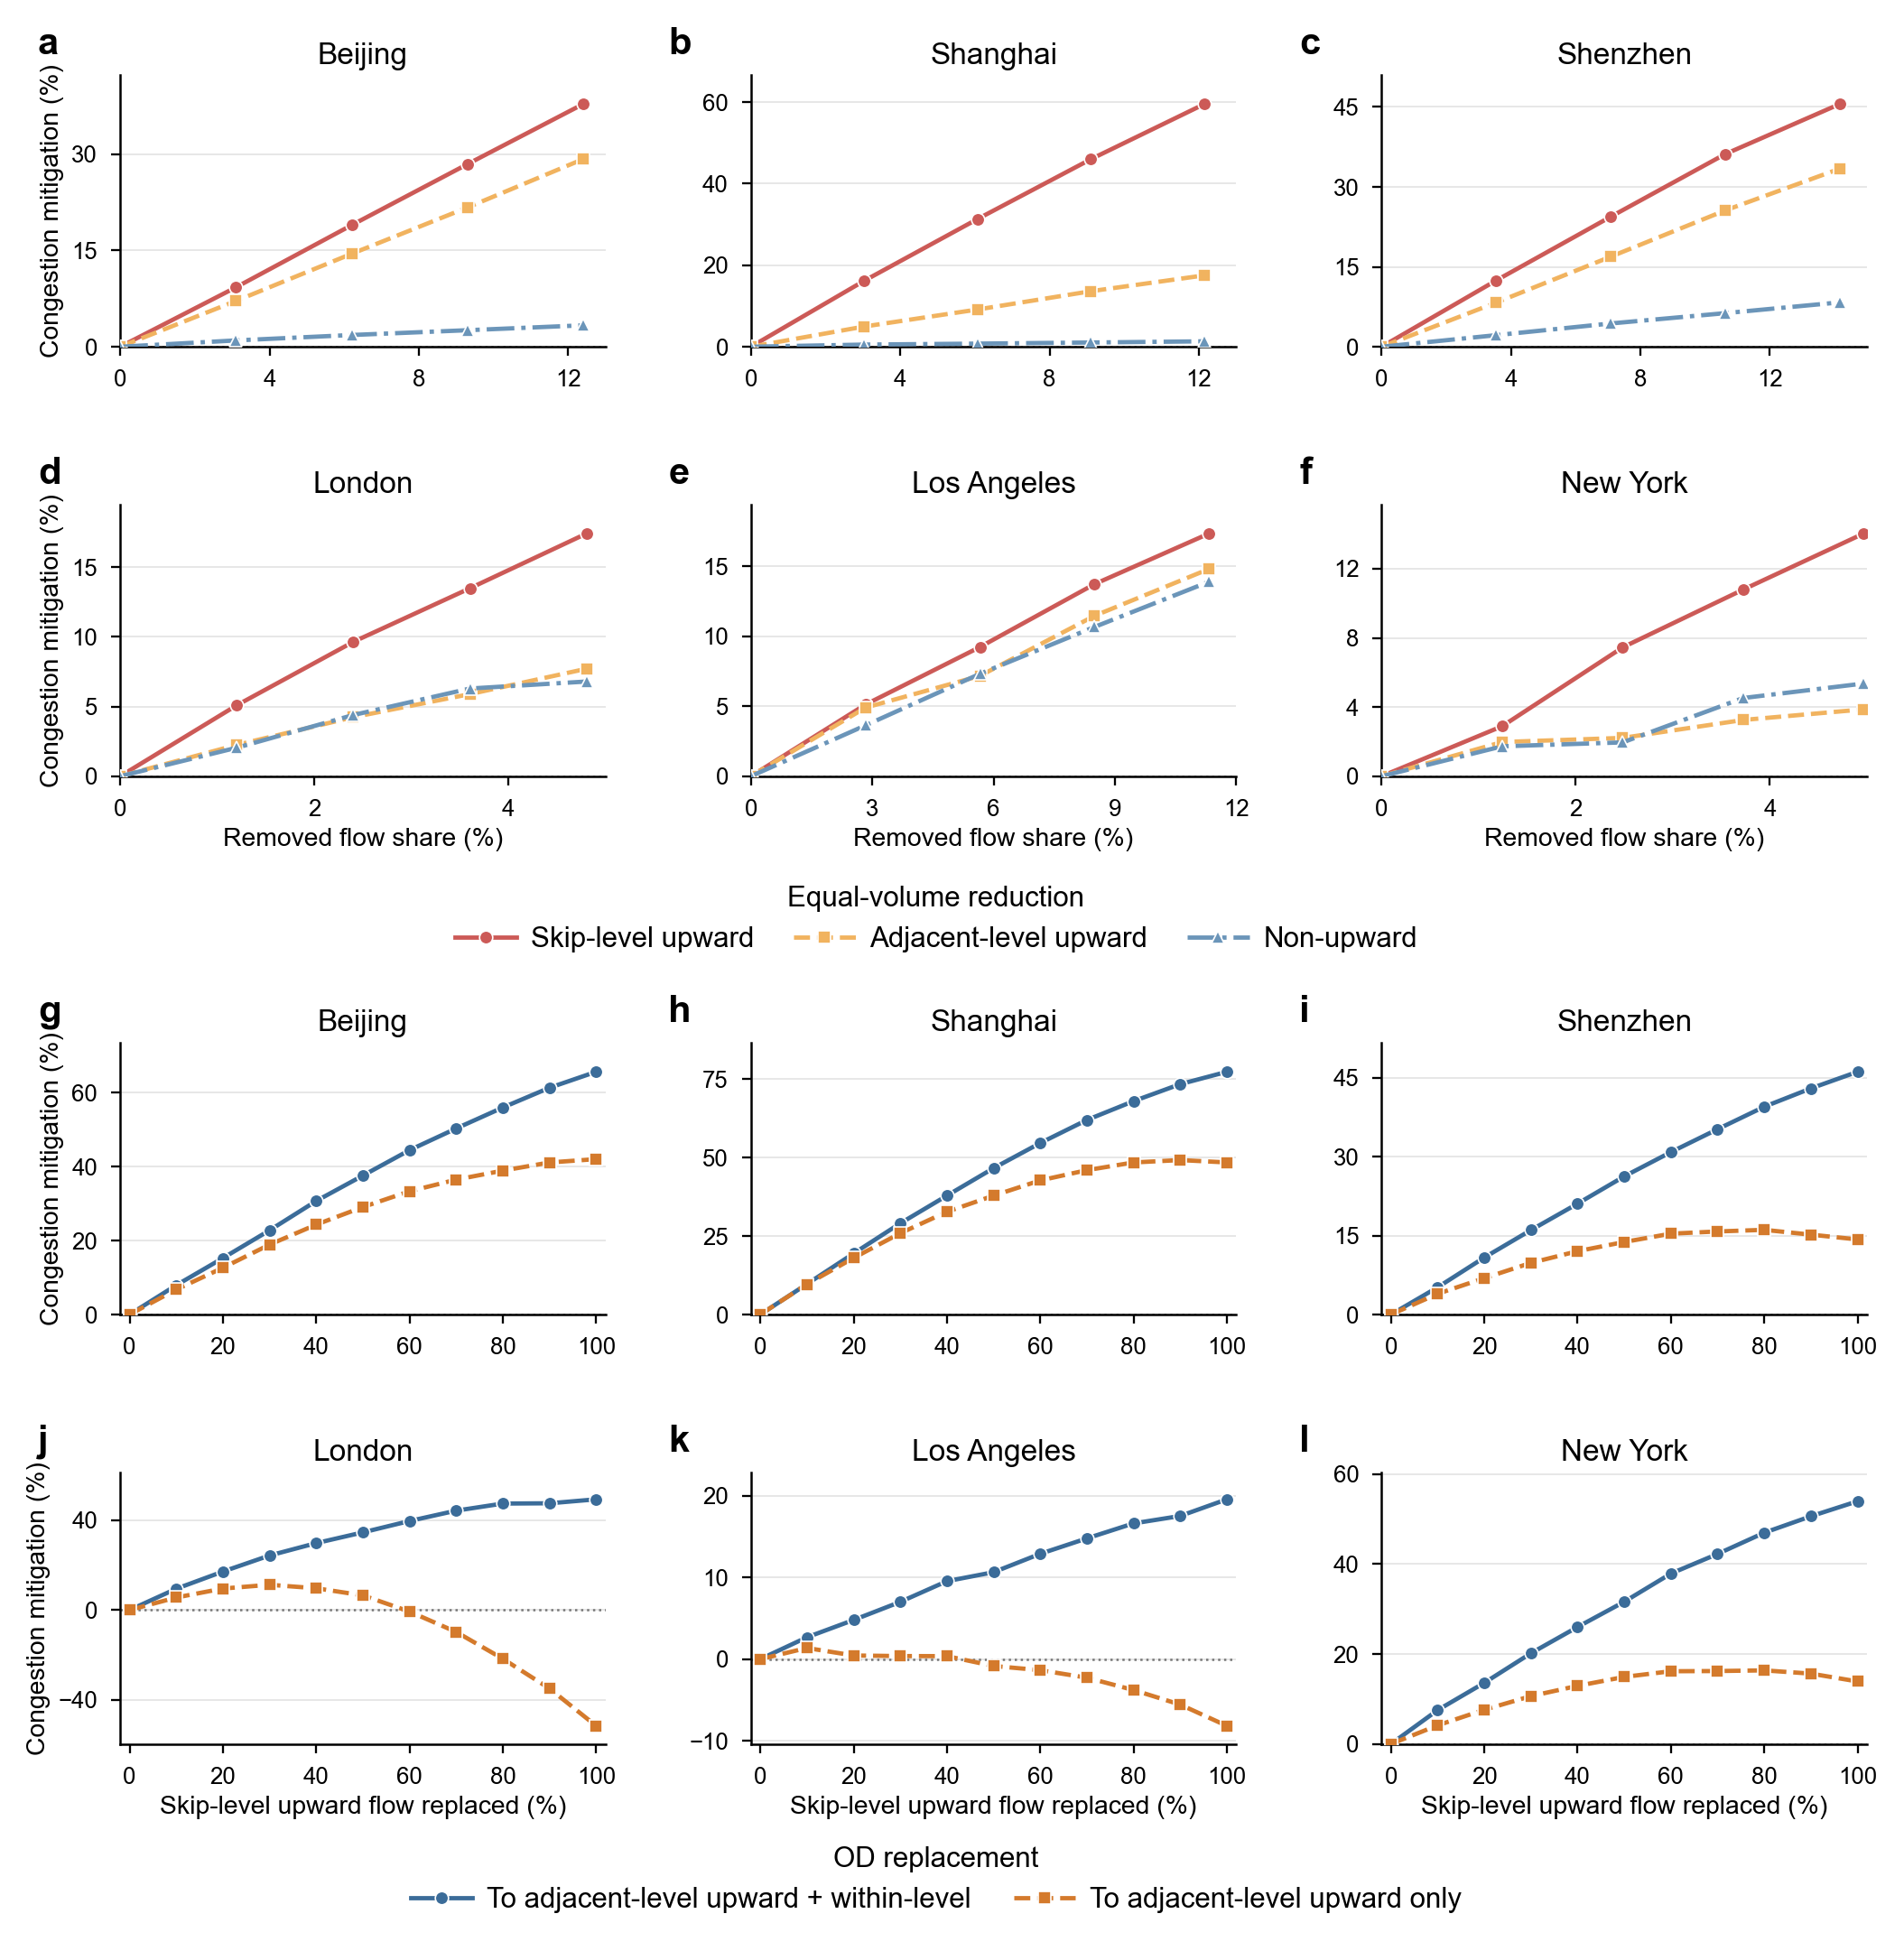

In [137]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, MaxNLocator, StrMethodFormatter


RESULTS_DIR = Path("results/traffic_assignment_results")
OUTPUT_PATH = Path("results/figures/Extended_Data_Fig3_flow_experiments.jpg")

CITY_CONFIGS = [
    ("Beijing", "beijing"),
    ("Shanghai", "shanghai"),
    ("Shenzhen", "shenzhen"),
    ("London", "london"),
    ("Los Angeles", "losangeles"),
    ("New York", "newyork"),
]

EQUAL_VOLUME_FILE = "equal_flow_upward_commuting_results.csv"
EQUAL_GROUP_ORDER = ["skip_level_upward", "adjacent_level_upward", "non_upward"]
EQUAL_GROUP_STYLES = {
    "skip_level_upward": {
        "label": "Skip-level upward",
        "color": "#CC5A57",
        "linestyle": "-",
        "marker": "o",
    },
    "adjacent_level_upward": {
        "label": "Adjacent-level upward",
        "color": "#F1B35F",
        "linestyle": "--",
        "marker": "s",
    },
    "non_upward": {
        "label": "Non-upward",
        "color": "#6B95B9",
        "linestyle": "-.",
        "marker": "^",
    },
}

REPLACEMENT_STYLES = {
    "adjacent_and_within": {
        "filename": "multi_to_adjacent_and_within_commuting_restructuring_results.csv",
        "label": "To adjacent-level upward + within-level",
        "color": "#3B6C99",
        "linestyle": "-",
        "marker": "o",
    },
    "adjacent_only": {
        "filename": "multi_to_adjacent_commuting_restructuring_results.csv",
        "label": "To adjacent-level upward only",
        "color": "#D47A2C",
        "linestyle": "--",
        "marker": "s",
    },
}

FIGURE_WIDTH_CM = 18.0
FIGURE_HEIGHT_CM = 18.2
PANEL_LABEL_SIZE = 10.0
TITLE_SIZE = 8.0
AXIS_LABEL_SIZE = 6.8
TICK_LABEL_SIZE = 6.2
LEGEND_SIZE = 7.5


mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 6.8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.55,
        "ytick.major.width": 0.55,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


def normalize_group(series: pd.Series) -> pd.Series:
    normalized = (
        series.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[\s-]+", "_", regex=True)
    )
    return normalized.replace(
        {
            "multi_level_upward": "skip_level_upward",
            "cross_level_upward": "skip_level_upward",
        }
    )


def read_equal_volume_results(prefix: str) -> dict[str, pd.DataFrame]:
    path = RESULTS_DIR / prefix / EQUAL_VOLUME_FILE
    if not path.exists():
        raise FileNotFoundError(f"Required input file not found: {path}")

    df = pd.read_csv(path)
    required = {
        "commuting_group",
        "removed_share_total",
        "TTI_excess_reduction_pct",
    }
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    df = df.loc[:, list(required)].copy()
    df["commuting_group"] = normalize_group(df["commuting_group"])
    df["removed_share_total"] = pd.to_numeric(
        df["removed_share_total"], errors="coerce"
    )
    df["TTI_excess_reduction_pct"] = pd.to_numeric(
        df["TTI_excess_reduction_pct"], errors="coerce"
    )
    if df[["removed_share_total", "TTI_excess_reduction_pct"]].isna().any().any():
        raise ValueError(f"{path} contains missing or non-numeric plotting values.")
    if not df["removed_share_total"].between(0, 1).all():
        raise ValueError(f"removed_share_total must be a fraction from 0 to 1: {path}")

    unexpected = sorted(
        set(df["commuting_group"])
        - {"baseline", *EQUAL_GROUP_ORDER}
    )
    if unexpected:
        raise ValueError(f"Unexpected commuting_group values in {path}: {unexpected}")

    baseline = df.loc[
        df["commuting_group"] == "baseline",
        ["removed_share_total", "TTI_excess_reduction_pct"],
    ].drop_duplicates()
    if len(baseline) != 1:
        raise ValueError(f"{path} must contain one consistent baseline point.")

    output = {}
    for group in EQUAL_GROUP_ORDER:
        data = df.loc[
            df["commuting_group"] == group,
            ["removed_share_total", "TTI_excess_reduction_pct"],
        ].copy()
        if data.empty:
            raise ValueError(f"Missing commuting group '{group}' in {path}.")
        if not np.isclose(
            data["removed_share_total"].to_numpy(),
            baseline["removed_share_total"].iloc[0],
        ).any():
            data = pd.concat([baseline, data], ignore_index=True)
        data = data.sort_values("removed_share_total").reset_index(drop=True)
        if data["removed_share_total"].duplicated().any():
            raise ValueError(f"Duplicate removed-flow shares for '{group}' in {path}.")
        data["removed_share_pct"] = data["removed_share_total"] * 100.0
        output[group] = data
    return output


def read_replacement_results(prefix: str, filename: str) -> pd.DataFrame:
    path = RESULTS_DIR / prefix / filename
    if not path.exists():
        raise FileNotFoundError(f"Required input file not found: {path}")

    df = pd.read_csv(path)
    required = {"redistribution_share", "TTI_excess_reduction_pct"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    df = df.loc[:, list(required)].copy()
    df["redistribution_share"] = pd.to_numeric(
        df["redistribution_share"], errors="coerce"
    )
    df["TTI_excess_reduction_pct"] = pd.to_numeric(
        df["TTI_excess_reduction_pct"], errors="coerce"
    )
    if df.isna().any().any():
        raise ValueError(f"{path} contains missing or non-numeric plotting values.")
    if df["redistribution_share"].duplicated().any():
        raise ValueError(f"Duplicate redistribution shares in {path}.")

    df = df.sort_values("redistribution_share").reset_index(drop=True)
    expected_shares = np.linspace(0, 1, 11)
    if len(df) != 11 or not np.allclose(
        df["redistribution_share"].to_numpy(), expected_shares, atol=1e-8
    ):
        raise ValueError(
            f"{path} must contain shares from 0 to 1 at intervals of 0.1."
        )
    df["replacement_share_pct"] = df["redistribution_share"] * 100.0
    return df


def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", direction="out", labelsize=TICK_LABEL_SIZE)
    ax.grid(axis="y", color="#E6E6E6", linewidth=0.45, zorder=0)
    ax.set_axisbelow(True)


def set_city_limits(ax, x_values: np.ndarray, y_values: np.ndarray, fixed_x=False):
    x_max = float(np.nanmax(x_values))
    if fixed_x:
        ax.set_xlim(-2, 102)
        ax.xaxis.set_major_locator(FixedLocator([0, 20, 40, 60, 80, 100]))
    else:
        x_upper = max(1, int(np.ceil(x_max)))
        ax.set_xlim(0, x_upper)
        ax.xaxis.set_major_locator(
            MaxNLocator(nbins=4, integer=True, min_n_ticks=3)
        )
        ax.xaxis.set_major_formatter(StrMethodFormatter("{x:.0f}"))

    y_min = min(0.0, float(np.nanmin(y_values)))
    y_max = max(0.0, float(np.nanmax(y_values)))
    y_span = max(y_max - y_min, 1.0)
    lower = y_min - 0.08 * y_span if y_min < 0 else 0.0
    upper = y_max + 0.12 * y_span
    ax.set_ylim(lower, upper)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, min_n_ticks=3))


def add_panel_label(ax, label: str):
    ax.text(
        -0.17,
        1.05,
        label,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=PANEL_LABEL_SIZE,
        fontweight="bold",
        clip_on=False,
    )


def create_figure():
    equal_results = {
        prefix: read_equal_volume_results(prefix)
        for _, prefix in CITY_CONFIGS
    }
    replacement_results = {
        prefix: {
            key: read_replacement_results(prefix, style["filename"])
            for key, style in REPLACEMENT_STYLES.items()
        }
        for _, prefix in CITY_CONFIGS
    }

    figure = plt.figure(
        figsize=(FIGURE_WIDTH_CM / 2.54, FIGURE_HEIGHT_CM / 2.54),
        facecolor="white",
    )
    outer_grid = GridSpec(
        2,
        1,
        figure=figure,
        left=0.075,
        right=0.985,
        top=0.965,
        bottom=0.105,
        hspace=0.38,
    )
    equal_grid = outer_grid[0].subgridspec(2, 3, hspace=0.58, wspace=0.30)
    replacement_grid = outer_grid[1].subgridspec(2, 3, hspace=0.58, wspace=0.30)

    for index, (city_name, prefix) in enumerate(CITY_CONFIGS):
        row, column = divmod(index, 3)
        ax = figure.add_subplot(equal_grid[row, column])
        city_data = equal_results[prefix]

        for group in EQUAL_GROUP_ORDER:
            data = city_data[group]
            style = EQUAL_GROUP_STYLES[group]
            ax.plot(
                data["removed_share_pct"],
                data["TTI_excess_reduction_pct"],
                color=style["color"],
                linestyle=style["linestyle"],
                linewidth=1.15,
                marker=style["marker"],
                markersize=3.5,
                markerfacecolor=style["color"],
                markeredgecolor="white",
                markeredgewidth=0.4,
                zorder=3,
            )

        x_values = np.concatenate(
            [city_data[group]["removed_share_pct"].to_numpy() for group in EQUAL_GROUP_ORDER]
        )
        y_values = np.concatenate(
            [
                city_data[group]["TTI_excess_reduction_pct"].to_numpy()
                for group in EQUAL_GROUP_ORDER
            ]
        )
        ax.axhline(0, color="#777777", linestyle=":", linewidth=0.6, zorder=1)
        set_city_limits(ax, x_values, y_values)
        ax.set_title(city_name, fontsize=TITLE_SIZE, pad=3.0)
        if row == 1:
            ax.set_xlabel("Removed flow share (%)", fontsize=AXIS_LABEL_SIZE, labelpad=2.0)
        if column == 0:
            ax.set_ylabel("Congestion mitigation (%)", fontsize=AXIS_LABEL_SIZE, labelpad=2.0)
        style_axis(ax)
        add_panel_label(ax, chr(ord("a") + index))

    for index, (city_name, prefix) in enumerate(CITY_CONFIGS):
        row, column = divmod(index, 3)
        ax = figure.add_subplot(replacement_grid[row, column])
        city_data = replacement_results[prefix]

        for key, style in REPLACEMENT_STYLES.items():
            data = city_data[key]
            ax.plot(
                data["replacement_share_pct"],
                data["TTI_excess_reduction_pct"],
                color=style["color"],
                linestyle=style["linestyle"],
                linewidth=1.15,
                marker=style["marker"],
                markersize=3.5,
                markerfacecolor=style["color"],
                markeredgecolor="white",
                markeredgewidth=0.4,
                zorder=3,
            )

        x_values = np.concatenate(
            [data["replacement_share_pct"].to_numpy() for data in city_data.values()]
        )
        y_values = np.concatenate(
            [data["TTI_excess_reduction_pct"].to_numpy() for data in city_data.values()]
        )
        ax.axhline(0, color="#777777", linestyle=":", linewidth=0.6, zorder=1)
        set_city_limits(ax, x_values, y_values, fixed_x=True)
        ax.set_title(city_name, fontsize=TITLE_SIZE, pad=3.0)
        if row == 1:
            ax.set_xlabel(
                "Skip-level upward flow replaced (%)",
                fontsize=AXIS_LABEL_SIZE,
                labelpad=2.0,
            )
        if column == 0:
            ax.set_ylabel("Congestion mitigation (%)", fontsize=AXIS_LABEL_SIZE, labelpad=2.0)
        style_axis(ax)
        add_panel_label(ax, chr(ord("g") + index))

    equal_handles = [
        Line2D(
            [0],
            [0],
            color=EQUAL_GROUP_STYLES[group]["color"],
            linestyle=EQUAL_GROUP_STYLES[group]["linestyle"],
            linewidth=1.15,
            marker=EQUAL_GROUP_STYLES[group]["marker"],
            markersize=3.5,
            markerfacecolor=EQUAL_GROUP_STYLES[group]["color"],
            markeredgecolor="white",
            markeredgewidth=0.4,
            label=EQUAL_GROUP_STYLES[group]["label"],
        )
        for group in EQUAL_GROUP_ORDER
    ]
    replacement_handles = [
        Line2D(
            [0],
            [0],
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=1.15,
            marker=style["marker"],
            markersize=3.5,
            markerfacecolor=style["color"],
            markeredgecolor="white",
            markeredgewidth=0.4,
            label=style["label"],
        )
        for style in REPLACEMENT_STYLES.values()
    ]

    figure.legend(
        handles=equal_handles,
        loc="center",
        bbox_to_anchor=(0.5, 0.530),
        ncol=3,
        frameon=False,
        fontsize=LEGEND_SIZE,
        handlelength=2.2,
        handletextpad=0.5,
        columnspacing=1.4,
        title="Equal-volume reduction",
        title_fontsize=LEGEND_SIZE,
    )
    figure.legend(
        handles=replacement_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.005),
        ncol=2,
        frameon=False,
        fontsize=LEGEND_SIZE,
        handlelength=2.2,
        handletextpad=0.5,
        columnspacing=1.5,
        title="OD replacement",
        title_fontsize=LEGEND_SIZE,
    )
    return figure


def main():
    figure = create_figure()
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        OUTPUT_PATH,
        dpi=600,
        format="jpg",
        facecolor="white",
        pil_kwargs={"quality": 100, "subsampling": 0},
    )
    #plt.close(figure)S
    print(f"Saved figure: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

## Extended data fig.4

In [77]:
city = 'london'
od = pd.read_csv(f'D:/urban_hierarchy_congestion/results/gravity_model_fit/{city}_full_od_gravity_fit.csv')
cpc = 2*np.sum(np.minimum(od['flow'],od['flow_pred']))/(np.sum(od['flow'])+np.sum(od['flow_pred']))
rmse = np.sqrt(np.sum((od['flow']-od['flow_pred'])**2)/len(od))
r = np.corrcoef(np.log1p(od['flow']),np.log1p(od['flow_pred']))[0,1]
print(len(od.loc[(od['flow']>0)]),np.round(od['flow'].sum()),cpc,rmse,r)

342390 2789486.0 0.7070473604737788 4.629225704005281 0.8380444150627001


Reading: D:/urban_hierarchy_congestion/results/gravity_model_fit/beijing_full_od_gravity_fit.csv
Reading: D:/urban_hierarchy_congestion/results/gravity_model_fit/shanghai_full_od_gravity_fit.csv
Reading: D:/urban_hierarchy_congestion/results/gravity_model_fit/shenzhen_full_od_gravity_fit.csv
Reading: D:/urban_hierarchy_congestion/results/gravity_model_fit/london_full_od_gravity_fit.csv
Reading: D:/urban_hierarchy_congestion/results/gravity_model_fit/losangeles_full_od_gravity_fit.csv
Reading: D:/urban_hierarchy_congestion/results/gravity_model_fit/newyork_full_od_gravity_fit.csv


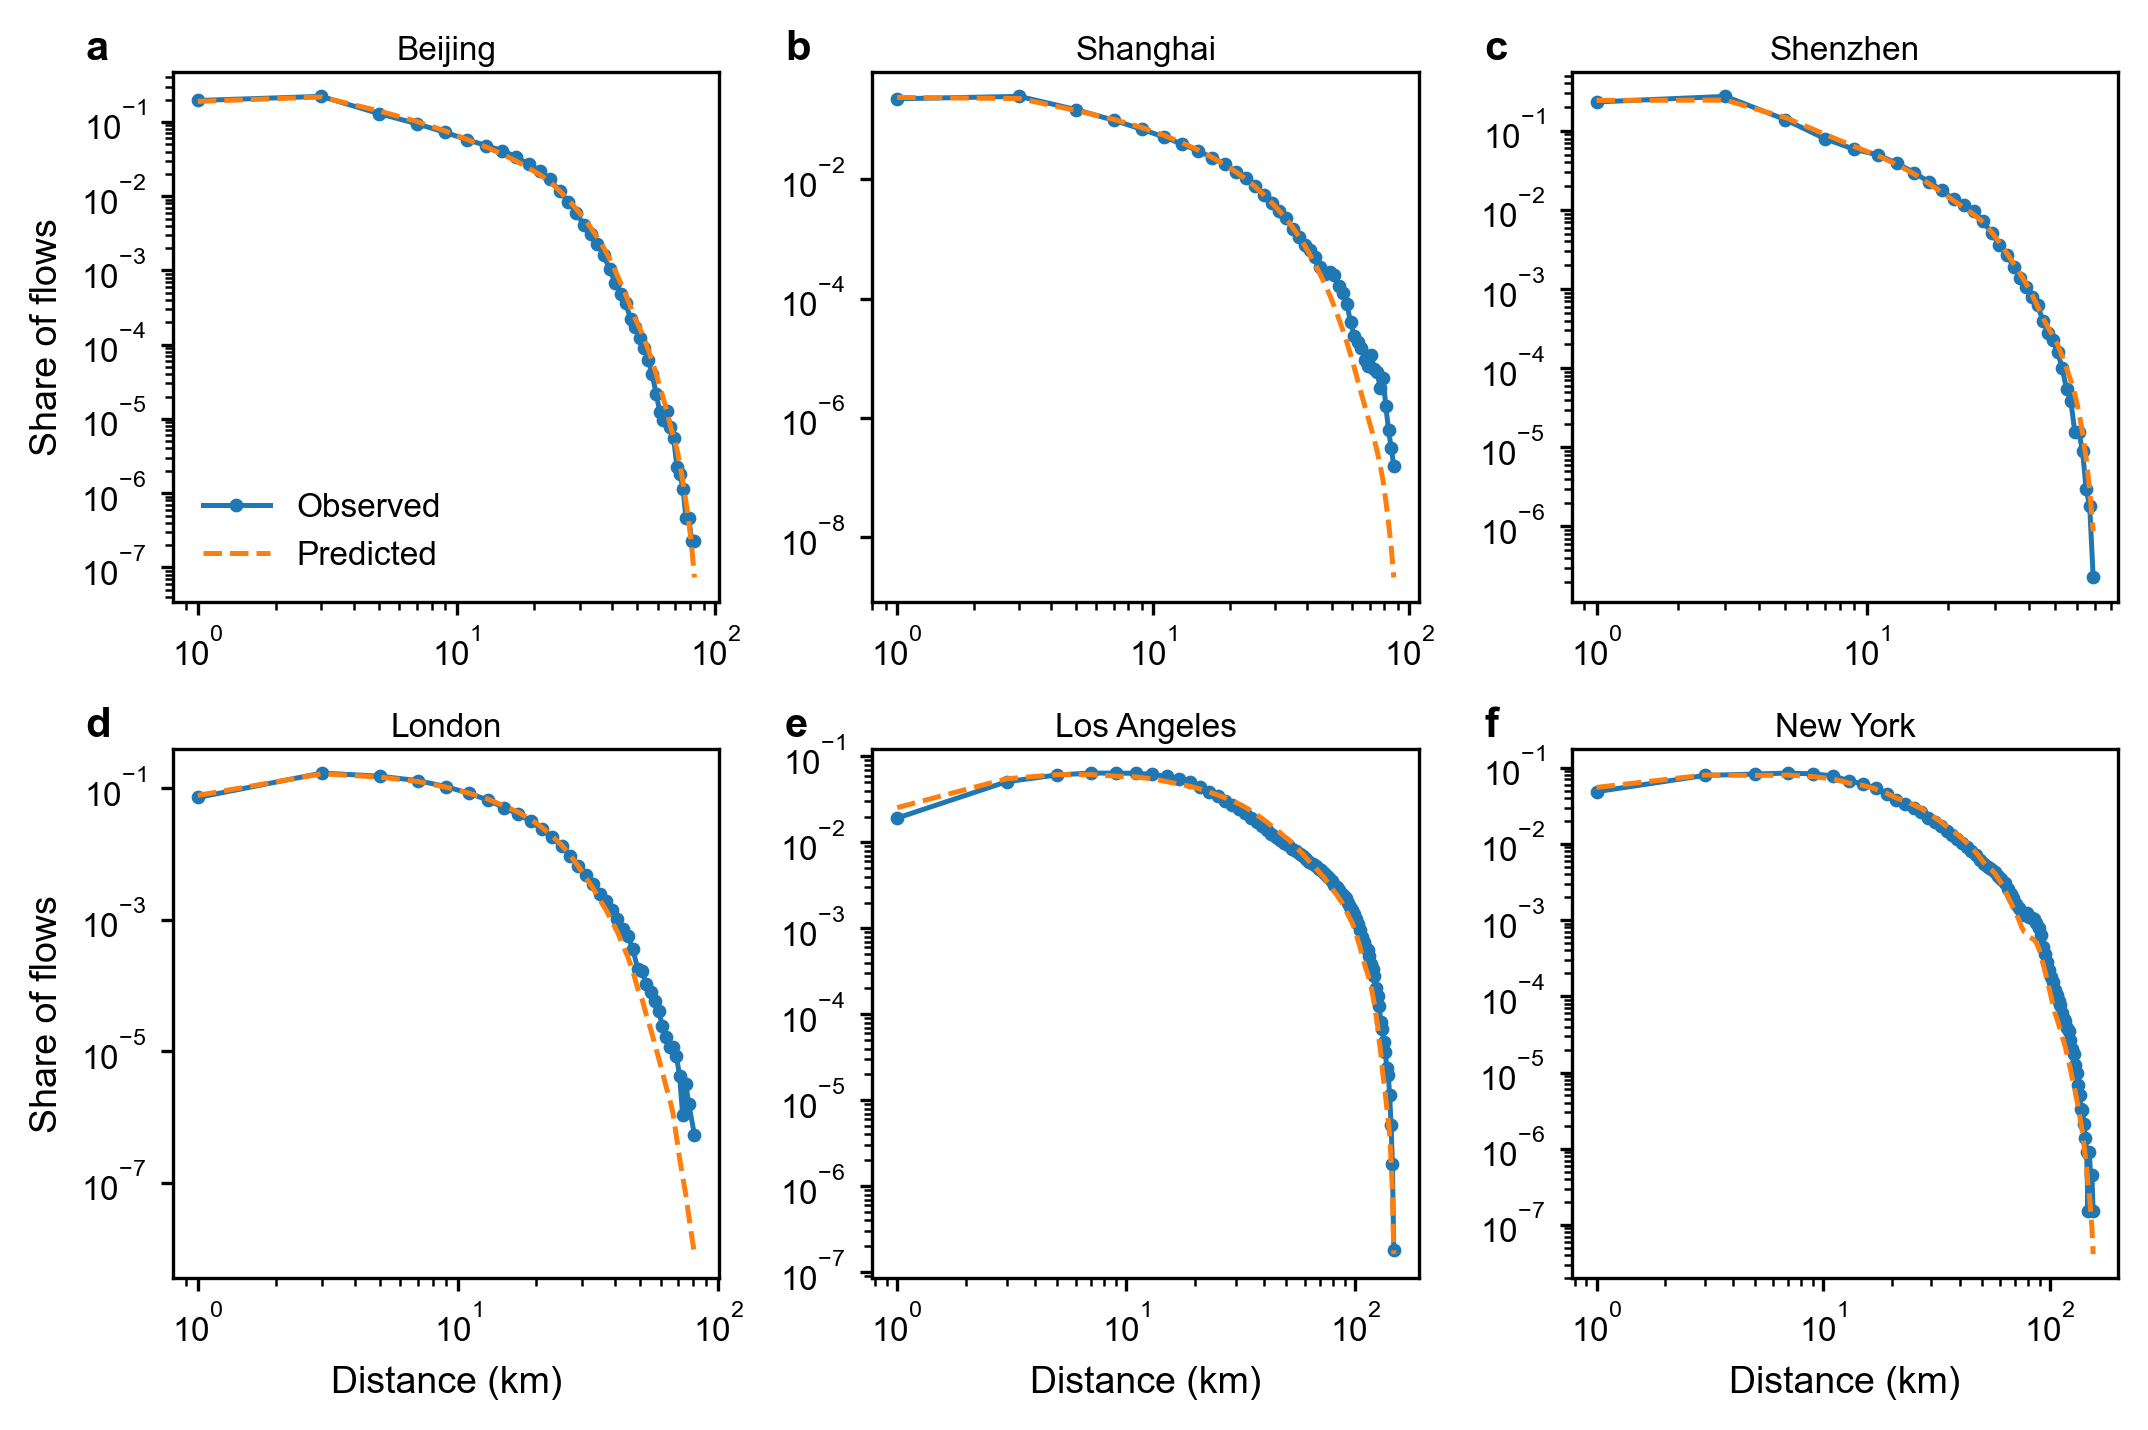

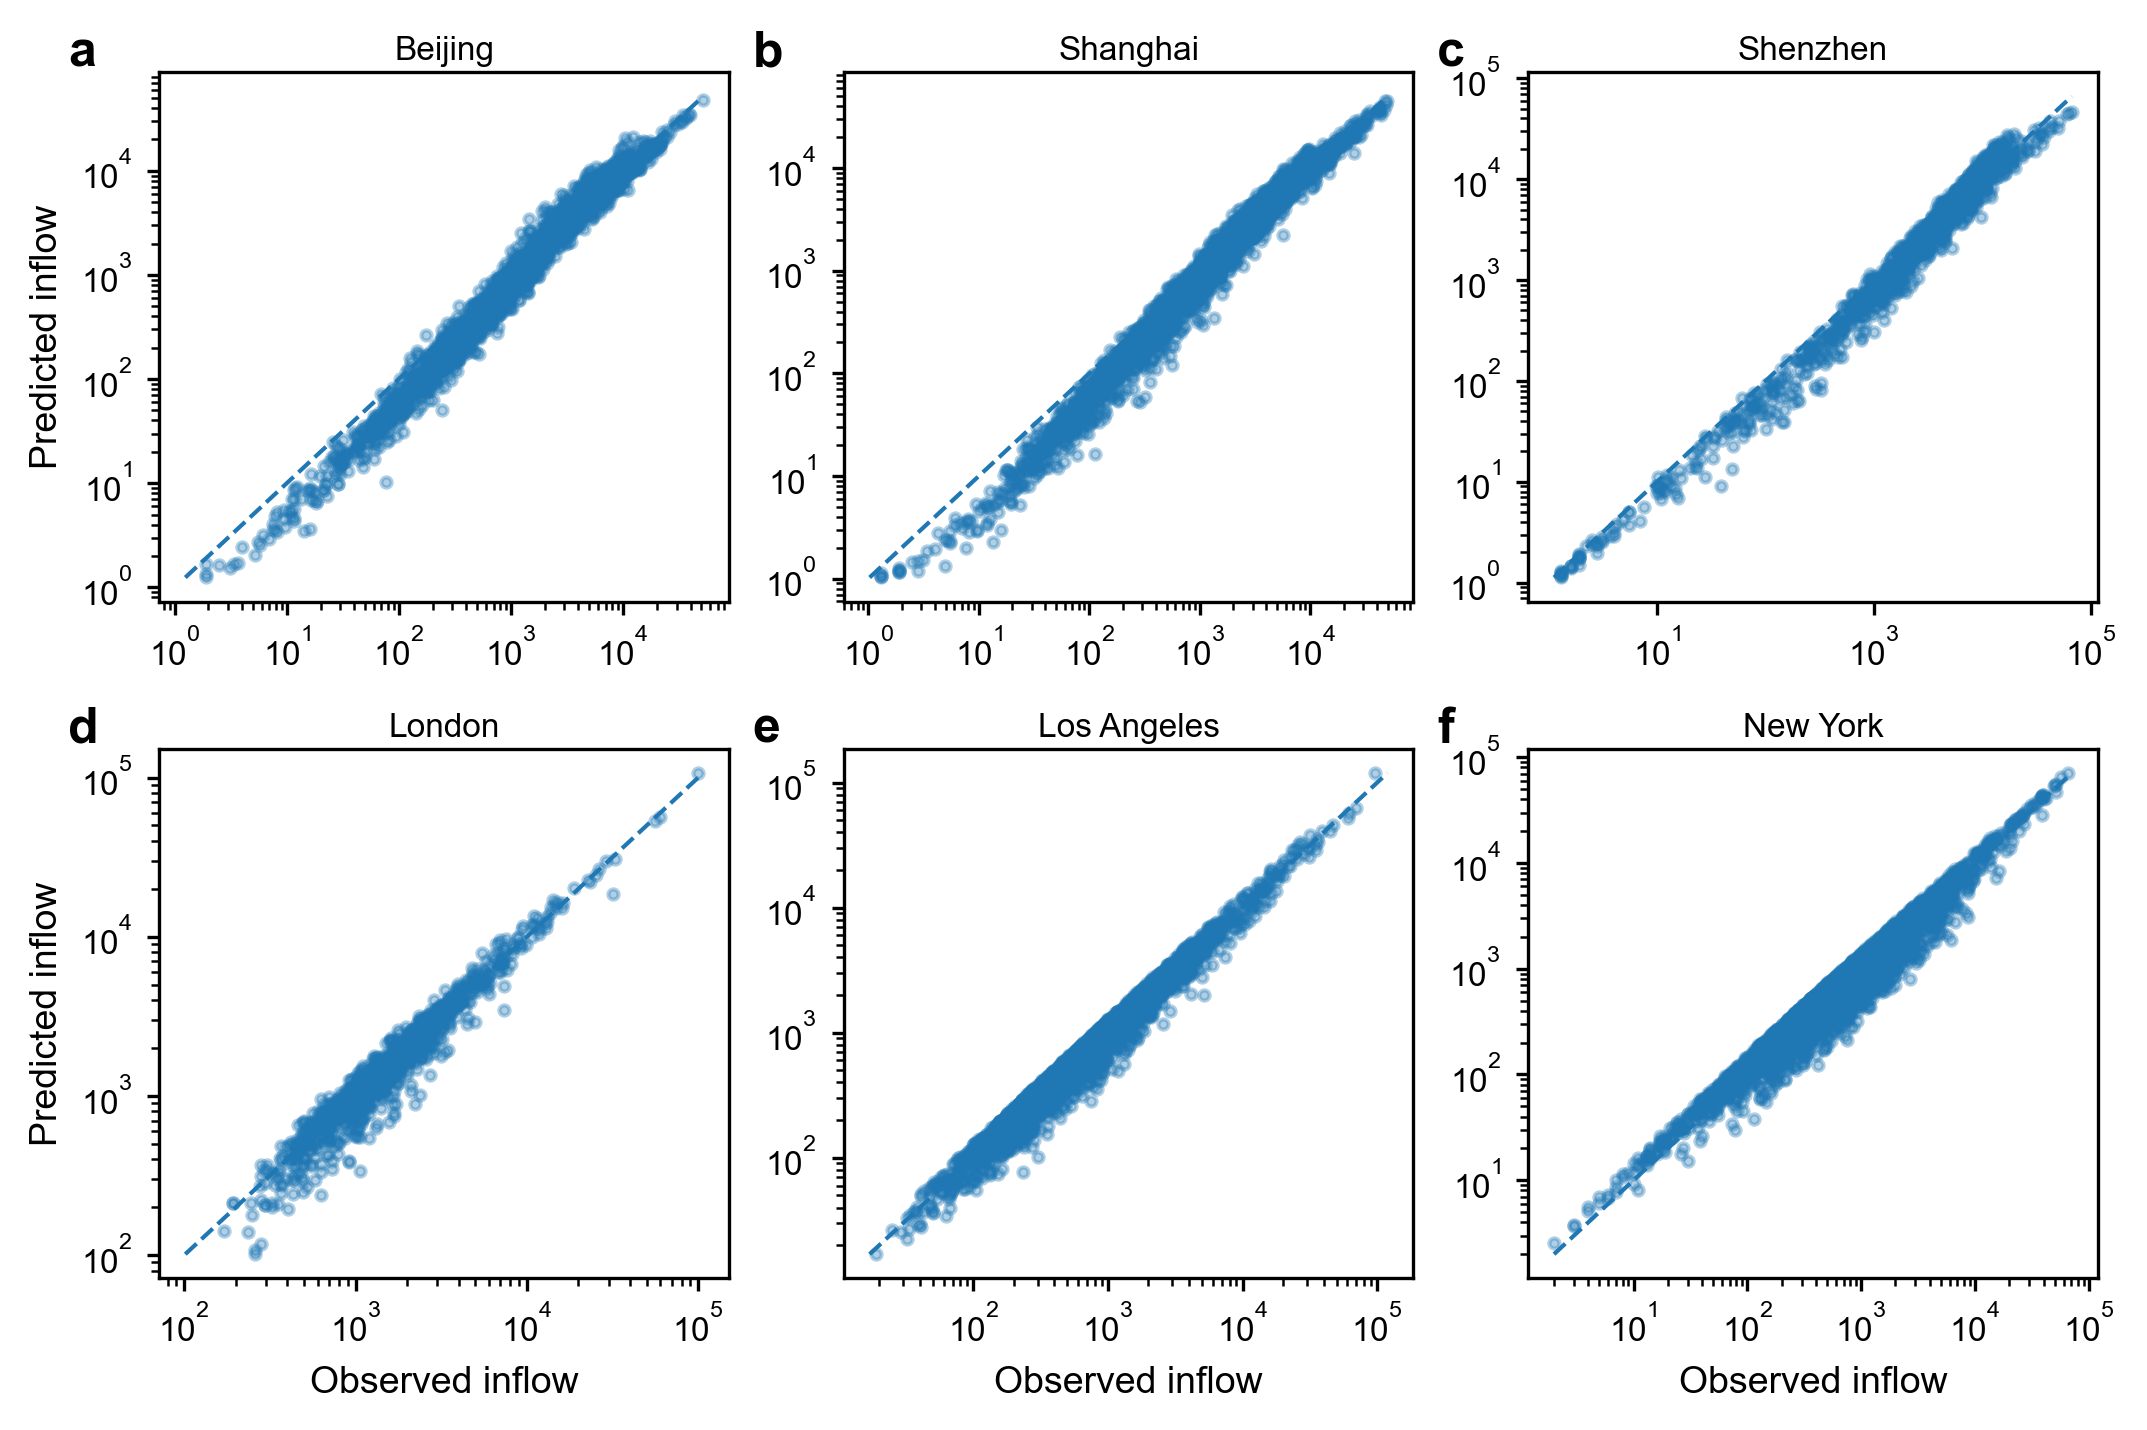

In [136]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =====================================
# Basic settings
# =====================================

BASE_DIR = "D:/urban_hierarchy_congestion"

city_order = ["beijing", "shanghai", "shenzhen", "london", "losangeles", "newyork"]
city_labels = {
    "beijing": "Beijing",
    "shanghai": "Shanghai",
    "shenzhen": "Shenzhen",
    "london": "London",
    "losangeles": "Los Angeles",
    "newyork": "New York",
}

panel_labels = ["a", "b", "c", "d", "e", "f"]

FLOW_COL = "flow"
PRED_COL = "flow_pred"
DEST_COL = "d_id"
DIST_COL = "rdist"   # 直接指定路网距离列

# 如果 rdist 单位是米就设为 True；如果已经是 km 就设为 False
DIST_IN_METERS = False

# 距离分箱宽度（km）
BIN_WIDTH_KM = 2

# 输出文件名
OUT_FIG_DIST = "results/figures/gravity_model_fit_distance_distribution.jpg"
OUT_FIG_INFLOW = "results/figures/gravity_model_fit_destination_inflow.jpg"


# =====================================
# Plot style
# =====================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.linewidth": 0.8,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 300,
    "savefig.dpi": 600
})


# =====================================
# Helper functions
# =====================================

def prepare_od_table(df, flow_col="flow", pred_col="flow_pred", dist_col="rdist"):
    df = df.copy()

    for col in [flow_col, pred_col, dist_col]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 去掉缺失
    df = df.dropna(subset=[flow_col, pred_col, dist_col])

    # 只保留 inter-zonal 且距离 > 0 的记录
    df = df[(df[dist_col] > 0) & (df[flow_col] >= 0) & (df[pred_col] >= 0)]

    if DIST_IN_METERS:
        df["dist_km"] = df[dist_col] / 1000.0
    else:
        df["dist_km"] = df[dist_col]

    return df


def calc_distance_distribution(df, flow_col="flow", pred_col="flow_pred", bin_width_km=2):
    df = df.copy()

    max_dist = np.ceil(df["dist_km"].max() / bin_width_km) * bin_width_km
    bins = np.arange(0, max_dist + bin_width_km, bin_width_km)

    df["dist_bin"] = pd.cut(
        df["dist_km"],
        bins=bins,
        include_lowest=True,
        right=False
    )

    agg = (
        df.groupby("dist_bin", observed=False)[[flow_col, pred_col]]
        .sum()
        .reset_index()
        .rename(columns={flow_col: "flow_obs", pred_col: "flow_pred"})
    )

    agg["share_obs"] = agg["flow_obs"] / agg["flow_obs"].sum()
    agg["share_pred"] = agg["flow_pred"] / agg["flow_pred"].sum()
    agg["dist_mid_km"] = [float(interval.mid) for interval in agg["dist_bin"].astype(object)]

    # 删除 observed 或 predicted 为0的bin
    agg = agg[(agg["share_obs"] > 0) & (agg["share_pred"] > 0)]

    return agg[["dist_mid_km", "flow_obs", "flow_pred", "share_obs", "share_pred"]]


def calc_destination_inflow(df, dest_col="d_id", flow_col="flow", pred_col="flow_pred"):
    agg = (
        df.groupby(dest_col, as_index=False)[[flow_col, pred_col]]
        .sum()
        .rename(columns={flow_col: "inflow_obs", pred_col: "inflow_pred"})
    )
    return agg


# =====================================
# Read data and calculate summaries
# =====================================

dist_results = []
inflow_results = []

for city in city_order:
    file_path = BASE_DIR+"/results/gravity_model_fit/"+city+"_full_od_gravity_fit.csv"
    print(f"Reading: {file_path}")

    df = pd.read_csv(file_path)
    df = prepare_od_table(df, flow_col=FLOW_COL, pred_col=PRED_COL, dist_col=DIST_COL)

    # Distance distribution
    dist_agg = calc_distance_distribution(df, flow_col=FLOW_COL, pred_col=PRED_COL, bin_width_km=BIN_WIDTH_KM)
    dist_agg["city"] = city
    dist_agg["city_label"] = city_labels[city]
    dist_results.append(dist_agg)

    # Destination inflow
    inflow_agg = calc_destination_inflow(df, dest_col=DEST_COL, flow_col=FLOW_COL, pred_col=PRED_COL)
    inflow_agg["city"] = city
    inflow_agg["city_label"] = city_labels[city]
    inflow_results.append(inflow_agg)

dist_df = pd.concat(dist_results, ignore_index=True)
inflow_df = pd.concat(inflow_results, ignore_index=True)


# =====================================
# Figure 1: Distance distribution comparison
# =====================================

fig, axes = plt.subplots(2, 3, figsize=(7.2, 4.8))
axes = axes.flatten()

for i, city in enumerate(city_order):
    ax = axes[i]
    tmp = dist_df[dist_df["city"] == city].sort_values("dist_mid_km")

    ax.plot(
        tmp["dist_mid_km"], tmp["share_obs"],
        linewidth=1.2, marker="o", markersize=2.3,
        label="Observed"
    )
    ax.plot(
        tmp["dist_mid_km"], tmp["share_pred"],
        linewidth=1.2, linestyle="--",
        label="Predicted"
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(city_labels[city], fontsize=8, pad=3)

    # panel label
    ax.text(
        -0.16, 1.08, panel_labels[i],
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        va="top",
        ha="left"
    )

    #ax.spines["top"].set_visible(False)
    #ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", which="major", length=3, width=0.8)
    ax.tick_params(axis="both", which="minor", length=2, width=0.6)

    if i >= 3:
        ax.set_xlabel("Distance (km)")
    if i % 3 == 0:
        ax.set_ylabel("Share of flows")

    if i == 0:
        ax.legend(frameon=False, loc="lower left")

plt.tight_layout()
plt.savefig(OUT_FIG_DIST, bbox_inches="tight")
plt.show()


# =====================================
# Figure 2: Destination inflow comparison
# =====================================

fig, axes = plt.subplots(2, 3, figsize=(7.2, 4.8))
axes = axes.flatten()

for i, city in enumerate(city_order):
    ax = axes[i]
    tmp = inflow_df[inflow_df["city"] == city].copy()

    x = tmp["inflow_obs"]+1
    y = tmp["inflow_pred"]+1

    ax.scatter(x, y, s=6, alpha=0.35)

    xy_min = min(x.min(), y.min())
    xy_max = max(x.max(), y.max())
    ax.plot([xy_min, xy_max], [xy_min, xy_max], linestyle="--", linewidth=1)
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_title(city_labels[city], fontsize=8, pad=3)

    # panel label
    ax.text(
        -0.16, 1.08, panel_labels[i],
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        ha="left"
    )

    #ax.spines["top"].set_visible(False)
    #ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", which="major", length=3, width=0.8)
    ax.tick_params(axis="both", which="minor", length=2, width=0.6)

    if i >= 3:
        ax.set_xlabel("Observed inflow")
    if i % 3 == 0:
        ax.set_ylabel("Predicted inflow")

plt.tight_layout()
plt.savefig(OUT_FIG_INFLOW, bbox_inches="tight")
plt.show()

## Extended data fig.5

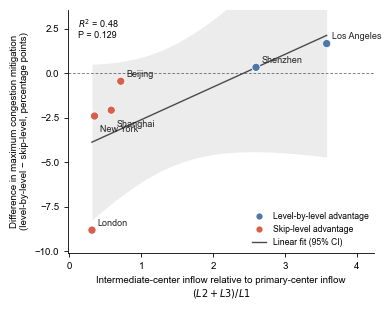

In [134]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from scipy import stats


INFLOW_DIR = Path("results/summary_tables")
SCENARIO_DIR = Path("results/traffic_assignment_results")
OUTPUT_PATH = Path("results/figures/Extended_Data_Fig5_pathway_advantage.jpg")

CITY_CONFIGS = [
    ("Beijing", "beijing"),
    ("Shanghai", "shanghai"),
    ("Shenzhen", "shenzhen"),
    ("London", "london"),
    ("Los Angeles", "losangeles"),
    ("New York", "newyork"),
]

LEVEL_BY_LEVEL = ["L1_to_L2", "L2_to_L3", "L3_to_L4"]
SKIP_LEVEL = ["L1_to_L3", "L1_to_L4"]

LEVEL_COLOR = "#4C78A8"
SKIP_COLOR = "#D6604D"
FIT_COLOR = "#4A4A4A"

# Adjust these offsets if a city label overlaps another element.
LABEL_OFFSETS = {
    "Beijing": (4, 5),
    "Shanghai": (4, -10),
    "Shenzhen": (4, 5),
    "London": (4, 5),
    "Los Angeles": (4, 5),
    "New York": (4, -10),
}

mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 7.0,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


def normalize_level(value) -> int:
    digits = "".join(character for character in str(value) if character.isdigit())
    if not digits:
        raise ValueError(f"Cannot interpret hierarchy level: {value}")
    return int(digits)


def read_intermediate_center_ratio(prefix: str) -> float:
    path = INFLOW_DIR / f"{prefix}_level_inflow.csv"
    if not path.exists():
        raise FileNotFoundError(f"Required inflow file not found: {path}")

    df = pd.read_csv(path)
    required = {"level", "inflow"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    df = df.loc[:, ["level", "inflow"]].copy()
    df["level"] = df["level"].map(normalize_level)
    df["inflow"] = pd.to_numeric(df["inflow"], errors="coerce")
    if df["inflow"].isna().any() or (df["inflow"] < 0).any():
        raise ValueError(f"Invalid inflow values in {path}")

    inflow = df.groupby("level")["inflow"].sum()
    missing_levels = {1, 2, 3}.difference(inflow.index)
    if missing_levels:
        raise ValueError(f"{path} is missing levels: {sorted(missing_levels)}")
    if inflow.loc[1] <= 0:
        raise ValueError(f"L1 inflow must be greater than zero: {path}")

    return float((inflow.loc[2] + inflow.loc[3]) / inflow.loc[1])


def read_pathway_advantage(prefix: str) -> tuple[float, float, float]:
    path = SCENARIO_DIR / prefix / "scenario_simulation_results_final.csv"
    if not path.exists():
        raise FileNotFoundError(f"Required scenario file not found: {path}")

    df = pd.read_csv(path)
    required = {"scenario", "congestion_mitigation_pct"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    df = df.loc[:, ["scenario", "congestion_mitigation_pct"]].copy()
    df["scenario"] = df["scenario"].astype(str).str.strip()
    df["congestion_mitigation_pct"] = pd.to_numeric(
        df["congestion_mitigation_pct"], errors="coerce"
    )

    level_values = df.loc[
        df["scenario"].isin(LEVEL_BY_LEVEL), "congestion_mitigation_pct"
    ].dropna()
    skip_values = df.loc[
        df["scenario"].isin(SKIP_LEVEL), "congestion_mitigation_pct"
    ].dropna()

    if level_values.empty or skip_values.empty:
        raise ValueError(f"Missing pathway results in {path}")

    level_max = float(level_values.max())
    skip_max = float(skip_values.max())

    # Positive values indicate an advantage for level-by-level redistribution.
    return level_max, skip_max, level_max - skip_max


def build_plot_data() -> pd.DataFrame:
    records = []
    for city_name, prefix in CITY_CONFIGS:
        level_max, skip_max, advantage = read_pathway_advantage(prefix)
        records.append(
            {
                "city": city_name,
                "intermediate_to_primary_inflow": read_intermediate_center_ratio(prefix),
                "level_by_level_max": level_max,
                "skip_level_max": skip_max,
                "mitigation_difference_pp": advantage,
            }
        )
    return pd.DataFrame(records)


def add_linear_fit(ax, x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    fit = stats.linregress(x, y)
    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = fit.intercept + fit.slope * x_fit

    residuals = y - (fit.intercept + fit.slope * x)
    residual_standard_error = np.sqrt(np.sum(residuals**2) / (len(x) - 2))
    x_deviation = np.sum((x - x.mean()) ** 2)
    t_critical = stats.t.ppf(0.975, len(x) - 2)
    confidence_interval = t_critical * residual_standard_error * np.sqrt(
        1 / len(x) + (x_fit - x.mean()) ** 2 / x_deviation
    )

    ax.fill_between(
        x_fit,
        y_fit - confidence_interval,
        y_fit + confidence_interval,
        color=FIT_COLOR,
        alpha=0.10,
        linewidth=0,
        zorder=1,
    )
    ax.plot(x_fit, y_fit, color=FIT_COLOR, linewidth=1.0, zorder=2)
    return fit.rvalue**2, fit.pvalue


def format_p_value(value: float) -> str:
    if value < 0.001:
        return "P < 0.001"
    return f"P = {value:.3f}"


def create_figure() -> None:
    data = build_plot_data()
    x = data["intermediate_to_primary_inflow"].to_numpy(dtype=float)
    y = data["mitigation_difference_pp"].to_numpy(dtype=float)

    if np.unique(x).size < 2:
        raise ValueError("At least two distinct inflow ratios are required for a linear fit.")

    figure, ax = plt.subplots(figsize=(10.0 / 2.54, 8.0 / 2.54))
    r_squared, p_value = add_linear_fit(ax, x, y)

    point_colors = np.where(y >= 0, LEVEL_COLOR, SKIP_COLOR)
    ax.scatter(
        x,
        y,
        s=35,
        c=point_colors,
        edgecolor="white",
        linewidth=0.6,
        zorder=3,
    )

    for row in data.itertuples(index=False):
        dx, dy = LABEL_OFFSETS[row.city]
        ax.annotate(
            row.city,
            (row.intermediate_to_primary_inflow, row.mitigation_difference_pp),
            xytext=(dx, dy),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=6.5,
            color="#222222",
            zorder=4,
        )

    ax.axhline(0, color="#777777", linewidth=0.65, linestyle=(0, (3, 2)), zorder=0)
    ax.text(
        0.03,
        0.97,
        f"$R^2$ = {r_squared:.2f}\n{format_p_value(p_value)}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=6.5,
    )

    ax.set_xlabel(
        "Intermediate-center inflow relative to primary-center inflow\n"
        r"$(L2 + L3) / L1$",
        labelpad=4,
    )
    ax.set_ylabel(
        "Difference in maximum congestion mitigation\n"
        "(level-by-level − skip-level, percentage points)",
        labelpad=4,
    )

    x_span = x.max() - x.min()
    y_span = y.max() - y.min()
    ax.set_xlim(x.min() - 0.10 * x_span, x.max() + 0.20 * x_span)
    ax.set_ylim(y.min() - 0.12 * y_span, y.max() + 0.18 * y_span)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5, min_n_ticks=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6, min_n_ticks=4))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", direction="out")

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor=LEVEL_COLOR,
            markeredgecolor="white",
            markersize=5.5,
            label="Level-by-level advantage",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor=SKIP_COLOR,
            markeredgecolor="white",
            markersize=5.5,
            label="Skip-level advantage",
        ),
        Line2D(
            [0],
            [0],
            color=FIT_COLOR,
            linewidth=1.0,
            label="Linear fit (95% CI)",
        ),
    ]
    ax.legend(
        handles=legend_handles,
        loc="lower right",
        frameon=False,
        fontsize=6.2,
        handlelength=1.6,
        borderaxespad=0.2,
    )

    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        OUTPUT_PATH,
        dpi=600,
        format="jpg",
        bbox_inches="tight",
        pil_kwargs={"quality": 95, "subsampling": 0},
    )
    #plt.close(figure)


if __name__ == "__main__":
    create_figure()

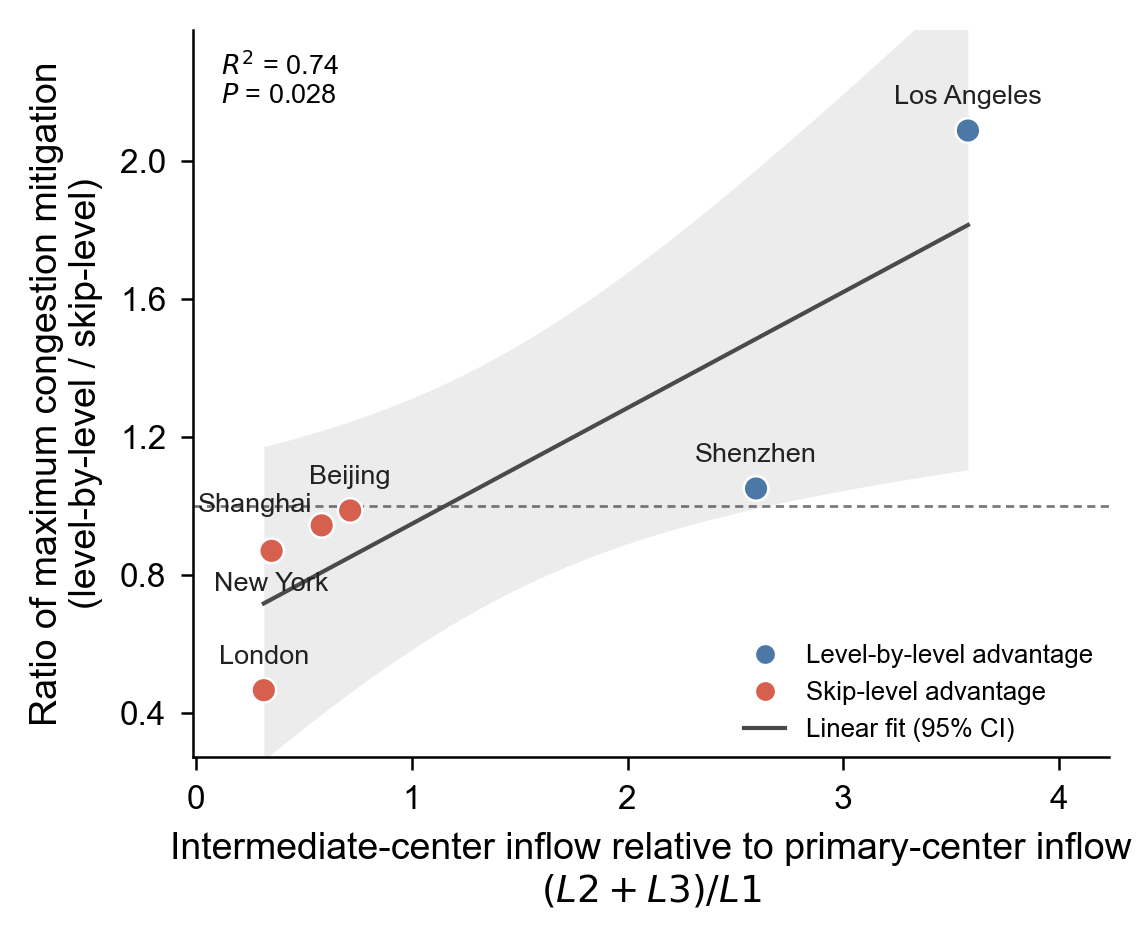

In [139]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
import statsmodels.api as sm


INFLOW_DIR = Path("results/summary_tables")
SCENARIO_DIR = Path("results/traffic_assignment_results")
OUTPUT_PATH = Path("results/figures/Extended_Data_Fig5_pathway_advantage.jpg")

CITY_CONFIGS = [
    ("Beijing", "beijing"),
    ("Shanghai", "shanghai"),
    ("Shenzhen", "shenzhen"),
    ("London", "london"),
    ("Los Angeles", "losangeles"),
    ("New York", "newyork"),
]

LEVEL_BY_LEVEL = ["L1_to_L2", "L2_to_L3", "L3_to_L4"]
SKIP_LEVEL = ["L1_to_L3", "L1_to_L4"]

LEVEL_COLOR = "#4C78A8"
SKIP_COLOR = "#D6604D"
FIT_COLOR = "#4A4A4A"

# Adjust these offsets if a city label overlaps another element.
LABEL_POSITIONS = {
    "Beijing": {"offset": (0, 8), "ha": "center"},
    "Shanghai": {"offset": (-16, 5), "ha": "center"},
    "Shenzhen": {"offset": (0, 8), "ha": "center"},
    "London": {"offset": (0, 8), "ha": "center"},
    "Los Angeles": {"offset": (0, 8), "ha": "center"},
    "New York": {"offset": (0, -8), "ha": "center"},
}

mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 7.0,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


def normalize_level(value) -> int:
    digits = "".join(character for character in str(value) if character.isdigit())
    if not digits:
        raise ValueError(f"Cannot interpret hierarchy level: {value}")
    return int(digits)


def read_intermediate_center_ratio(prefix: str) -> float:
    path = INFLOW_DIR / f"{prefix}_level_inflow.csv"
    if not path.exists():
        raise FileNotFoundError(f"Required inflow file not found: {path}")

    df = pd.read_csv(path)
    required = {"level", "inflow"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    df = df.loc[:, ["level", "inflow"]].copy()
    df["level"] = df["level"].map(normalize_level)
    df["inflow"] = pd.to_numeric(df["inflow"], errors="coerce")
    if df["inflow"].isna().any() or (df["inflow"] < 0).any():
        raise ValueError(f"Invalid inflow values in {path}")

    inflow = df.groupby("level")["inflow"].sum()
    missing_levels = {1, 2, 3}.difference(inflow.index)
    if missing_levels:
        raise ValueError(f"{path} is missing levels: {sorted(missing_levels)}")
    if inflow.loc[1] <= 0:
        raise ValueError(f"L1 inflow must be greater than zero: {path}")

    return float((inflow.loc[2] + inflow.loc[3]) / inflow.loc[1])


def read_pathway_advantage(prefix: str) -> tuple[float, float, float]:
    path = SCENARIO_DIR / prefix / "scenario_simulation_results_final.csv"
    if not path.exists():
        raise FileNotFoundError(f"Required scenario file not found: {path}")

    df = pd.read_csv(path)
    required = {"scenario", "congestion_mitigation_pct"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    df = df.loc[:, ["scenario", "congestion_mitigation_pct"]].copy()
    df["scenario"] = df["scenario"].astype(str).str.strip()
    df["congestion_mitigation_pct"] = pd.to_numeric(
        df["congestion_mitigation_pct"], errors="coerce"
    )

    level_values = df.loc[
        df["scenario"].isin(LEVEL_BY_LEVEL), "congestion_mitigation_pct"
    ].dropna()
    skip_values = df.loc[
        df["scenario"].isin(SKIP_LEVEL), "congestion_mitigation_pct"
    ].dropna()

    if level_values.empty or skip_values.empty:
        raise ValueError(f"Missing pathway results in {path}")

    level_max = float(level_values.max())
    skip_max = float(skip_values.max())

    # Positive values indicate an advantage for level-by-level redistribution.
    return level_max, skip_max, level_max / skip_max


def build_plot_data() -> pd.DataFrame:
    records = []
    for city_name, prefix in CITY_CONFIGS:
        level_max, skip_max, advantage = read_pathway_advantage(prefix)
        records.append(
            {
                "city": city_name,
                "intermediate_to_primary_inflow": read_intermediate_center_ratio(prefix),
                "level_by_level_max": level_max,
                "skip_level_max": skip_max,
                "mitigation_difference_pp": advantage,
            }
        )
    return pd.DataFrame(records)


def add_linear_fit(ax, x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    design = sm.add_constant(x)
    model = sm.OLS(y, design).fit()

    x_fit = np.linspace(x.min(), x.max(), 200)
    fit_design = sm.add_constant(x_fit)
    prediction = model.get_prediction(fit_design).summary_frame(alpha=0.05)

    ax.fill_between(
        x_fit,
        prediction["mean_ci_lower"].to_numpy(),
        prediction["mean_ci_upper"].to_numpy(),
        color=FIT_COLOR,
        alpha=0.10,
        linewidth=0,
        zorder=1,
    )
    ax.plot(
        x_fit,
        prediction["mean"].to_numpy(),
        color=FIT_COLOR,
        linewidth=1.0,
        zorder=2,
    )
    return float(model.rsquared), float(model.f_pvalue)


def format_p_value(value: float) -> str:
    if value < 0.001:
        return "P < 0.001"
    return f"$P$ = {value:.3f}"


def create_figure() -> None:
    data = build_plot_data()
    x = data["intermediate_to_primary_inflow"].to_numpy(dtype=float)
    y = data["mitigation_difference_pp"].to_numpy(dtype=float)

    if np.unique(x).size < 2:
        raise ValueError("At least two distinct inflow ratios are required for a linear fit.")

    figure, ax = plt.subplots(figsize=(10.0 / 2.54, 8.0 / 2.54))
    r_squared, p_value = add_linear_fit(ax, x, y)

    point_colors = np.where(y >= 1, LEVEL_COLOR, SKIP_COLOR)
    ax.scatter(
        x,
        y,
        s=35,
        c=point_colors,
        edgecolor="white",
        linewidth=0.6,
        zorder=3,
    )

    for row in data.itertuples(index=False):
        label_position = LABEL_POSITIONS[row.city]
        ax.annotate(
            row.city,
            (row.intermediate_to_primary_inflow, row.mitigation_difference_pp),
            xytext=label_position["offset"],
            textcoords="offset points",
            ha=label_position["ha"],
            va="center",
            fontsize=6.5,
            color="#222222",
            zorder=4,
        )

    ax.axhline(1, color="#777777", linewidth=0.65, linestyle=(0, (3, 2)), zorder=0)
    ax.text(
        0.03,
        0.97,
        f"$R^2$ = {r_squared:.2f}\n{format_p_value(p_value)}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=6.5,
    )

    ax.set_xlabel(
        "Intermediate-center inflow relative to primary-center inflow\n"
        r"$(L2 + L3) / L1$",
        labelpad=4,
    )
    ax.set_ylabel(
        "Ratio of maximum congestion mitigation\n"
        "(level-by-level / skip-level)",
        labelpad=4,
    )

    x_span = x.max() - x.min()
    y_span = y.max() - y.min()
    ax.set_xlim(x.min() - 0.10 * x_span, x.max() + 0.20 * x_span)
    ax.set_ylim(y.min() - 0.12 * y_span, y.max() + 0.18 * y_span)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5, min_n_ticks=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6, min_n_ticks=4))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", direction="out")

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor=LEVEL_COLOR,
            markeredgecolor="white",
            markersize=5.5,
            label="Level-by-level advantage",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor=SKIP_COLOR,
            markeredgecolor="white",
            markersize=5.5,
            label="Skip-level advantage",
        ),
        Line2D(
            [0],
            [0],
            color=FIT_COLOR,
            linewidth=1.0,
            label="Linear fit (95% CI)",
        ),
    ]
    ax.legend(
        handles=legend_handles,
        loc="lower right",
        frameon=False,
        fontsize=6.2,
        handlelength=1.6,
        borderaxespad=0.2,
    )

    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        OUTPUT_PATH,
        dpi=600,
        format="jpg",
        bbox_inches="tight",
        pil_kwargs={"quality": 95, "subsampling": 0},
    )
    #plt.close(figure)


if __name__ == "__main__":
    create_figure()

## Extended data fig.6

Saved: results\figures\Extended_Data_Fig6_skiplevel_upward_flow_change.jpg


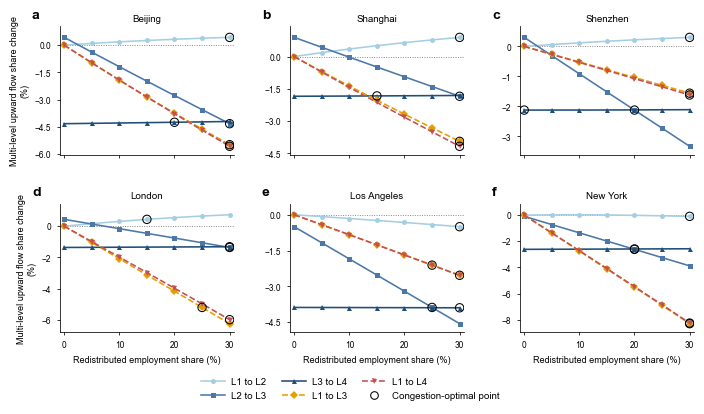

In [133]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator


RESULTS_DIR = Path("results/traffic_assignment_results")
OUTPUT_PATH = Path(
    "results/figures/Extended_Data_Fig6_skiplevel_upward_flow_change.jpg"
)

CITY_CONFIGS = [
    ("Beijing", "beijing"),
    ("Shanghai", "shanghai"),
    ("Shenzhen", "shenzhen"),
    ("London", "london"),
    ("Los Angeles", "losangeles"),
    ("New York", "newyork"),
]

SCENARIO_ORDER = [
    "L1_to_L2",
    "L2_to_L3",
    "L3_to_L4",
    "L1_to_L3",
    "L1_to_L4",
]

SCENARIO_STYLES = {
    "L1_to_L2": ("L1 to L2", "#A6CEE3", "-", "o"),
    "L2_to_L3": ("L2 to L3", "#4C78A8", "-", "s"),
    "L3_to_L4": ("L3 to L4", "#1F4E79", "-", "^"),
    "L1_to_L3": ("L1 to L3", "#E69F00", "--", "D"),
    "L1_to_L4": ("L1 to L4", "#C44E52", "--", "v"),
}

mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 6.5,
        "axes.linewidth": 0.55,
        "xtick.major.width": 0.55,
        "ytick.major.width": 0.55,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


def read_city_results(prefix):
    path = (
        RESULTS_DIR
        / prefix
        / "scenario_simulation_results_with_multilevel_upward_flow.csv"
    )
    if not path.exists():
        raise FileNotFoundError(f"Required result file not found: {path}")

    required = {
        "scenario",
        "prop",
        "congestion_mitigation_pct",
        "multi_level_upward_share_change_pp",
    }
    data = pd.read_csv(path, encoding="utf-8-sig")
    missing = required.difference(data.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    data = data.loc[:, list(required)].copy()
    data["scenario"] = data["scenario"].astype(str).str.strip()
    numeric_columns = required.difference({"scenario"})
    data[list(numeric_columns)] = data[list(numeric_columns)].apply(
        pd.to_numeric, errors="coerce"
    )

    curves = data.loc[data["scenario"].isin(SCENARIO_ORDER)].copy()
    if curves[list(numeric_columns)].isna().any().any():
        raise ValueError(f"{path} contains missing or non-numeric plotting values.")
    if set(curves["scenario"]) != set(SCENARIO_ORDER):
        missing_scenarios = sorted(set(SCENARIO_ORDER).difference(curves["scenario"]))
        raise ValueError(f"Missing scenarios in {path}: {missing_scenarios}")
    if not curves["prop"].between(0, 0.3 + 1e-9).all():
        raise ValueError(f"prop must range from 0 to 0.3: {path}")
    if curves.duplicated(["scenario", "prop"]).any():
        raise ValueError(f"Duplicate scenario-prop combinations found in {path}")

    return curves


def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", direction="out", labelsize=6.0)


def set_city_y_limits(ax, values):
    values = np.asarray(values, dtype=float)
    lower = min(0.0, float(values.min()))
    upper = max(0.0, float(values.max()))
    span = upper - lower
    if np.isclose(span, 0.0):
        span = 1.0
    ax.set_ylim(lower - 0.08 * span, upper + 0.10 * span)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, min_n_ticks=3))


def create_figure():
    city_data = [
        (city_name, read_city_results(prefix))
        for city_name, prefix in CITY_CONFIGS
    ]

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(18.0 / 2.54, 10.5 / 2.54),
        sharex=True,
    )

    for panel_index, (ax, (city_name, data)) in enumerate(
        zip(axes.flat, city_data)
    ):
        for scenario in SCENARIO_ORDER:
            label, color, linestyle, marker = SCENARIO_STYLES[scenario]
            curve = data.loc[data["scenario"] == scenario].sort_values("prop")

            ax.plot(
                curve["prop"] * 100,
                curve["multi_level_upward_share_change_pp"],
                color=color,
                linestyle=linestyle,
                marker=marker,
                markersize=3.6,
                markeredgewidth=0,
                linewidth=1.15,
                label=label,
                zorder=2,
            )

            optimum = curve.sort_values(
                ["congestion_mitigation_pct", "prop"],
                ascending=[False, True],
            ).iloc[0]
            ax.scatter(
                optimum["prop"] * 100,
                optimum["multi_level_upward_share_change_pp"],
                s=36,
                facecolors="none",
                edgecolors="black",
                linewidths=0.75,
                zorder=4,
            )

        ax.axhline(0, color="#777777", linewidth=0.65, linestyle=":", zorder=1)
        ax.set_xlim(-0.8, 30.8)
        ax.set_xticks([0, 10, 20, 30])
        set_city_y_limits(ax, data["multi_level_upward_share_change_pp"])
        style_axis(ax)

        ax.set_title(city_name, fontsize=7.0, pad=4)
        ax.text(
            -0.16,
            1.04,
            chr(97 + panel_index),
            transform=ax.transAxes,
            fontsize=10.0,
            fontweight="bold",
            ha="left",
            va="bottom",
            clip_on=False,
        )

        if panel_index >= 3:
            ax.set_xlabel("Redistributed employment share (%)", fontsize=6.5)
        if panel_index % 3 == 0:
            ax.set_ylabel(
                "Multi-level upward flow share change\n(%)",
                fontsize=6.5,
            )

    legend_handles = [
        Line2D(
            [0],
            [0],
            color=SCENARIO_STYLES[scenario][1],
            linestyle=SCENARIO_STYLES[scenario][2],
            marker=SCENARIO_STYLES[scenario][3],
            markersize=3.6,
            markeredgewidth=0,
            linewidth=1.15,
            label=SCENARIO_STYLES[scenario][0],
        )
        for scenario in SCENARIO_ORDER
    ]
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color="none",
            marker="o",
            markerfacecolor="none",
            markeredgecolor="black",
            markeredgewidth=0.75,
            markersize=5.5,
            label="Congestion-optimal point",
        )
    )

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.015),
        ncol=3,
        frameon=False,
        fontsize=7,
        handlelength=2.5,
        columnspacing=1.6,
        handletextpad=0.6,
    )
    fig.subplots_adjust(
        left=0.09,
        right=0.985,
        bottom=0.20,
        top=0.94,
        wspace=0.32,
        hspace=0.38,
    )
    return fig


def main():
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    figure = create_figure()
    figure.savefig(
        OUTPUT_PATH,
        dpi=600,
        format="jpg",
        pil_kwargs={"quality": 100, "subsampling": 0},
    )
    #plt.close(figure)
    print(f"Saved: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

## Extended data table 1

In [ ]:
from pathlib import Path

import pandas as pd


RESULTS_DIR = Path("results/traffic_assignment_results")
OUTPUT_PATH = Path(
    "results/figures/Extended_Data_Table_1_optimal_redistribution_outcomes.csv"
)


CITY_CONFIGS = [
    {"city_name": "Beijing", "prefix": "beijing"},
    {"city_name": "Shanghai", "prefix": "shanghai"},
    {"city_name": "Shenzhen", "prefix": "shenzhen"},
    {"city_name": "London", "prefix": "london"},
    {"city_name": "Los Angeles", "prefix": "losangeles"},
    {"city_name": "New York", "prefix": "newyork"},
]


LEVEL_BY_LEVEL_STAGES = ["L1_to_L2", "L2_to_L3", "L3_to_L4"]
SKIP_LEVEL_SCENARIOS = ["L1_to_L3", "L1_to_L4"]
SCENARIO_ORDER = LEVEL_BY_LEVEL_STAGES + SKIP_LEVEL_SCENARIOS


OUTPUT_COLUMNS = [
    "City",
    "Redistribution pathway",
    "Optimal configuration",
    "Terminal scenario",
    "Terminal redistributed share (%)",
    "Congestion mitigation (%)",
    "Travel-time reduction (%)",
    "Congestion-related CO2 reduction (%)",
    "Agglomeration-potential loss (%)",
]


def result_path(prefix: str) -> Path:
    return RESULTS_DIR / prefix / "scenario_simulation_results_final.csv"


def read_city_results(prefix: str) -> pd.DataFrame:
    path = result_path(prefix)
    if not path.exists():
        raise FileNotFoundError(f"Required scenario file not found: {path}")

    df = pd.read_csv(path, encoding="utf-8-sig")
    required = {
        "scenario",
        "prop",
        "congestion_mitigation_pct",
        "TTT",
        "CO2_excess_reduction_pct",
        "AGG_loss_pct",
    }
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    df = df.loc[:, list(required)].copy()
    df["scenario"] = df["scenario"].astype(str).str.strip()

    numeric_columns = [
        "prop",
        "congestion_mitigation_pct",
        "TTT",
        "CO2_excess_reduction_pct",
        "AGG_loss_pct",
    ]
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    expected = {"baseline", *SCENARIO_ORDER}
    missing_scenarios = sorted(expected.difference(df["scenario"]))
    if missing_scenarios:
        raise ValueError(f"Missing scenarios in {path}: {missing_scenarios}")

    baseline_ttt = df.loc[df["scenario"] == "baseline", "TTT"].dropna().unique()
    if len(baseline_ttt) != 1 or baseline_ttt[0] <= 0:
        raise ValueError(f"A single positive baseline TTT is required in {path}.")

    scenario_rows = df.loc[df["scenario"].isin(SCENARIO_ORDER)].copy()
    if scenario_rows[numeric_columns].isna().any().any():
        raise ValueError(f"Scenario rows contain missing or non-numeric values: {path}")
    if not scenario_rows["prop"].between(0, 0.3 + 1e-9).all():
        raise ValueError(f"prop must range from 0 to 0.3: {path}")
    if (scenario_rows["TTT"] <= 0).any():
        raise ValueError(f"TTT must be greater than zero: {path}")

    for scenario in SCENARIO_ORDER:
        curve = scenario_rows.loc[scenario_rows["scenario"] == scenario]
        if curve.empty:
            raise ValueError(f"No rows found for scenario '{scenario}' in {path}.")
        if curve["prop"].duplicated().any():
            raise ValueError(f"Duplicate prop values for scenario '{scenario}' in {path}.")

    return df


def select_optimum(df: pd.DataFrame, scenarios: list[str]) -> pd.Series:
    order = {scenario: index for index, scenario in enumerate(SCENARIO_ORDER)}
    candidates = df.loc[df["scenario"].isin(scenarios)].copy()
    candidates["scenario_order"] = candidates["scenario"].map(order)

    return candidates.sort_values(
        ["congestion_mitigation_pct", "prop", "scenario_order"],
        ascending=[False, True, True],
    ).iloc[0]


def scenario_label(scenario: str) -> str:
    return scenario.replace("_to_", " to ")


def share_label(prop: float) -> str:
    return f"{prop * 100:.0f}%"


def level_by_level_configuration(df: pd.DataFrame, terminal_row: pd.Series) -> str:
    terminal_scenario = terminal_row["scenario"]
    terminal_index = LEVEL_BY_LEVEL_STAGES.index(terminal_scenario)
    stages = LEVEL_BY_LEVEL_STAGES[: terminal_index + 1]
    parts = []

    for stage in stages:
        if stage == terminal_scenario:
            stage_row = terminal_row
        else:
            stage_row = select_optimum(df, [stage])

        parts.append(
            f"{scenario_label(stage)} ({share_label(stage_row['prop'])})"
        )

    return " -> ".join(parts)


def make_table_row(
    city_name: str,
    pathway_name: str,
    optimum: pd.Series,
    baseline_ttt: float,
    configuration: str,
) -> dict:
    travel_time_reduction = (baseline_ttt - optimum["TTT"]) / baseline_ttt * 100.0

    return {
        "City": city_name,
        "Redistribution pathway": pathway_name,
        "Optimal configuration": configuration,
        "Terminal scenario": scenario_label(optimum["scenario"]),
        "Terminal redistributed share (%)": optimum["prop"] * 100.0,
        "Congestion mitigation (%)": optimum["congestion_mitigation_pct"],
        "Travel-time reduction (%)": travel_time_reduction,
        "Congestion-related CO2 reduction (%)": optimum[
            "CO2_excess_reduction_pct"
        ],
        "Agglomeration-potential loss (%)": optimum["AGG_loss_pct"],
    }


def build_summary_table() -> pd.DataFrame:
    rows = []

    for config in CITY_CONFIGS:
        df = read_city_results(config["prefix"])
        baseline_ttt = float(
            df.loc[df["scenario"] == "baseline", "TTT"].dropna().iloc[0]
        )

        level_optimum = select_optimum(df, LEVEL_BY_LEVEL_STAGES)
        level_configuration = level_by_level_configuration(df, level_optimum)
        rows.append(
            make_table_row(
                config["city_name"],
                "Level-by-level",
                level_optimum,
                baseline_ttt,
                level_configuration,
            )
        )

        skip_optimum = select_optimum(df, SKIP_LEVEL_SCENARIOS)
        skip_configuration = (
            f"{scenario_label(skip_optimum['scenario'])} "
            f"({share_label(skip_optimum['prop'])})"
        )
        rows.append(
            make_table_row(
                config["city_name"],
                "Skip-level",
                skip_optimum,
                baseline_ttt,
                skip_configuration,
            )
        )

    table = pd.DataFrame(rows, columns=OUTPUT_COLUMNS)
    numeric_columns = OUTPUT_COLUMNS[4:]
    table[numeric_columns] = table[numeric_columns].round(2)
    return table


def main():
    table = build_summary_table()
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    table.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
    print(f"Saved table: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

# Supplementary

## Hierarchy sensitivity

In [145]:
from tqdm import tqdm

for city in tqdm(['beijing','shanghai','shenzhen','london','losangeles','newyork']):
    od = pd.read_csv(f'results/traffic_assignment_results/{city}/observed_commuting_flows_congested_time.csv')
    od = od.loc[(od['o_id']!=od['d_id'])&(od['rdist'].notna())].copy()
    od.index = range(len(od))
    unit = gpd.read_file(f'results/hierarchy_identification_results/3_levels/{city}_hierarchy.shp')
    unit['id'] = unit['id'].astype('int32')
    od = pd.merge(pd.merge(od,unit[['id','level']],left_on='o_id',right_on='id'),unit[['id','level']],left_on='d_id',right_on='id')
    od.rename(columns={'level_x':'o_level','level_y':'d_level'},inplace=True)
    od.drop(columns={'id_x','id_y'},inplace=True)
    od['flow'] = od['flow']*od['P_car']
    od['drive_time'] = od['flow']*od['drive_time']
    od['con_drive_time'] = od['flow']*od['con_drive_time']
    TD = np.sum(od['con_drive_time']-od['drive_time'])

    level_od = od.groupby(['o_level','d_level'],as_index=False)[['flow','drive_time','con_drive_time']].sum()
    level_od['TTI'] = level_od['con_drive_time']/level_od['drive_time']
    level_od['TD'] = (level_od['con_drive_time']-level_od['drive_time'])/TD*100
    level_od['ATD'] = (level_od['con_drive_time']-level_od['drive_time'])/level_od['flow']
    level_od.to_csv(f'results/summary_tables/{city}_level_od_3_levels.csv',index=False)

100%|██████████| 6/6 [02:54<00:00, 29.01s/it]


## Fig.S6

Saved figure: results\figures\Fig_S6_hierarchy_depth_congestion_intensity.jpg


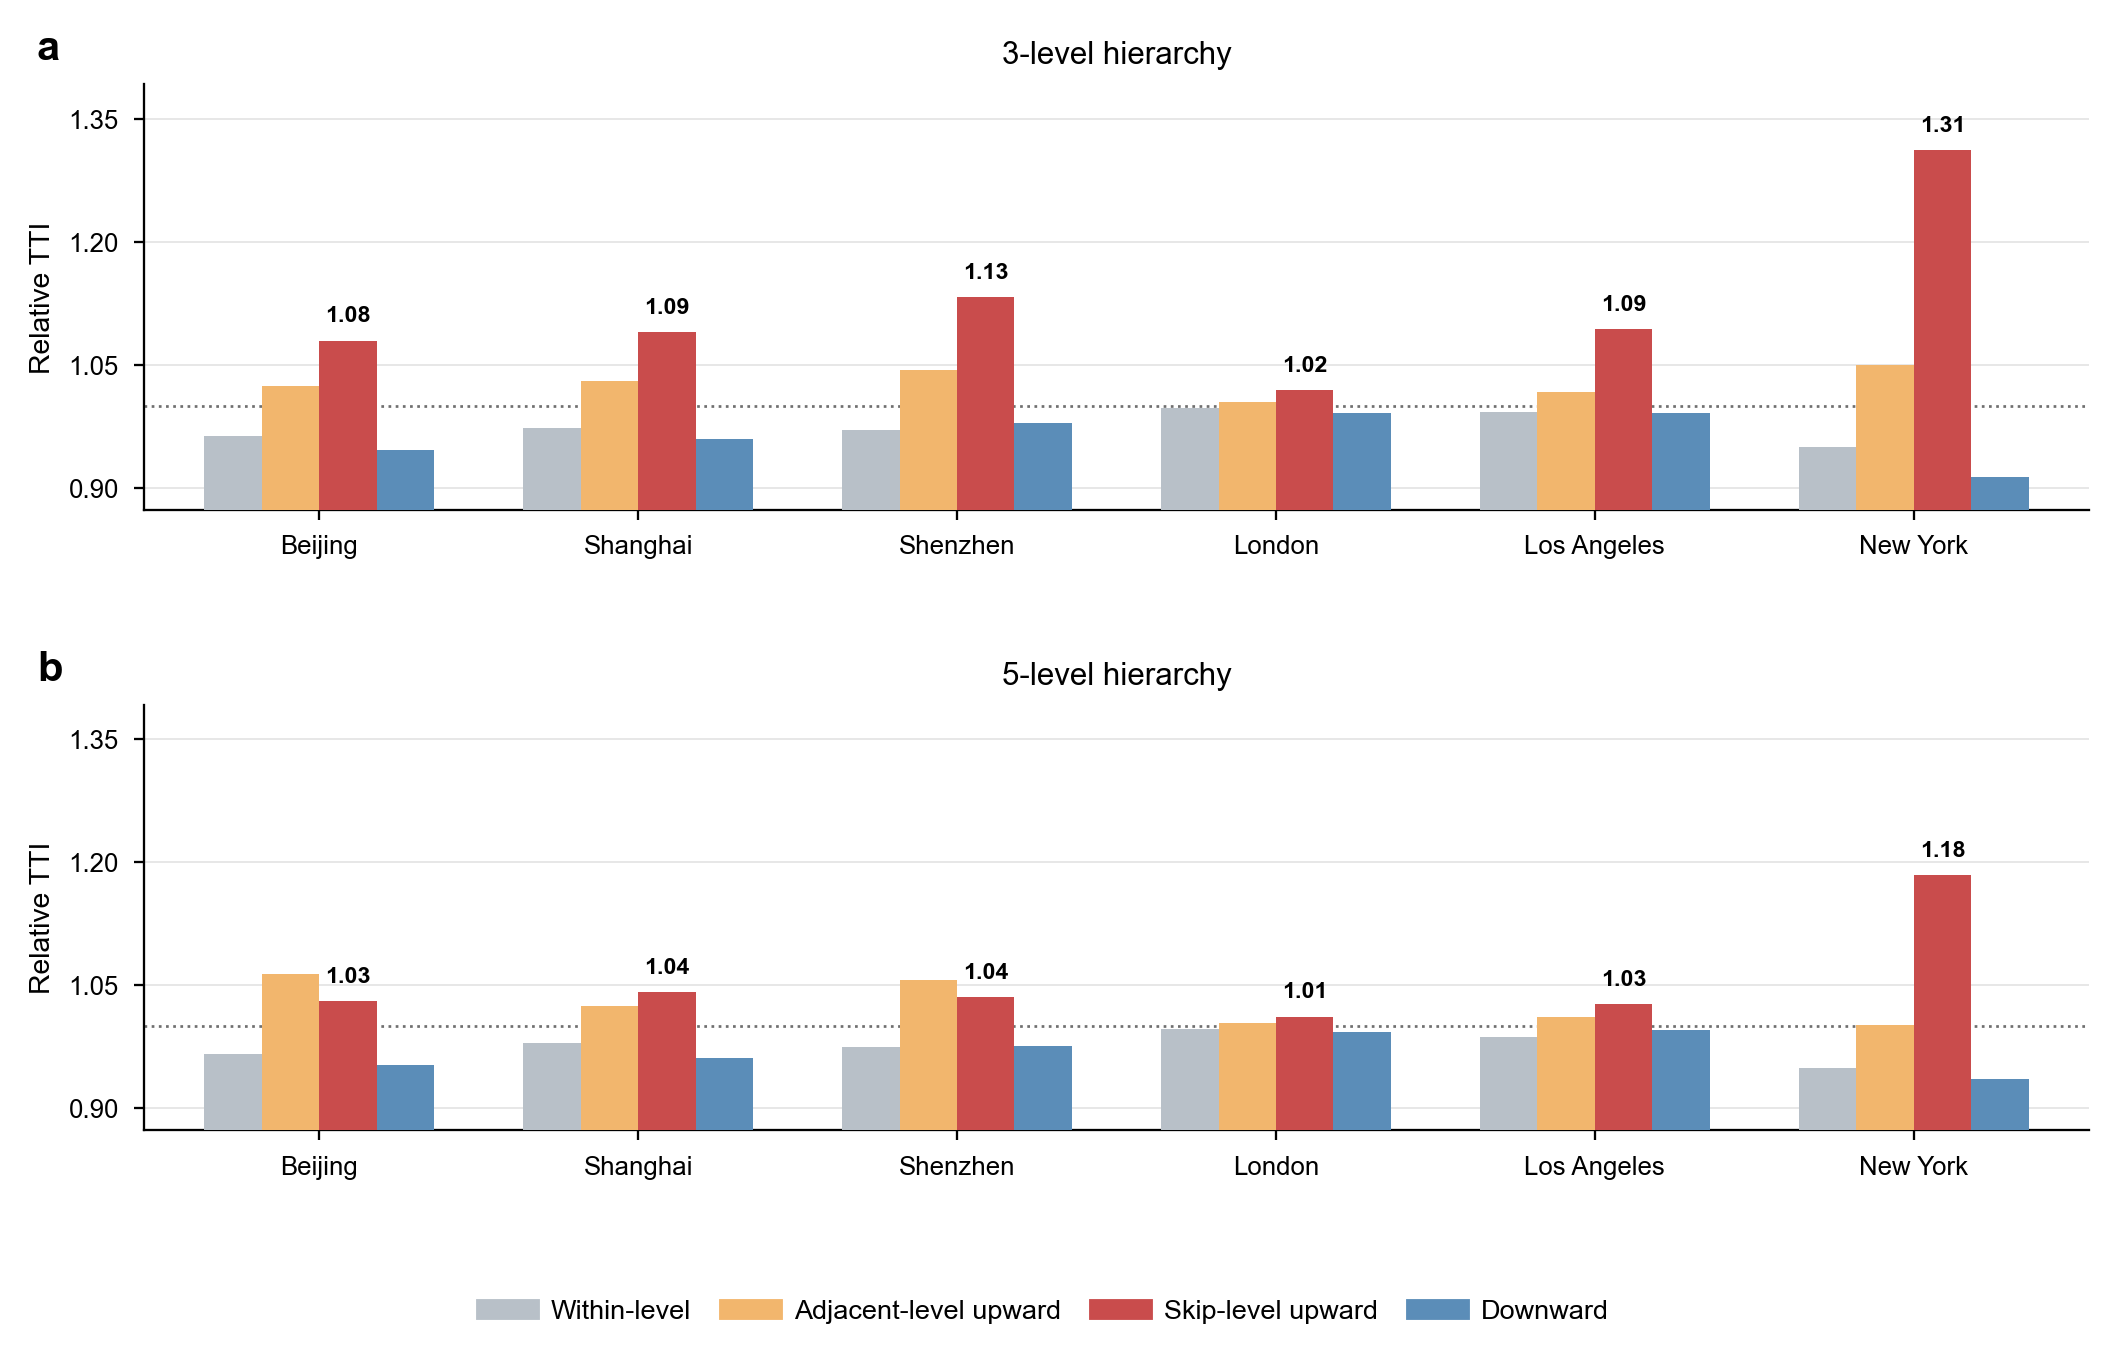

In [158]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator


SUMMARY_DIR = Path("results/summary_tables")
OUTPUT_PATH = Path("results/figures/Fig_S6_hierarchy_depth_congestion_intensity.jpg")

CITY_CONFIGS = [
    ("Beijing", "beijing"),
    ("Shanghai", "shanghai"),
    ("Shenzhen", "shenzhen"),
    ("London", "london"),
    ("Los Angeles", "losangeles"),
    ("New York", "newyork"),
]

DIRECTION_ORDER = [
    "Within-level",
    "Adjacent-level upward",
    "Skip-level upward",
    "Downward",
]

DIRECTION_COLORS = {
    "Within-level": "#B8C0C8",
    "Adjacent-level upward": "#F2B66D",
    "Skip-level upward": "#C94C4C",
    "Downward": "#5B8DB8",
}

FIGURE_WIDTH_CM = 18.0
FIGURE_HEIGHT_CM = 11.5
PANEL_LABEL_SIZE = 10.0
TITLE_SIZE = 7.5
AXIS_LABEL_SIZE = 6.8
TICK_LABEL_SIZE = 6.2
LEGEND_SIZE = 6.5


mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 6.5,
        "axes.linewidth": 0.55,
        "xtick.major.width": 0.55,
        "ytick.major.width": 0.55,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


def normalize_level(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.upper().str.extract(r"(\d+)", expand=False),
        errors="coerce",
    )


def classify_direction(origin_level: pd.Series, destination_level: pd.Series) -> np.ndarray:
    gap = origin_level - destination_level
    return np.select(
        [gap.eq(0), gap.eq(1), gap.ge(2), gap.lt(0)],
        DIRECTION_ORDER,
        default=None,
    )


def weighted_mean(values: pd.Series, weights: pd.Series) -> float:
    valid = values.notna() & weights.notna() & weights.gt(0)
    if not valid.any():
        return np.nan
    return float(np.average(values.loc[valid], weights=weights.loc[valid]))


def read_direction_summary(prefix: str, hierarchy_depth: int) -> pd.DataFrame:
    path = SUMMARY_DIR / f"{prefix}_level_od_{hierarchy_depth}_levels.csv"
    if not path.exists():
        raise FileNotFoundError(f"Required level-OD file not found: {path}")

    df = pd.read_csv(path)
    required = {"o_level", "d_level", "TTI", "flow"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    data = df.loc[:, list(required)].copy()
    data["o_level"] = normalize_level(data["o_level"])
    data["d_level"] = normalize_level(data["d_level"])
    data["TTI"] = pd.to_numeric(data["TTI"], errors="coerce")
    data["flow"] = pd.to_numeric(data["flow"], errors="coerce")
    data = data.dropna()
    data = data.loc[data["flow"].gt(0) & data["TTI"].gt(0)]
    data = data.loc[
        data["o_level"].between(1, hierarchy_depth)
        & data["d_level"].between(1, hierarchy_depth)
    ]

    if data.empty:
        raise ValueError(f"No valid level-OD observations were found in {path}.")

    citywide_tti = weighted_mean(data["TTI"], data["flow"])
    data["direction"] = classify_direction(data["o_level"], data["d_level"])

    rows = []
    for direction in DIRECTION_ORDER:
        subset = data.loc[data["direction"].eq(direction)]
        rows.append(
            {
                "direction": direction,
                "relative_tti": weighted_mean(subset["TTI"], subset["flow"]) / citywide_tti,
            }
        )
    return pd.DataFrame(rows)


def style_axis(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", direction="out", labelsize=TICK_LABEL_SIZE)
    ax.grid(axis="y", color="#E6E6E6", linewidth=0.45, zorder=0)
    ax.axhline(1.0, color="#6F6F6F", linestyle=":", linewidth=0.65, zorder=1)
    ax.set_axisbelow(True)


def create_figure() -> plt.Figure:
    summaries = {
        depth: {
            prefix: read_direction_summary(prefix, depth)
            for _, prefix in CITY_CONFIGS
        }
        for depth in (3, 5)
    }

    all_values = np.concatenate(
        [
            summaries[depth][prefix]["relative_tti"].dropna().to_numpy()
            for depth in (3, 5)
            for _, prefix in CITY_CONFIGS
        ]
    )
    y_min = min(0.90, float(all_values.min()) - 0.04)
    y_max = max(1.10, float(all_values.max()) + 0.08)

    figure, axes = plt.subplots(
        2,
        1,
        figsize=(FIGURE_WIDTH_CM / 2.54, FIGURE_HEIGHT_CM / 2.54),
        sharey=True,
    )
    x = np.arange(len(CITY_CONFIGS))
    width = 0.18
    offsets = np.arange(len(DIRECTION_ORDER)) - (len(DIRECTION_ORDER) - 1) / 2

    for panel_index, (ax, depth) in enumerate(zip(axes, (3, 5))):
        for direction_index, direction in enumerate(DIRECTION_ORDER):
            values = [
                summaries[depth][prefix]
                .set_index("direction")
                .loc[direction, "relative_tti"]
                for _, prefix in CITY_CONFIGS
            ]
            bars = ax.bar(
                x + offsets[direction_index] * width,
                values,
                width=width,
                color=DIRECTION_COLORS[direction],
                edgecolor="none",
                zorder=3,
            )
            if direction == "Skip-level upward":
                for bar, value in zip(bars, values):
                    if np.isfinite(value):
                        ax.text(
                            bar.get_x() + bar.get_width() / 2,
                            value + 0.018,
                            f"{value:.2f}",
                            ha="center",
                            va="bottom",
                            fontsize=5.6,
                            fontweight="bold",
                        )

        style_axis(ax)
        ax.set_xlim(-0.55, len(CITY_CONFIGS) - 0.45)
        ax.set_ylim(y_min, y_max)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.set_xticks(x, [name for name, _ in CITY_CONFIGS])
        ax.set_ylabel("Relative TTI", fontsize=AXIS_LABEL_SIZE, labelpad=3)
        ax.set_title(
            f"{depth}-level hierarchy",
            fontsize=TITLE_SIZE,
            pad=5,
        )
        ax.text(
            -0.055,
            1.04,
            chr(ord("a") + panel_index),
            transform=ax.transAxes,
            fontsize=PANEL_LABEL_SIZE,
            fontweight="bold",
            ha="left",
            va="bottom",
            clip_on=False,
        )

    legend_handles = [
        Line2D(
            [0],
            [0],
            color=DIRECTION_COLORS[direction],
            linewidth=5,
            label=direction,
        )
        for direction in DIRECTION_ORDER
    ]
    figure.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=4,
        frameon=False,
        fontsize=LEGEND_SIZE,
        handlelength=1.6,
        columnspacing=1.4,
    )
    figure.subplots_adjust(left=0.075, right=0.99, top=0.94, bottom=0.17, hspace=0.46)
    return figure


def main() -> None:
    figure = create_figure()
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        OUTPUT_PATH,
        dpi=600,
        format="jpg",
        bbox_inches="tight",
        pil_kwargs={"quality": 100, "subsampling": 0},
    )
    #plt.close(figure)
    print(f"Saved figure: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

## Fig.S7

Saved figure: results\figures\Fig_S7_three_level_diagnostic_experiments.jpg


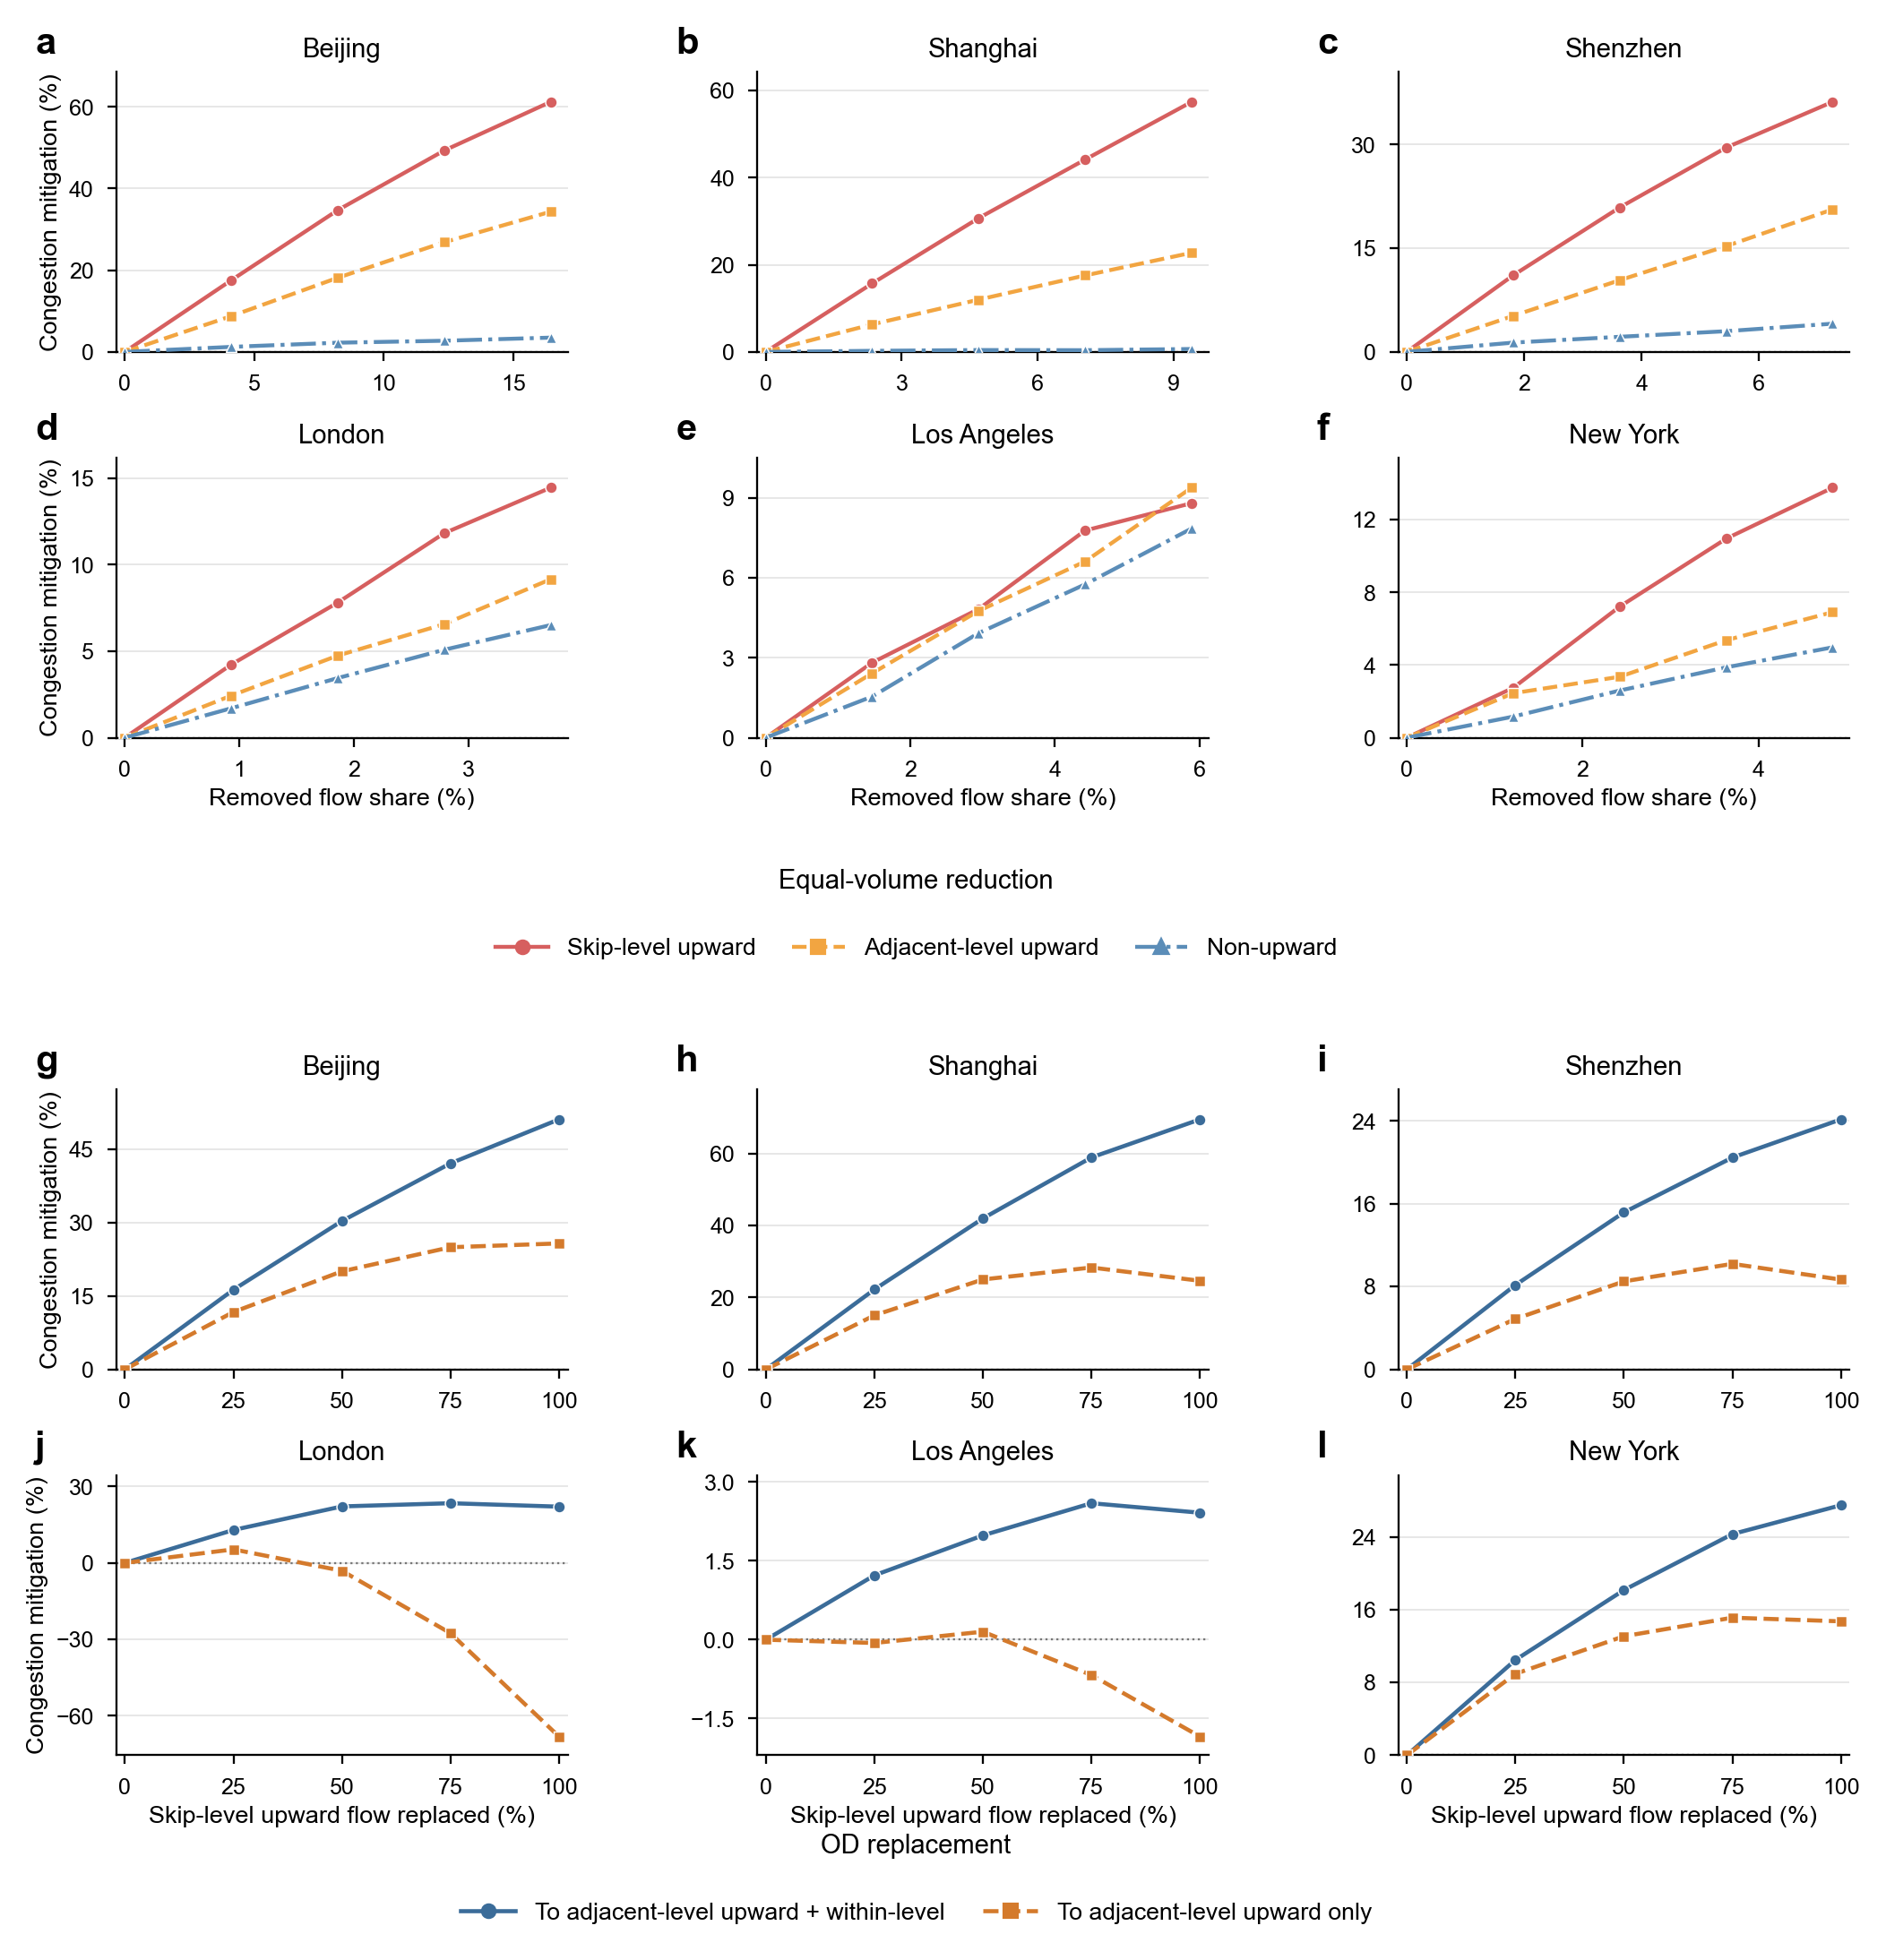

In [155]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, MaxNLocator, StrMethodFormatter


HIERARCHY_DEPTH = 3
EXPERIMENT_DIR = Path("results/traffic_assignment_results")
OUTPUT_PATH = Path("results/figures/Fig_S7_three_level_diagnostic_experiments.jpg")

CITY_CONFIGS = [
    ("Beijing", "beijing"),
    ("Shanghai", "shanghai"),
    ("Shenzhen", "shenzhen"),
    ("London", "london"),
    ("Los Angeles", "losangeles"),
    ("New York", "newyork"),
]

EQUAL_GROUP_ORDER = [
    "skip_level_upward",
    "adjacent_level_upward",
    "non_upward",
]

EQUAL_STYLES = {
    "skip_level_upward": {
        "label": "Skip-level upward",
        "color": "#D65F5F",
        "linestyle": "-",
        "marker": "o",
    },
    "adjacent_level_upward": {
        "label": "Adjacent-level upward",
        "color": "#F2A541",
        "linestyle": "--",
        "marker": "s",
    },
    "non_upward": {
        "label": "Non-upward",
        "color": "#5B8DB8",
        "linestyle": "-.",
        "marker": "^",
    },
}

REPLACEMENT_STYLES = {
    "adjacent_and_within": {
        "filename": "multi_to_adjacent_and_within_commuting_restructuring_results",
        "label": "To adjacent-level upward + within-level",
        "color": "#3B6C99",
        "linestyle": "-",
        "marker": "o",
    },
    "adjacent_only": {
        "filename": "multi_to_adjacent_commuting_restructuring_results",
        "label": "To adjacent-level upward only",
        "color": "#D47A2C",
        "linestyle": "--",
        "marker": "s",
    },
}

FIGURE_WIDTH_CM = 18.0
FIGURE_HEIGHT_CM = 18.5
PANEL_LABEL_SIZE = 10.0
TITLE_SIZE = 7.0
AXIS_LABEL_SIZE = 6.5
TICK_LABEL_SIZE = 6.0
LEGEND_SIZE = 6.4


mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 6.5,
        "axes.linewidth": 0.55,
        "xtick.major.width": 0.55,
        "ytick.major.width": 0.55,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


def normalize_group(value: str) -> str:
    group = str(value).strip().lower().replace("-", "_").replace(" ", "_")
    aliases = {
        "multi_level_upward": "skip_level_upward",
        "cross_level_upward": "skip_level_upward",
        "skip_level_upward": "skip_level_upward",
        "adjacent_upward": "adjacent_level_upward",
        "adjacent_level_upward": "adjacent_level_upward",
        "non_upward": "non_upward",
        "baseline": "baseline",
    }
    return aliases.get(group, group)


def to_percentage(series: pd.Series) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce")
    if values.dropna().abs().max() <= 1.000001:
        values = values * 100
    return values


def equal_flow_path(prefix: str) -> Path:
    return (
        EXPERIMENT_DIR
        / prefix
        / f"equal_flow_upward_commuting_results_{HIERARCHY_DEPTH}_levels.csv"
    )


def replacement_path(prefix: str, stem: str) -> Path:
    return EXPERIMENT_DIR / prefix / f"{stem}_{HIERARCHY_DEPTH}_levels.csv"


def read_equal_flow(prefix: str) -> dict[str, pd.DataFrame]:
    path = equal_flow_path(prefix)
    if not path.exists():
        raise FileNotFoundError(f"Required equal-volume experiment file not found: {path}")

    df = pd.read_csv(path)
    required = {"commuting_group", "removed_share_total", "TTI_excess_reduction_pct"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    data = df.loc[:, list(required)].copy()
    data["group"] = data["commuting_group"].map(normalize_group)
    data["x"] = to_percentage(data["removed_share_total"])
    data["y"] = pd.to_numeric(data["TTI_excess_reduction_pct"], errors="coerce")
    data = data.dropna(subset=["x", "y"])

    unexpected = sorted(set(data["group"]) - {"baseline", *EQUAL_GROUP_ORDER})
    if unexpected:
        raise ValueError(f"Unexpected commuting groups in {path}: {unexpected}")

    baseline = data.loc[data["group"].eq("baseline"), ["x", "y"]]
    baseline_point = baseline.iloc[[0]].copy() if not baseline.empty else pd.DataFrame({"x": [0.0], "y": [0.0]})

    output = {}
    for group in EQUAL_GROUP_ORDER:
        group_data = data.loc[data["group"].eq(group), ["x", "y"]].copy()
        if group_data.empty:
            raise ValueError(f"Missing commuting group '{group}' in {path}.")
        if not np.isclose(group_data["x"], baseline_point["x"].iloc[0]).any():
            group_data = pd.concat([baseline_point, group_data], ignore_index=True)
        output[group] = (
            group_data.sort_values("x")
            .drop_duplicates("x", keep="last")
            .reset_index(drop=True)
        )
    return output


def read_replacement(prefix: str, stem: str) -> pd.DataFrame:
    path = replacement_path(prefix, stem)
    if not path.exists():
        raise FileNotFoundError(f"Required OD-replacement file not found: {path}")

    df = pd.read_csv(path)
    required = {"redistribution_share", "TTI_excess_reduction_pct"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    data = df.loc[:, list(required)].copy()
    data["x"] = to_percentage(data["redistribution_share"])
    data["y"] = pd.to_numeric(data["TTI_excess_reduction_pct"], errors="coerce")
    data = data.dropna(subset=["x", "y"]).sort_values("x")
    data = data.drop_duplicates("x", keep="last").reset_index(drop=True)

    expected = np.arange(0, 101, 25)
    if len(data) != 5 or not np.allclose(data["x"], expected, atol=1e-6):
        raise ValueError(f"{path} must contain shares from 0% to 100% at 25% intervals.")
    return data


def style_axis(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", direction="out", labelsize=TICK_LABEL_SIZE)
    ax.grid(axis="y", color="#E6E6E6", linewidth=0.45, zorder=0)
    ax.axhline(0, color="#777777", linestyle=":", linewidth=0.55, zorder=1)
    ax.set_axisbelow(True)


def set_y_limits(ax: plt.Axes, values: np.ndarray) -> None:
    values = values[np.isfinite(values)]
    y_min = min(0.0, float(values.min()))
    y_max = max(0.0, float(values.max()))
    span = max(y_max - y_min, 1.0)
    lower = y_min - 0.08 * span if y_min < 0 else 0.0
    upper = y_max + 0.12 * span
    ax.set_ylim(lower, upper)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, min_n_ticks=3))


def add_panel_label(ax: plt.Axes, label: str) -> None:
    ax.text(
        -0.18,
        1.04,
        label,
        transform=ax.transAxes,
        fontsize=PANEL_LABEL_SIZE,
        fontweight="bold",
        ha="left",
        va="bottom",
        clip_on=False,
    )


def create_figure() -> plt.Figure:
    equal_data = {
        prefix: read_equal_flow(prefix)
        for _, prefix in CITY_CONFIGS
    }
    replacement_data = {
        prefix: {
            key: read_replacement(prefix, style["filename"])
            for key, style in REPLACEMENT_STYLES.items()
        }
        for _, prefix in CITY_CONFIGS
    }

    figure = plt.figure(
        figsize=(FIGURE_WIDTH_CM / 2.54, FIGURE_HEIGHT_CM / 2.54),
        facecolor="white",
    )
    grid = GridSpec(
        5,
        3,
        figure=figure,
        height_ratios=[1.0, 1.0, 0.50, 1.0, 1.0],
        hspace=0.42,
        wspace=0.42,
    )

    for index, (city_name, prefix) in enumerate(CITY_CONFIGS):
        row, column = divmod(index, 3)
        ax = figure.add_subplot(grid[row, column])
        city_data = equal_data[prefix]

        for group in EQUAL_GROUP_ORDER:
            style = EQUAL_STYLES[group]
            data = city_data[group]
            ax.plot(
                data["x"],
                data["y"],
                color=style["color"],
                linestyle=style["linestyle"],
                marker=style["marker"],
                linewidth=1.05,
                markersize=3.1,
                markeredgecolor="white",
                markeredgewidth=0.35,
                zorder=3,
            )

        all_x = np.concatenate([data["x"].to_numpy() for data in city_data.values()])
        all_y = np.concatenate([data["y"].to_numpy() for data in city_data.values()])
        x_max = max(float(np.nanmax(all_x)), 1.0)
        ax.set_xlim(-0.02 * x_max, 1.04 * x_max)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4, integer=True, min_n_ticks=3))
        ax.xaxis.set_major_formatter(StrMethodFormatter("{x:.0f}"))
        set_y_limits(ax, all_y)
        style_axis(ax)
        ax.set_title(city_name, fontsize=TITLE_SIZE, pad=4)

        if row == 1:
            ax.set_xlabel("Removed flow share (%)", fontsize=AXIS_LABEL_SIZE, labelpad=2)
        if column == 0:
            ax.set_ylabel("Congestion mitigation (%)", fontsize=AXIS_LABEL_SIZE, labelpad=2)
        add_panel_label(ax, chr(ord("a") + index))

    for index, (city_name, prefix) in enumerate(CITY_CONFIGS):
        row, column = divmod(index, 3)
        ax = figure.add_subplot(grid[row + 3, column])
        city_data = replacement_data[prefix]

        for key, style in REPLACEMENT_STYLES.items():
            data = city_data[key]
            ax.plot(
                data["x"],
                data["y"],
                color=style["color"],
                linestyle=style["linestyle"],
                marker=style["marker"],
                linewidth=1.1,
                markersize=3.1,
                markeredgecolor="white",
                markeredgewidth=0.35,
                zorder=3,
            )

        all_y = np.concatenate([data["y"].to_numpy() for data in city_data.values()])
        ax.set_xlim(-2, 102)
        ax.xaxis.set_major_locator(FixedLocator([0, 25, 50, 75, 100]))
        ax.xaxis.set_major_formatter(StrMethodFormatter("{x:.0f}"))
        set_y_limits(ax, all_y)
        style_axis(ax)
        ax.set_title(city_name, fontsize=TITLE_SIZE, pad=4)

        if row == 1:
            ax.set_xlabel(
                "Skip-level upward flow replaced (%)",
                fontsize=AXIS_LABEL_SIZE,
                labelpad=2,
            )
        if column == 0:
            ax.set_ylabel("Congestion mitigation (%)", fontsize=AXIS_LABEL_SIZE, labelpad=2)
        add_panel_label(ax, chr(ord("g") + index))

    equal_handles = [
        Line2D(
            [0],
            [0],
            color=EQUAL_STYLES[group]["color"],
            linestyle=EQUAL_STYLES[group]["linestyle"],
            marker=EQUAL_STYLES[group]["marker"],
            linewidth=1.05,
            markersize=3.2,
            label=EQUAL_STYLES[group]["label"],
        )
        for group in EQUAL_GROUP_ORDER
    ]
    replacement_handles = [
        Line2D(
            [0],
            [0],
            color=style["color"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            linewidth=1.1,
            markersize=3.2,
            label=style["label"],
        )
        for style in REPLACEMENT_STYLES.values()
    ]

    figure.text(0.5, 0.558, "Equal-volume reduction", ha="center", fontsize=7.0)
    figure.legend(
        handles=equal_handles,
        loc="center",
        bbox_to_anchor=(0.5, 0.527),
        ncol=3,
        frameon=False,
        fontsize=LEGEND_SIZE,
        handlelength=2.2,
        columnspacing=1.5,
    )
    figure.text(0.5, 0.065, "OD replacement", ha="center", fontsize=7.0)
    figure.legend(
        handles=replacement_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.018),
        ncol=2,
        frameon=False,
        fontsize=LEGEND_SIZE,
        handlelength=2.3,
        columnspacing=1.6,
    )
    figure.subplots_adjust(left=0.08, right=0.99, top=0.975, bottom=0.115)
    return figure


def main() -> None:
    figure = create_figure()
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        OUTPUT_PATH,
        dpi=600,
        format="jpg",
        bbox_inches="tight",
        pil_kwargs={"quality": 100, "subsampling": 0},
    )
    #plt.close(figure)
    print(f"Saved figure: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

## Fig.S8

Saved figure: results\figures\Fig_S8_five_level_diagnostic_experiments.jpg


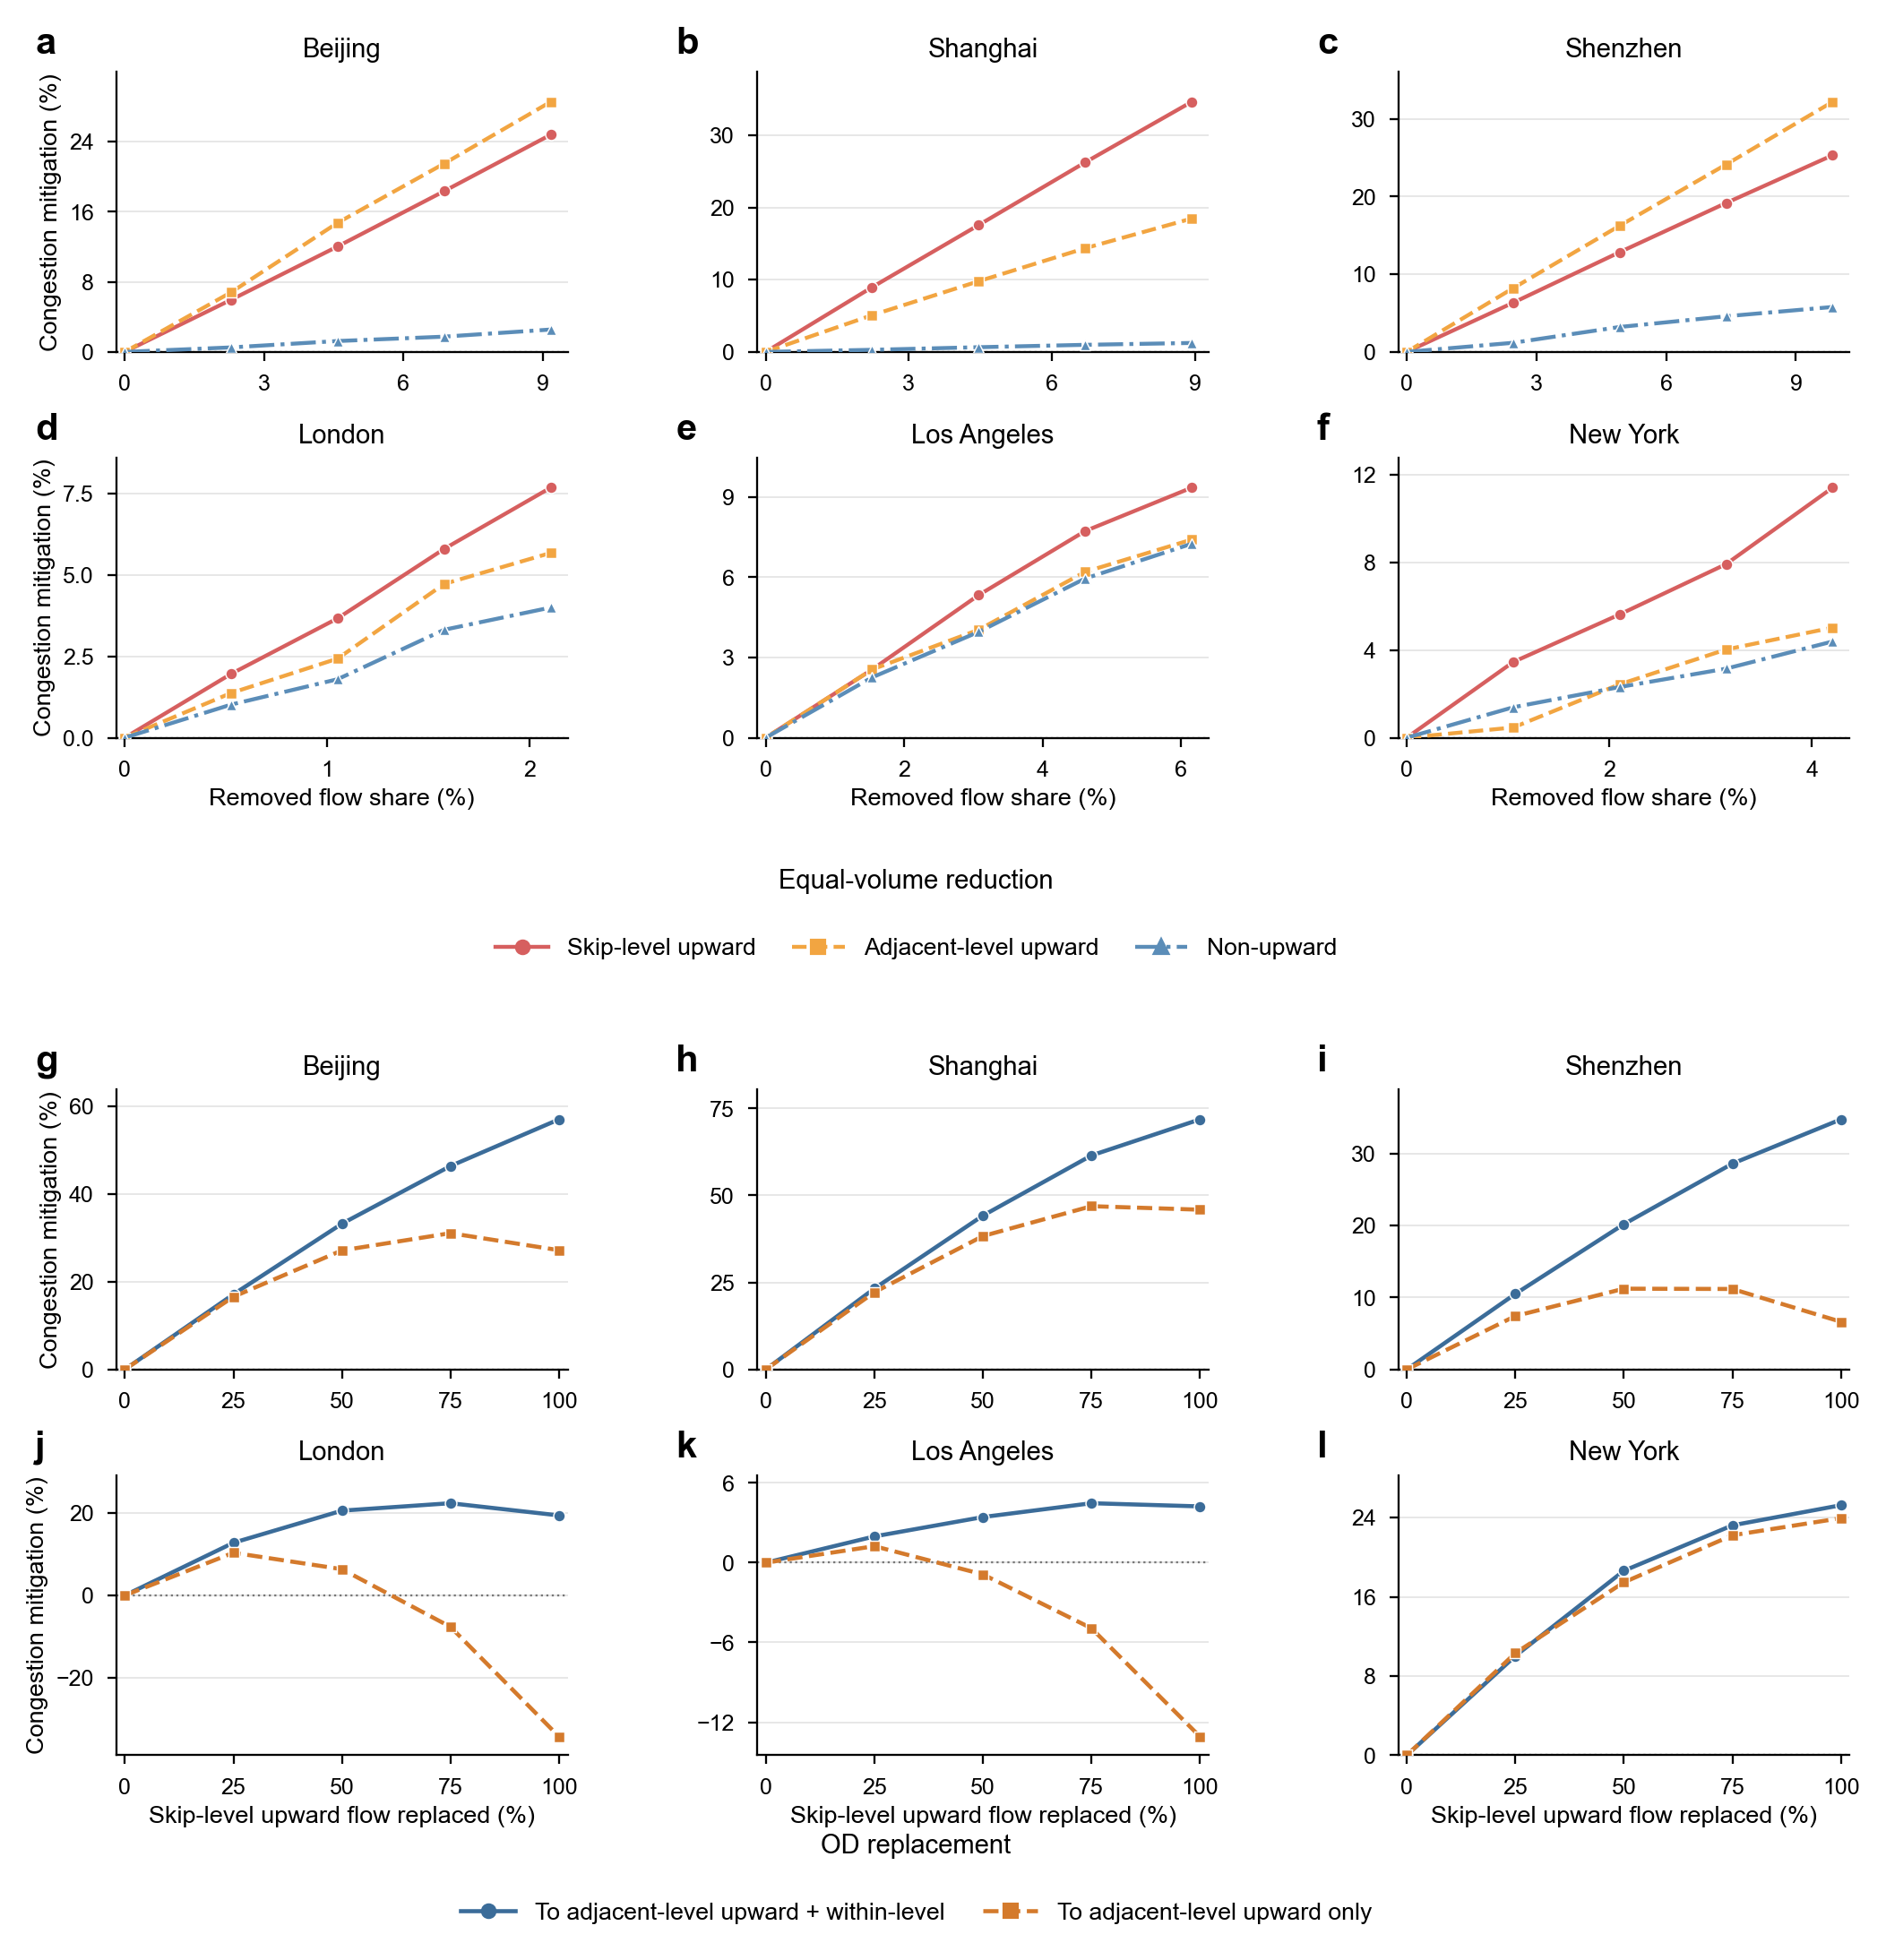

In [157]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, MaxNLocator, StrMethodFormatter


HIERARCHY_DEPTH = 5
EXPERIMENT_DIR = Path("results/traffic_assignment_results")
OUTPUT_PATH = Path("results/figures/Fig_S8_five_level_diagnostic_experiments.jpg")

CITY_CONFIGS = [
    ("Beijing", "beijing"),
    ("Shanghai", "shanghai"),
    ("Shenzhen", "shenzhen"),
    ("London", "london"),
    ("Los Angeles", "losangeles"),
    ("New York", "newyork"),
]

EQUAL_GROUP_ORDER = [
    "skip_level_upward",
    "adjacent_level_upward",
    "non_upward",
]

EQUAL_STYLES = {
    "skip_level_upward": {
        "label": "Skip-level upward",
        "color": "#D65F5F",
        "linestyle": "-",
        "marker": "o",
    },
    "adjacent_level_upward": {
        "label": "Adjacent-level upward",
        "color": "#F2A541",
        "linestyle": "--",
        "marker": "s",
    },
    "non_upward": {
        "label": "Non-upward",
        "color": "#5B8DB8",
        "linestyle": "-.",
        "marker": "^",
    },
}

REPLACEMENT_STYLES = {
    "adjacent_and_within": {
        "filename": "multi_to_adjacent_and_within_commuting_restructuring_results",
        "label": "To adjacent-level upward + within-level",
        "color": "#3B6C99",
        "linestyle": "-",
        "marker": "o",
    },
    "adjacent_only": {
        "filename": "multi_to_adjacent_commuting_restructuring_results",
        "label": "To adjacent-level upward only",
        "color": "#D47A2C",
        "linestyle": "--",
        "marker": "s",
    },
}

FIGURE_WIDTH_CM = 18.0
FIGURE_HEIGHT_CM = 18.5
PANEL_LABEL_SIZE = 10.0
TITLE_SIZE = 7.0
AXIS_LABEL_SIZE = 6.5
TICK_LABEL_SIZE = 6.0
LEGEND_SIZE = 6.4


mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 6.5,
        "axes.linewidth": 0.55,
        "xtick.major.width": 0.55,
        "ytick.major.width": 0.55,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


def normalize_group(value: str) -> str:
    group = str(value).strip().lower().replace("-", "_").replace(" ", "_")
    aliases = {
        "multi_level_upward": "skip_level_upward",
        "cross_level_upward": "skip_level_upward",
        "skip_level_upward": "skip_level_upward",
        "adjacent_upward": "adjacent_level_upward",
        "adjacent_level_upward": "adjacent_level_upward",
        "non_upward": "non_upward",
        "baseline": "baseline",
    }
    return aliases.get(group, group)


def to_percentage(series: pd.Series) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce")
    if values.dropna().abs().max() <= 1.000001:
        values = values * 100
    return values


def equal_flow_path(prefix: str) -> Path:
    return (
        EXPERIMENT_DIR
        / prefix
        / f"equal_flow_upward_commuting_results_{HIERARCHY_DEPTH}_levels.csv"
    )


def replacement_path(prefix: str, stem: str) -> Path:
    return EXPERIMENT_DIR / prefix / f"{stem}_{HIERARCHY_DEPTH}_levels.csv"


def read_equal_flow(prefix: str) -> dict[str, pd.DataFrame]:
    path = equal_flow_path(prefix)
    if not path.exists():
        raise FileNotFoundError(f"Required equal-volume experiment file not found: {path}")

    df = pd.read_csv(path)
    required = {"commuting_group", "removed_share_total", "TTI_excess_reduction_pct"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    data = df.loc[:, list(required)].copy()
    data["group"] = data["commuting_group"].map(normalize_group)
    data["x"] = to_percentage(data["removed_share_total"])
    data["y"] = pd.to_numeric(data["TTI_excess_reduction_pct"], errors="coerce")
    data = data.dropna(subset=["x", "y"])

    unexpected = sorted(set(data["group"]) - {"baseline", *EQUAL_GROUP_ORDER})
    if unexpected:
        raise ValueError(f"Unexpected commuting groups in {path}: {unexpected}")

    baseline = data.loc[data["group"].eq("baseline"), ["x", "y"]]
    baseline_point = baseline.iloc[[0]].copy() if not baseline.empty else pd.DataFrame({"x": [0.0], "y": [0.0]})

    output = {}
    for group in EQUAL_GROUP_ORDER:
        group_data = data.loc[data["group"].eq(group), ["x", "y"]].copy()
        if group_data.empty:
            raise ValueError(f"Missing commuting group '{group}' in {path}.")
        if not np.isclose(group_data["x"], baseline_point["x"].iloc[0]).any():
            group_data = pd.concat([baseline_point, group_data], ignore_index=True)
        output[group] = (
            group_data.sort_values("x")
            .drop_duplicates("x", keep="last")
            .reset_index(drop=True)
        )
    return output


def read_replacement(prefix: str, stem: str) -> pd.DataFrame:
    path = replacement_path(prefix, stem)
    if not path.exists():
        raise FileNotFoundError(f"Required OD-replacement file not found: {path}")

    df = pd.read_csv(path)
    required = {"redistribution_share", "TTI_excess_reduction_pct"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    data = df.loc[:, list(required)].copy()
    data["x"] = to_percentage(data["redistribution_share"])
    data["y"] = pd.to_numeric(data["TTI_excess_reduction_pct"], errors="coerce")
    data = data.dropna(subset=["x", "y"]).sort_values("x")
    data = data.drop_duplicates("x", keep="last").reset_index(drop=True)

    expected = np.arange(0, 101, 25)
    if len(data) != 5 or not np.allclose(data["x"], expected, atol=1e-6):
        raise ValueError(f"{path} must contain shares from 0% to 100% at 25% intervals.")
    return data


def style_axis(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", direction="out", labelsize=TICK_LABEL_SIZE)
    ax.grid(axis="y", color="#E6E6E6", linewidth=0.45, zorder=0)
    ax.axhline(0, color="#777777", linestyle=":", linewidth=0.55, zorder=1)
    ax.set_axisbelow(True)


def set_y_limits(ax: plt.Axes, values: np.ndarray) -> None:
    values = values[np.isfinite(values)]
    y_min = min(0.0, float(values.min()))
    y_max = max(0.0, float(values.max()))
    span = max(y_max - y_min, 1.0)
    lower = y_min - 0.08 * span if y_min < 0 else 0.0
    upper = y_max + 0.12 * span
    ax.set_ylim(lower, upper)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, min_n_ticks=3))


def add_panel_label(ax: plt.Axes, label: str) -> None:
    ax.text(
        -0.18,
        1.04,
        label,
        transform=ax.transAxes,
        fontsize=PANEL_LABEL_SIZE,
        fontweight="bold",
        ha="left",
        va="bottom",
        clip_on=False,
    )


def create_figure() -> plt.Figure:
    equal_data = {
        prefix: read_equal_flow(prefix)
        for _, prefix in CITY_CONFIGS
    }
    replacement_data = {
        prefix: {
            key: read_replacement(prefix, style["filename"])
            for key, style in REPLACEMENT_STYLES.items()
        }
        for _, prefix in CITY_CONFIGS
    }

    figure = plt.figure(
        figsize=(FIGURE_WIDTH_CM / 2.54, FIGURE_HEIGHT_CM / 2.54),
        facecolor="white",
    )
    grid = GridSpec(
        5,
        3,
        figure=figure,
        height_ratios=[1.0, 1.0, 0.50, 1.0, 1.0],
        hspace=0.42,
        wspace=0.42,
    )

    for index, (city_name, prefix) in enumerate(CITY_CONFIGS):
        row, column = divmod(index, 3)
        ax = figure.add_subplot(grid[row, column])
        city_data = equal_data[prefix]

        for group in EQUAL_GROUP_ORDER:
            style = EQUAL_STYLES[group]
            data = city_data[group]
            ax.plot(
                data["x"],
                data["y"],
                color=style["color"],
                linestyle=style["linestyle"],
                marker=style["marker"],
                linewidth=1.05,
                markersize=3.1,
                markeredgecolor="white",
                markeredgewidth=0.35,
                zorder=3,
            )

        all_x = np.concatenate([data["x"].to_numpy() for data in city_data.values()])
        all_y = np.concatenate([data["y"].to_numpy() for data in city_data.values()])
        x_max = max(float(np.nanmax(all_x)), 1.0)
        ax.set_xlim(-0.02 * x_max, 1.04 * x_max)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4, integer=True, min_n_ticks=3))
        ax.xaxis.set_major_formatter(StrMethodFormatter("{x:.0f}"))
        set_y_limits(ax, all_y)
        style_axis(ax)
        ax.set_title(city_name, fontsize=TITLE_SIZE, pad=4)

        if row == 1:
            ax.set_xlabel("Removed flow share (%)", fontsize=AXIS_LABEL_SIZE, labelpad=2)
        if column == 0:
            ax.set_ylabel("Congestion mitigation (%)", fontsize=AXIS_LABEL_SIZE, labelpad=2)
        add_panel_label(ax, chr(ord("a") + index))

    for index, (city_name, prefix) in enumerate(CITY_CONFIGS):
        row, column = divmod(index, 3)
        ax = figure.add_subplot(grid[row + 3, column])
        city_data = replacement_data[prefix]

        for key, style in REPLACEMENT_STYLES.items():
            data = city_data[key]
            ax.plot(
                data["x"],
                data["y"],
                color=style["color"],
                linestyle=style["linestyle"],
                marker=style["marker"],
                linewidth=1.1,
                markersize=3.1,
                markeredgecolor="white",
                markeredgewidth=0.35,
                zorder=3,
            )

        all_y = np.concatenate([data["y"].to_numpy() for data in city_data.values()])
        ax.set_xlim(-2, 102)
        ax.xaxis.set_major_locator(FixedLocator([0, 25, 50, 75, 100]))
        ax.xaxis.set_major_formatter(StrMethodFormatter("{x:.0f}"))
        set_y_limits(ax, all_y)
        style_axis(ax)
        ax.set_title(city_name, fontsize=TITLE_SIZE, pad=4)

        if row == 1:
            ax.set_xlabel(
                "Skip-level upward flow replaced (%)",
                fontsize=AXIS_LABEL_SIZE,
                labelpad=2,
            )
        if column == 0:
            ax.set_ylabel("Congestion mitigation (%)", fontsize=AXIS_LABEL_SIZE, labelpad=2)
        add_panel_label(ax, chr(ord("g") + index))

    equal_handles = [
        Line2D(
            [0],
            [0],
            color=EQUAL_STYLES[group]["color"],
            linestyle=EQUAL_STYLES[group]["linestyle"],
            marker=EQUAL_STYLES[group]["marker"],
            linewidth=1.05,
            markersize=3.2,
            label=EQUAL_STYLES[group]["label"],
        )
        for group in EQUAL_GROUP_ORDER
    ]
    replacement_handles = [
        Line2D(
            [0],
            [0],
            color=style["color"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            linewidth=1.1,
            markersize=3.2,
            label=style["label"],
        )
        for style in REPLACEMENT_STYLES.values()
    ]

    figure.text(0.5, 0.558, "Equal-volume reduction", ha="center", fontsize=7.0)
    figure.legend(
        handles=equal_handles,
        loc="center",
        bbox_to_anchor=(0.5, 0.527),
        ncol=3,
        frameon=False,
        fontsize=LEGEND_SIZE,
        handlelength=2.2,
        columnspacing=1.5,
    )
    figure.text(0.5, 0.065, "OD replacement", ha="center", fontsize=7.0)
    figure.legend(
        handles=replacement_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.018),
        ncol=2,
        frameon=False,
        fontsize=LEGEND_SIZE,
        handlelength=2.3,
        columnspacing=1.6,
    )
    figure.subplots_adjust(left=0.08, right=0.99, top=0.975, bottom=0.115)
    return figure


def main() -> None:
    figure = create_figure()
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        OUTPUT_PATH,
        dpi=600,
        format="jpg",
        bbox_inches="tight",
        pil_kwargs={"quality": 100, "subsampling": 0},
    )
    #plt.close(figure)
    print(f"Saved figure: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

## Table S7

In [80]:
from pathlib import Path

import pandas as pd


RESULTS_DIR = Path("results/traffic_assignment_results")
OUTPUT_PATH = Path(
    "results/figures/Table_S7_sensitivity_maximum_mitigation.csv"
)

CITIES = {
    "Beijing": "beijing",
    "Shanghai": "shanghai",
    "Shenzhen": "shenzhen",
    "London": "london",
    "Los Angeles": "losangeles",
    "New York": "newyork",
}

PARAMETER_SETTINGS = {
    "β = 0.8β": "scenario_simulation_results_final_beta_0.8.csv",
    "φ = 0.5": "scenario_simulation_results_final_phi_0.5.csv",
}

LEVEL_BY_LEVEL = ["L1_to_L2", "L2_to_L3", "L3_to_L4"]
SKIP_LEVEL = ["L1_to_L3", "L1_to_L4"]
SCENARIO_ORDER = LEVEL_BY_LEVEL + SKIP_LEVEL

OUTPUT_COLUMNS = [
    "Parameter setting",
    "City",
    "Redistribution pathway",
    "Maximum-mitigation configuration",
    "Congestion mitigation (%)",
    "Travel-time reduction (%)",
    "Congestion-related CO2 reduction (%)",
    "Agglomeration-potential loss (%)",
]


def read_results(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Result file not found: {path}")

    df = pd.read_csv(path, encoding="utf-8-sig")
    required = {
        "scenario",
        "prop",
        "congestion_mitigation_pct",
        "TTT",
        "CO2_excess_reduction_pct",
        "AGG_loss_pct",
    }
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    df = df.loc[:, list(required)].copy()
    df["scenario"] = df["scenario"].astype(str).str.strip()

    numeric_columns = required.difference({"scenario"})
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    expected_scenarios = {"baseline", *SCENARIO_ORDER}
    missing_scenarios = expected_scenarios.difference(df["scenario"])
    if missing_scenarios:
        raise ValueError(
            f"{path} is missing scenarios: {sorted(missing_scenarios)}"
        )

    if (
        df.loc[df["scenario"].isin(SCENARIO_ORDER), list(required)]
        .isna()
        .any()
        .any()
    ):
        raise ValueError(f"Scenario rows contain missing values: {path}")

    return df


def select_maximum(df: pd.DataFrame, scenarios: list[str]) -> pd.Series:
    scenario_rank = {
        scenario: index for index, scenario in enumerate(SCENARIO_ORDER)
    }
    candidates = df.loc[df["scenario"].isin(scenarios)].copy()
    candidates["scenario_rank"] = candidates["scenario"].map(scenario_rank)

    return candidates.sort_values(
        ["congestion_mitigation_pct", "prop", "scenario_rank"],
        ascending=[False, True, True],
    ).iloc[0]


def scenario_label(scenario: str) -> str:
    return scenario.replace("_to_", " to ")


def share_label(prop: float) -> str:
    return f"{prop * 100:.0f}%"


def level_by_level_configuration(
    df: pd.DataFrame, terminal_row: pd.Series
) -> str:
    terminal_scenario = terminal_row["scenario"]
    terminal_index = LEVEL_BY_LEVEL.index(terminal_scenario)
    stages = LEVEL_BY_LEVEL[: terminal_index + 1]
    labels = []

    for stage in stages:
        row = (
            terminal_row
            if stage == terminal_scenario
            else select_maximum(df, [stage])
        )
        labels.append(
            f"{scenario_label(stage)} ({share_label(row['prop'])})"
        )

    return " → ".join(labels)


def make_row(
    parameter_setting: str,
    city: str,
    pathway: str,
    optimum: pd.Series,
    baseline_ttt: float,
    configuration: str,
) -> dict:
    travel_time_reduction = (
        (baseline_ttt - optimum["TTT"]) / baseline_ttt * 100
    )

    return {
        "Parameter setting": parameter_setting,
        "City": city,
        "Redistribution pathway": pathway,
        "Maximum-mitigation configuration": configuration,
        "Congestion mitigation (%)": optimum["congestion_mitigation_pct"],
        "Travel-time reduction (%)": travel_time_reduction,
        "Congestion-related CO2 reduction (%)": optimum[
            "CO2_excess_reduction_pct"
        ],
        "Agglomeration-potential loss (%)": optimum["AGG_loss_pct"],
    }


def build_table() -> pd.DataFrame:
    rows = []

    for parameter_setting, filename in PARAMETER_SETTINGS.items():
        for city, city_folder in CITIES.items():
            path = RESULTS_DIR / city_folder / filename
            df = read_results(path)

            baseline_ttt_values = (
                df.loc[df["scenario"] == "baseline", "TTT"]
                .dropna()
                .unique()
            )
            if len(baseline_ttt_values) != 1 or baseline_ttt_values[0] <= 0:
                raise ValueError(
                    f"A single positive baseline TTT is required in {path}"
                )
            baseline_ttt = float(baseline_ttt_values[0])

            level_optimum = select_maximum(df, LEVEL_BY_LEVEL)
            rows.append(
                make_row(
                    parameter_setting,
                    city,
                    "Level-by-level",
                    level_optimum,
                    baseline_ttt,
                    level_by_level_configuration(df, level_optimum),
                )
            )

            skip_optimum = select_maximum(df, SKIP_LEVEL)
            skip_configuration = (
                f"{scenario_label(skip_optimum['scenario'])} "
                f"({share_label(skip_optimum['prop'])})"
            )
            rows.append(
                make_row(
                    parameter_setting,
                    city,
                    "Skip-level",
                    skip_optimum,
                    baseline_ttt,
                    skip_configuration,
                )
            )

    table = pd.DataFrame(rows, columns=OUTPUT_COLUMNS)
    numeric_columns = OUTPUT_COLUMNS[4:]
    table[numeric_columns] = table[numeric_columns].round(2)
    return table


def main():
    table = build_table()
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    table.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
    print(f"Saved table: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

Saved table: results\figures\Table_S7_sensitivity_maximum_mitigation.csv


## Fig.S9

Saved: results\figures\Fig_S9_agglomeration_decay_sensitivity.jpg


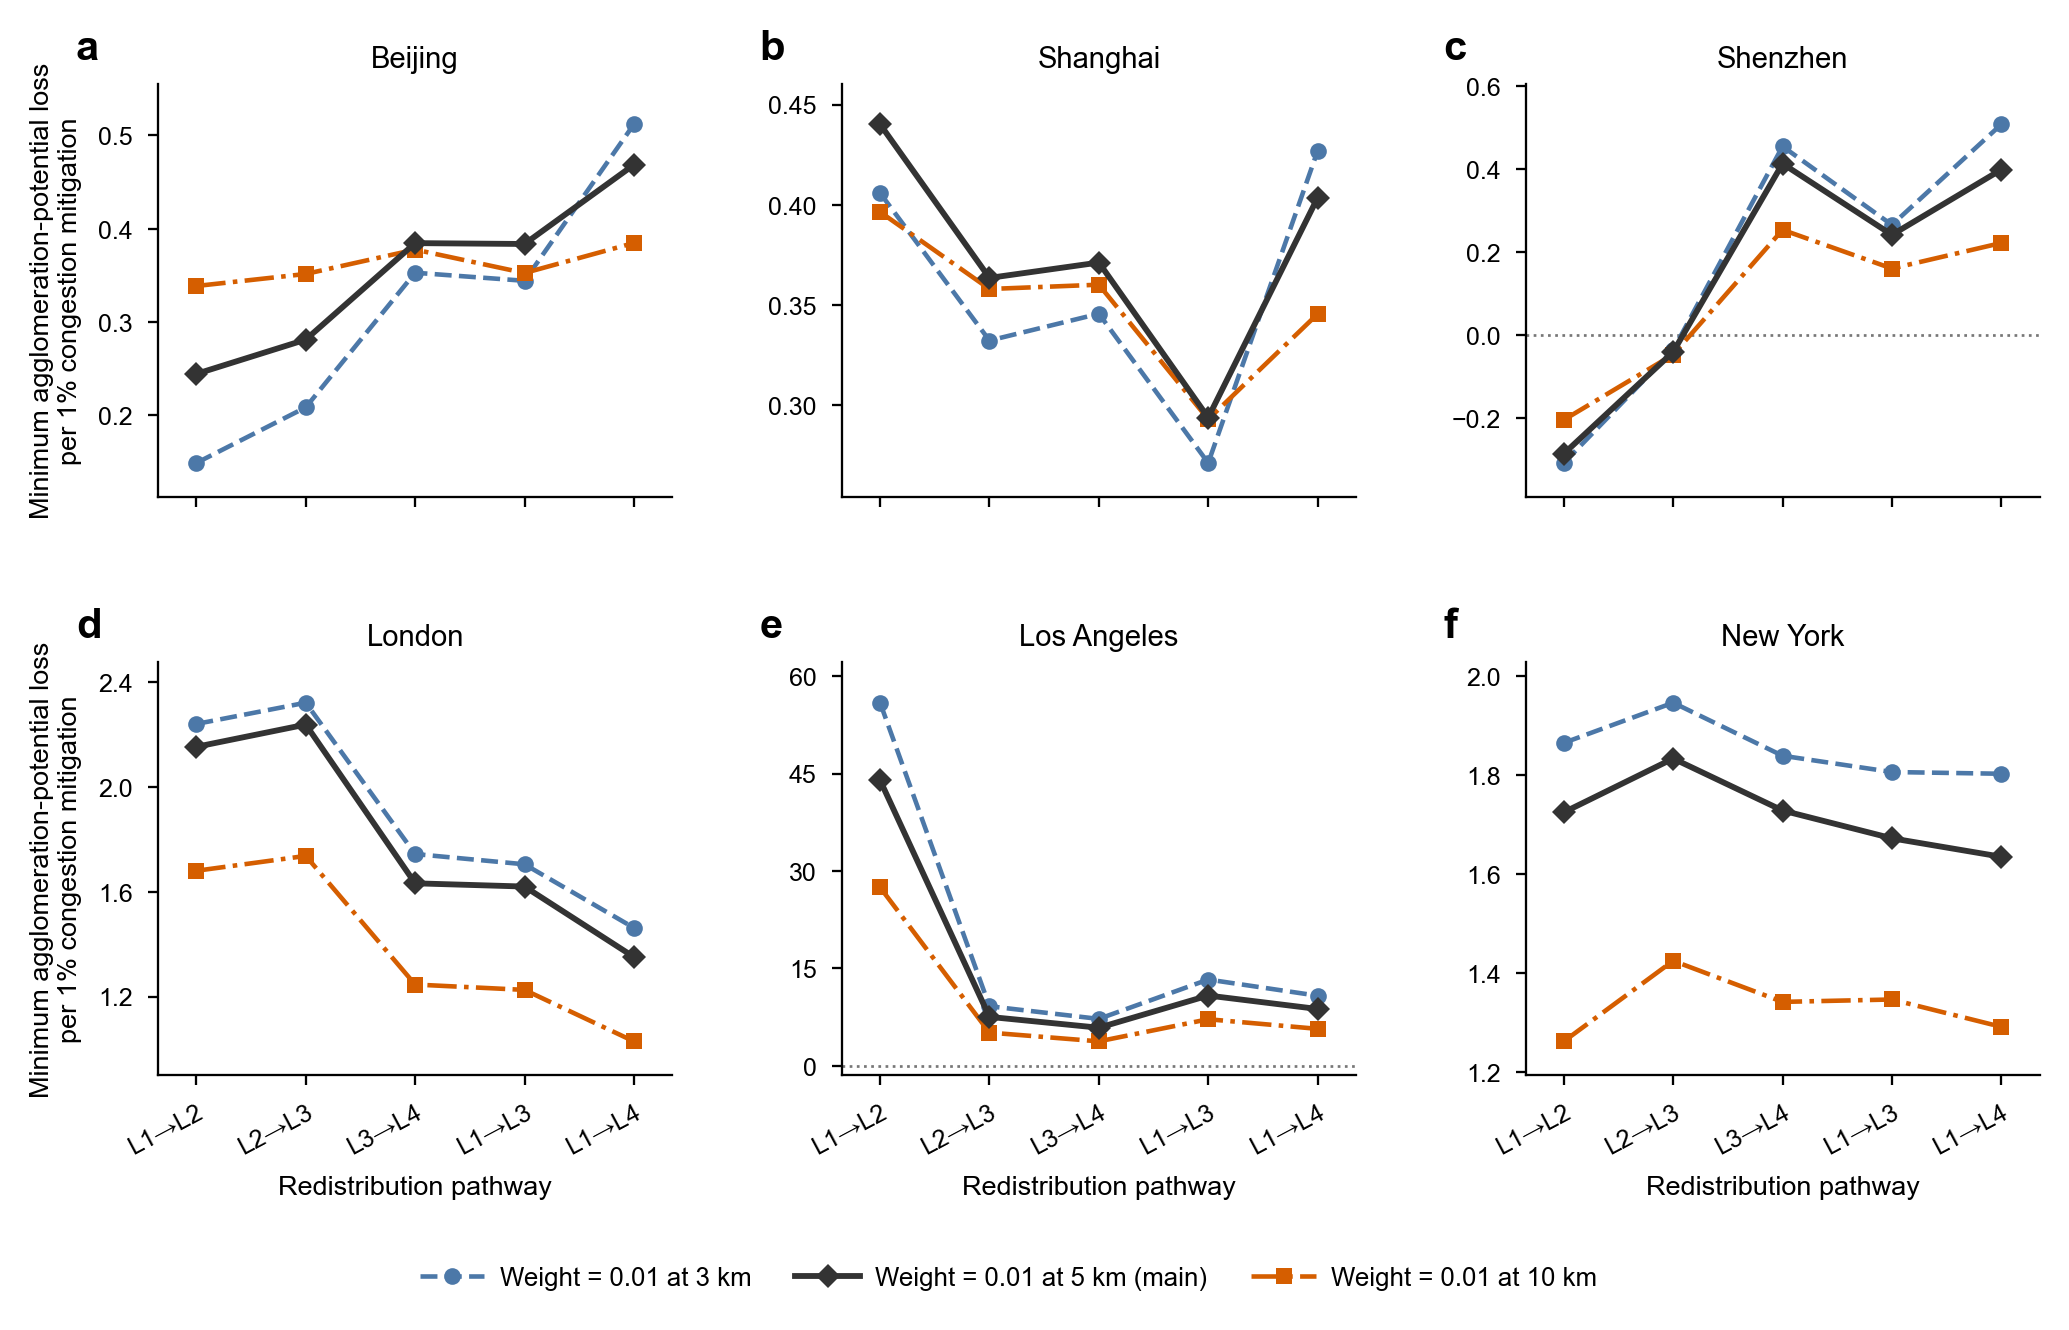

In [146]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator


RESULTS_DIR = Path("results/traffic_assignment_results")
OUTPUT_PATH = Path(
    "results/figures/Fig_S9_agglomeration_decay_sensitivity.jpg"
)

CITY_CONFIGS = [
    ("Beijing", "beijing"),
    ("Shanghai", "shanghai"),
    ("Shenzhen", "shenzhen"),
    ("London", "london"),
    ("Los Angeles", "losangeles"),
    ("New York", "newyork"),
]

SCENARIOS = [
    "L1_to_L2",
    "L2_to_L3",
    "L3_to_L4",
    "L1_to_L3",
    "L1_to_L4",
]

SCENARIO_LABELS = ["L1→L2", "L2→L3", "L3→L4", "L1→L3", "L1→L4"]

DECAY_SETTINGS = {
    "3 km": {
        "agg_field": "AGG_exp_3km_w0.01",
        "loss_field": None,
        "color": "#4C78A8",
        "linestyle": "--",
        "marker": "o",
        "linewidth": 1.1,
        "label": "Weight = 0.01 at 3 km",
    },
    "5 km": {
        "agg_field": None,
        "loss_field": "AGG_loss_pct",
        "color": "#333333",
        "linestyle": "-",
        "marker": "D",
        "linewidth": 1.4,
        "label": "Weight = 0.01 at 5 km (main)",
    },
    "10 km": {
        "agg_field": "AGG_exp_10km_w0.01",
        "loss_field": None,
        "color": "#D55E00",
        "linestyle": "-.",
        "marker": "s",
        "linewidth": 1.1,
        "label": "Weight = 0.01 at 10 km",
    },
}

mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 6.5,
        "axes.linewidth": 0.55,
        "xtick.major.width": 0.55,
        "ytick.major.width": 0.55,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


def read_city_results(prefix):
    path = RESULTS_DIR / prefix / "scenario_simulation_results_final.csv"
    if not path.exists():
        raise FileNotFoundError(f"Required result file not found: {path}")

    agg_fields = [
        setting["agg_field"]
        for setting in DECAY_SETTINGS.values()
        if setting["agg_field"] is not None
    ]
    loss_fields = [
        setting["loss_field"]
        for setting in DECAY_SETTINGS.values()
        if setting["loss_field"] is not None
    ]
    required = {
        "scenario",
        "prop",
        "congestion_mitigation_pct",
        *agg_fields,
        *loss_fields,
    }

    data = pd.read_csv(path, encoding="utf-8-sig")
    missing = required.difference(data.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    data = data.loc[:, list(required)].copy()
    data["scenario"] = data["scenario"].astype(str).str.strip()

    numeric_columns = [
        "prop",
        "congestion_mitigation_pct",
        *agg_fields,
        *loss_fields,
    ]
    data[numeric_columns] = data[numeric_columns].apply(
        pd.to_numeric, errors="coerce"
    )

    expected = {"baseline", *SCENARIOS}
    missing_scenarios = expected.difference(data["scenario"])
    if missing_scenarios:
        raise ValueError(
            f"Missing scenarios in {path}: {sorted(missing_scenarios)}"
        )

    scenario_rows = data.loc[data["scenario"].isin(SCENARIOS)].copy()
    if scenario_rows[numeric_columns].isna().any().any():
        raise ValueError(f"{path} contains missing or non-numeric values")

    for distance, setting in DECAY_SETTINGS.items():
        loss_column = f"agg_loss_{distance}"
        cost_column = f"unit_cost_{distance}"

        if setting["loss_field"] is not None:
            scenario_rows[loss_column] = scenario_rows[setting["loss_field"]]
        else:
            field = setting["agg_field"]
            baseline_values = (
                data.loc[data["scenario"] == "baseline", field]
                .dropna()
                .unique()
            )
            if len(baseline_values) != 1 or baseline_values[0] <= 0:
                raise ValueError(
                    f"A single positive baseline value is required for {field} in {path}"
                )

            baseline = float(baseline_values[0])
            scenario_rows[loss_column] = (
                (baseline - scenario_rows[field]) / baseline * 100
            )

        scenario_rows[cost_column] = np.nan

        valid = (
            (scenario_rows["prop"] > 0)
            & (scenario_rows["congestion_mitigation_pct"] > 0)
        )
        scenario_rows.loc[valid, cost_column] = (
            scenario_rows.loc[valid, loss_column]
            / scenario_rows.loc[valid, "congestion_mitigation_pct"]
        )

    return scenario_rows


def minimum_costs(data, distance):
    cost_column = f"unit_cost_{distance}"
    values = []

    for scenario in SCENARIOS:
        candidates = data.loc[
            data["scenario"] == scenario,
            ["prop", cost_column],
        ].dropna(subset=[cost_column])

        if candidates.empty:
            values.append(np.nan)
        else:
            optimum = candidates.sort_values(
                [cost_column, "prop"], ascending=[True, True]
            ).iloc[0]
            values.append(float(optimum[cost_column]))

    return np.asarray(values, dtype=float)


def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", direction="out", labelsize=6.0)


def set_city_y_limits(ax, values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size == 0:
        ax.set_ylim(-0.05, 1.0)
        return

    lower = float(values.min())
    upper = float(values.max())
    span = upper - lower
    if np.isclose(span, 0.0):
        span = max(abs(lower), abs(upper), 0.1) * 0.25

    ax.set_ylim(lower - 0.10 * span, upper + 0.12 * span)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, min_n_ticks=3))

    y_min, y_max = ax.get_ylim()
    if y_min < 0 < y_max:
        ax.axhline(
            0,
            color="#777777",
            linewidth=0.65,
            linestyle=":",
            zorder=1,
        )


def create_figure():
    city_data = [
        (city_name, read_city_results(prefix))
        for city_name, prefix in CITY_CONFIGS
    ]

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(18.0 / 2.54, 11.5 / 2.54),
        sharex=True,
    )
    x = np.arange(len(SCENARIOS))

    for panel_index, (ax, (city_name, data)) in enumerate(
        zip(axes.flat, city_data)
    ):
        all_values = []

        for distance, setting in DECAY_SETTINGS.items():
            values = minimum_costs(data, distance)
            all_values.extend(values[np.isfinite(values)])

            ax.plot(
                x,
                values,
                color=setting["color"],
                linestyle=setting["linestyle"],
                marker=setting["marker"],
                markersize=4.0,
                markeredgewidth=0,
                linewidth=setting["linewidth"],
                zorder=3 if distance == "5 km" else 2,
            )

        set_city_y_limits(ax, all_values)
        style_axis(ax)

        ax.set_xlim(-0.35, len(SCENARIOS) - 0.65)
        ax.set_xticks(x)
        ax.set_xticklabels(
            SCENARIO_LABELS,
            rotation=28,
            ha="right",
            rotation_mode="anchor",
        )
        ax.tick_params(labelbottom=panel_index >= 3)

        ax.set_title(city_name, fontsize=7.0, pad=4)
        ax.text(
            -0.16,
            1.04,
            chr(97 + panel_index),
            transform=ax.transAxes,
            fontsize=10.0,
            fontweight="bold",
            ha="left",
            va="bottom",
            clip_on=False,
        )

        if panel_index >= 3:
            ax.set_xlabel("Redistribution pathway", fontsize=6.5)
        if panel_index % 3 == 0:
            ax.set_ylabel(
                "Minimum agglomeration-potential loss\n"
                "per 1% congestion mitigation",
                fontsize=6.5,
            )

    legend_handles = [
        Line2D(
            [0],
            [0],
            color=setting["color"],
            linestyle=setting["linestyle"],
            marker=setting["marker"],
            markersize=4.0,
            markeredgewidth=0,
            linewidth=setting["linewidth"],
            label=setting["label"],
        )
        for distance, setting in DECAY_SETTINGS.items()
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.035),
        ncol=3,
        frameon=False,
        fontsize=6.2,
        handlelength=2.5,
        columnspacing=1.7,
        handletextpad=0.6,
    )

    fig.subplots_adjust(
        left=0.10,
        right=0.985,
        bottom=0.21,
        top=0.94,
        wspace=0.33,
        hspace=0.40,
    )
    return fig


def main():
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    figure = create_figure()
    figure.savefig(
        OUTPUT_PATH,
        dpi=600,
        format="jpg",
        pil_kwargs={"quality": 100, "subsampling": 0},
    )
    #plt.close(figure)
    print(f"Saved: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

## Table S8

In [88]:
from pathlib import Path

import numpy as np
import pandas as pd


RESULTS_DIR = Path("results/traffic_assignment_results")
OUTPUT_PATH = Path("results/figures/Table_S8_OD_randomness_summary.csv")

CITY_CONFIGS = [
    ("Beijing", "beijing"),
    ("London", "london"),
    ("Los Angeles", "losangeles"),
]

EXPECTED_SIMULATIONS = 50

OUTPUT_COLUMNS = [
    "City",
    "Minimum (%)",
    "25th percentile (%)",
    "Median (%)",
    "75th percentile (%)",
    "Maximum (%)",
    "Positive mitigation, n (%)",
]


def read_city_results(prefix):
    path = RESULTS_DIR / prefix / "monte_carlo_od_metrics_raw.csv"
    if not path.exists():
        raise FileNotFoundError(f"Required Monte Carlo file not found: {path}")

    data = pd.read_csv(path, encoding="utf-8-sig")
    required = {"sim", "case_type", "TTI"}
    missing = required.difference(data.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    data = data.loc[:, ["sim", "case_type", "TTI"]].copy()
    data["sim"] = pd.to_numeric(data["sim"], errors="coerce")
    data["TTI"] = pd.to_numeric(data["TTI"], errors="coerce")
    data["case_type"] = data["case_type"].astype(str).str.strip().str.lower()

    if data[["sim", "TTI"]].isna().any().any():
        raise ValueError(f"{path} contains missing or non-numeric sim/TTI values")

    invalid_cases = set(data["case_type"]).difference({"baseline", "optimal"})
    if invalid_cases:
        raise ValueError(
            f"Unexpected case_type values in {path}: {sorted(invalid_cases)}"
        )
    if data.duplicated(["sim", "case_type"]).any():
        raise ValueError(f"Duplicate sim-case_type records found in {path}")

    paired = data.pivot(index="sim", columns="case_type", values="TTI")
    if not {"baseline", "optimal"}.issubset(paired.columns):
        raise ValueError(f"Both baseline and optimal records are required in {path}")
    if paired[["baseline", "optimal"]].isna().any().any():
        raise ValueError(f"Each simulation must contain a baseline-optimal pair: {path}")
    if len(paired) != EXPECTED_SIMULATIONS:
        raise ValueError(
            f"Expected {EXPECTED_SIMULATIONS} paired simulations in {path}, "
            f"but found {len(paired)}"
        )
    if (paired["baseline"] <= 1).any():
        raise ValueError(f"Baseline TTI must be greater than 1 in {path}")

    mitigation = (
        (paired["baseline"] - paired["optimal"])
        / (paired["baseline"] - 1)
        * 100
    )
    return mitigation.to_numpy(dtype=float)


def summarize_city(city, values):
    minimum, q1, median, q3, maximum = np.percentile(
        values, [0, 25, 50, 75, 100]
    )
    positive_count = int(np.sum(values > 0))
    positive_pct = positive_count / len(values) * 100

    return {
        "City": city,
        "Minimum (%)": minimum,
        "25th percentile (%)": q1,
        "Median (%)": median,
        "75th percentile (%)": q3,
        "Maximum (%)": maximum,
        "Positive mitigation, n (%)": (
            f"{positive_count} ({positive_pct:.0f}%)"
        ),
    }


def build_table():
    rows = []

    for city, prefix in CITY_CONFIGS:
        values = read_city_results(prefix)
        rows.append(summarize_city(city, values))

    table = pd.DataFrame(rows, columns=OUTPUT_COLUMNS)
    numeric_columns = OUTPUT_COLUMNS[1:6]
    table[numeric_columns] = table[numeric_columns].round(2)
    return table


def main():
    table = build_table()
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    table.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
    print(f"Saved table: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

Saved table: results\figures\Table_S8_OD_randomness_summary.csv


In [100]:
df = pd.read_csv('results/traffic_assignment_results/losangeles/monte_carlo_od_metrics_raw.csv')
lst = []
for i in range(1,51):
    lst.append((df.loc[(df['sim']==i)&(df['case_type']=='baseline'),'TTI'].iloc[0]-
                df.loc[(df['sim']==i)&(df['case_type']=='optimal'),'TTI'].iloc[0])/
                (df.loc[(df['sim']==i)&(df['case_type']=='baseline'),'TTI'].iloc[0]-1)*100)

In [187]:
data = np.load("G:/342_CN_Beijing.npz")

In [193]:
data['traj']

array([[9822, 9822, 9822, ..., 9822, 9822, 9822],
       [5961, 5961, 5961, ..., 4555, 4710, 6407],
       [1947, 1947, 1947, ..., 1793, 1793, 1793],
       ...,
       [5796, 5641, 5796, ..., 6420, 6420, 6420],
       [6727, 6727, 6727, ..., 6727, 6727, 6727],
       [7195, 7350, 7505, ..., 5787, 5788, 5788]], dtype=int64)